# Introduction: Tasks for the project 'Car CO2 Emissions in France 2013'

## ORIGINAL Liora Description of the project, tasks and data sources:

Identifying the vehicles that emit the most CO2 is important to identify the technical characteristics that play a role in pollution. Predicting this pollution in advance makes it possible to prevent the appearance of new types of vehicles (new series of cars for example).

Validation conditions for the project: 
- an exploration, data visualization and data pre-processing report ;
- a modeling report ; 
- a final report.

Resources to refer to: 
- Data: 
    - df_fr: In this data set, you will find all the technical characteristics of vehicles marketed in France in 2013, as well as fuel consumption, CO2 emissions and pollutant emissions into the air.
    [CO2 and pollutant emissions of vehicles marketed in France - data.gouv.fr ](https://www.data.gouv.fr/fr/datasets/emissions-de-co2-et-de-polluants-des-vehicules-commercialises-en-france/#_)
    - df_eu: In this one: the CO2 emissions of all the cars that come out each year (several hundred thousand vehicles per year, the dataset for new cars from 2019 alone weighs more than 1gb) with a little more info than that govt data
    https://www.eea.europa.eu/data-and-maps/data/co2-cars-emission-20
    Data chosen: https://sdi.eea.europa.eu/datashare/s/YypXZYwbPGfKLsT?path=%2F&openfile=1366379

Validation conditions for the project: 
- an exploration, data visualization and data pre-processing report ;
- a modeling report ; 
- a final report.

---
## Further information from Liora about project work requirements 
- Special attention will be given to the form of the intermediate reports and the final report — they should include illustrations, proper layout, no spelling errors, etc.
- Matteo: we should strive towards the following shares in our work: Step1 30%, 2 20%, 3 30%, Demo 10%, 4/Streamlit 10%.
---
## How do we assess the situation and issues with the data provided?

### df_fr: Our overview and background information

- Configuration Bias: overrepresentation of Mercedes-Benz 86% and Minibuses 73%, because some brands type-approve every minor engineering configuration individually and commercial fleet utility vehicles (e.g. Sprinter classified as Minibuses) offer many body/axle variants, each requiring its own unique certificate.
- Conclusion: the data misrepresent the actual cars driving on French roads and skews towards heavy, high-horsepower vehicles with premium configurations.


### df_eu: Our overview and background information

EEA-database (European Environment Agency) Passenger Car Emissions from "EEA monitoring of CO2 emissions from passenger cars" on the European Environment Agency data portal.
- Pros: Fully standardized and containing actual registration counts for every vehicle variant sold in Europe.
- Cons: Massive multi-gigabyte files; column structures use European nomenclature rather than French specific keys. Not so many variables which can be used for modelling. 
- v7 seems to be provisional, the final version seems to be v8:
 https://sdi.eea.europa.eu/datashare/s/sptXqwkQr5g7Bp5?path=%2Feea_t_co2-emissions-cars-final-2013_p_2013_v01_r00&openfile=1268654

whereas v7 seems to be provisional and not final 


---
## Are there any other data sources or information about the data we have?

### Official and original readme.md from europa.eu: Monitoring of CO2 emissions from passenger cars, 2013 - Final data

The Regulation (EU) No 2019/631 requires Countries to record information for each new passenger car registered in its territory. Every year, each Member State shall submit to the Commission all the information related to their new registrations. In particular, the following details are required for each new passenger car registered: manufacturer name, type approval number, type, variant, version, make and commercial name, specific emissions of CO2 (NEDC and WLTP protocols), masses of the vehicle, wheel base, track width, engine capacity and power, fuel type and mode, eco-innovations and electricity consumption. Data for EU-27 and UK  are reported in the main database...

For downloading the data in the elastic data viewer please use Edge, Chrome, Firefox or Safari.https://sdi.eea.europa.eu/geonetwork/srv/api/records/b9de889e-1434-4a8f-a93a-c17ef6a07527

[More information](https://sdi.eea.europa.eu/catalogue/srv/api/records/b9de889e-1434-4a8f-a93a-c17ef6a07527)

---
## What we did so far and why

- We decided to look at df_fr first, but recognised that this dataset alone will be insufficient to generate insights because of configuration bias in the data.
- We then started using the EEA-database, because it contains variable weight data according representativeness.
- ... SHALL WE ADD MORE SO THAT WE CAN EXPLAIN OUR PROGRESS IN OUR DEFENSE OF THE PROJECT?

---
---
# Step 1 TASKS/RESULTS: Data Exploration + DataViz

Your first task will be to define the project context and scope: I expect you to take the time to fully understand the project and to research the concepts it will introduce.

You will then need to explore your dataset and conduct an almost exhaustive analysis in order to highlight its structure, difficulties, and any potential biases.

You may use this template: Template - Data Exploration Report

I also expect at least 5 visualizations built from your dataset — visually appealing and, above all, relevant. For each one I will expect:


- A precise commentary that analyzes the figure and provides a “business” perspective.
- Validation of the observation through data manipulation or a statistical test.


## 1a. Load data and prepare data exploration

import French data "df" and "df_eu": do you get the same results (number of cases etc) or do you find a mistake or better source? 
- I guess the French database is straight forward: just check if you also get the datafile cl_JUIN_2013-complet3.csv with the same variables.
- But I already have a problem with df_eu: I downloaded “CO2_passenger_cars_v8.csv” but now I cannot find it anymore online: I only find “CO2_passenger_cars_v7.csv” after opening the download link for our project. Can you please check, if you would choose the same database or another one? The download links are in the first cell (markdown) “Introduction: Tasks for …” in our notebook we are working with. UPDATE: v8 seems to be the final version of the database: https://sdi.eea.europa.eu/datashare/s/sptXqwkQr5g7Bp5?path=%2Feea_t_co2-emissions-cars-final-2013_p_2013_v01_r00&openfile=1268654 whereas v7 seems to be provisional and not finaL


In [1]:
# import database: df_eu
import pandas as pd
# Define file locations
file1_path = "co2/cl_JUIN_2013-complet3.csv"
file2_path = "co2/CO2_passenger_cars_v8.csv"
# df_eu = pd.read_csv(file2_path, sep=None, engine='python')
# df_eu = df_eu[df_eu['MS'] == 'FR'].copy() # Filter df_eu for France
# df_eu.to_csv("co2/CO2_passenger_cars_v8_FR.csv")
df_eu = pd.read_csv("co2/CO2_passenger_cars_v8_FR.csv")

print(df_eu.nunique())
df_eu.sample(12)

Unnamed: 0    32332
id            32332
MS                1
MP               12
Mh               69
MAN              68
MMS              75
TAN            2369
T               433
Va             3209
Ve             5562
Mk               70
Cn              679
Ct                2
r              1069
e (g/km)        245
m (kg)         1304
w (mm)          275
at1 (mm)        240
at2 (mm)        245
Ft               13
Fm                3
ec (cm3)        169
ep (KW)         223
z (Wh/km)        17
IT                0
Er (g/km)         0
dtype: int64


,Unnamed: 0,id,MS,MP,Mh,MAN,MMS,TAN,T,Va,...,w (mm),at1 (mm),at2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Er (g/km)
19038,192149,192150,FR,DAIMLER AG,MERCEDES AMG,MERCEDES-AMG GMBH,MERCEDES AMG GMBH,e1*2007/46*0233*04,197,F47WM0,...,2680.0,1684.0,1669.0,Petrol,M,6208.0,435.0,NaN,NaN,NaN
25121,198232,198233,FR,POOL RENAULT,RENAULT,RENAULT SAS,RENAULT,e2*2001/116*0373*42,Z,BZAL,...,2641.0,1546.0,1547.0,Diesel,M,1461.0,81.0,NaN,NaN,NaN
12902,186013,186014,FR,FIAT GROUP AUTOMOBILES SPA,FIAT GROUP,FIAT GROUP AUTOMOBILES SPA,FIAT,e3*2001/116*0278*10,955,AXC1B,...,2511.0,1477.0,1475.0,Diesel,M,1598.0,88.0,NaN,NaN,NaN
14442,187553,187554,FR,FIAT GROUP AUTOMOBILES SPA,FIAT GROUP,FIAT GROUP AUTOMOBILES SPA,FIAT,e3*2007/46*0064*08,312,AXH1A,...,2300.0,1413.0,1407.0,Petrol,M,964.0,48.0,NaN,NaN,NaN
21425,194536,194537,FR,GENERAL MOTORS,OPEL,ADAM OPEL AG,ADAM OPEL AG,e4*2007/46*0165*07,S-DMonocabB,BM11,...,2644.0,1488.0,1509.0,Petrol,M,1362.0,88.0,NaN,NaN,NaN
32241,205352,205353,FR,NaN,VOLVO,VOLVO CAR CORPORATION,VOLVO CAR CORP,e9*2007/46*0023*12,F,S88,...,2776.0,1588.0,1585.0,Diesel,M,1984.0,120.0,NaN,NaN,NaN
7097,180208,180209,FR,BMW GROUP,BMW AG,BAYERISCHE MOTOREN WERKE AG,BMW AG,E1*2007/46*0276*06,7L,YB81,...,3070.0,1611.0,1650.0,DIESEL,M,2993.0,280.0,NaN,NaN,NaN
351,173462,173463,FR,VW GROUP PC,AUDI AG,AUDI AG,AUDI AG,e1*2007/46*0414*08,8X,SCAYBF1,...,2457.0,1456.0,1450.0,Diesel,M,1598.0,66.0,NaN,NaN,NaN
700,173811,173812,FR,VW GROUP PC,AUDI AG,AUDI AG,AUDI AG,e1*2001/116*0430*23,B8,ACLABF1,...,2817.0,1550.0,1538.0,Diesel,M,2967.0,150.0,NaN,NaN,NaN
25682,198793,198794,FR,VW GROUP PC,SEAT,SEAT SA,SEAT SA,e1*2007/46*0402*03,7N,CFFBX0AC,...,2920.0,1557.0,1605.0,Diesel,M,1968.0,103.0,NaN,NaN,NaN


In [2]:
# import database (French gvt) & libraries into IDE
import numpy as np
import pandas as pd
from sklearn import model_selection, preprocessing
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate, train_test_split
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns

# integrate data download from https://www.data.gouv.fr
df = pd.read_csv("co2/cl_JUIN_2013-complet3.csv", encoding="latin1", sep=";") # fr var

# rename var
rename_map = {
    'Marque': 'brand',
    'Modèle dossier': 'model_file',
    'Modèle UTAC': 'model_utac',
    'Désignation commerciale': 'commercial_name',
    'CNIT': 'ntic',  # National Type Identification Code
    'Type Variante Version (TVV)': 'tvv',
    'Carburant': 'fuel',
    'Hybride': 'hybrid',
    'Puissance administrative': 'power_admin',
    'Puissance maximale (kW)': 'power_max_kw',
    'Boîte de vitesse': 'transmission',
    'Consommation urbaine (l/100km)': 'cons_urb_l100km',  # urban consumption
    'Consommation extra-urbaine (l/100km)': 'cons_extraurb_l100km',
    'Consommation mixte (l/100km)': 'cons_mix_l100km',
    'CO2 (g/km)': 'co2_g_km',
    'CO type I (g/km)': 'co_g_km',
    'HC (g/km)': 'hc_g_km',
    'NOX (g/km)': 'nox_g_km',
    'HC+NOX (g/km)': 'hc_nox_g_km',
    'Particules (g/km)': 'pm_g_km',  # Particulate matter (g per km)
    'masse vide euro min (kg)': 'kerb_weight_min_kg',
    'masse vide euro max (kg)': 'mkerb_weight_max_kg',
    'Champ V9': 'champ_v9',
    'Date de mise à jour': 'date_maj',
    'Carrosserie': 'body_type',
    'gamme': 'segment',
}

df = df.rename(columns=rename_map)

# Get an overview of the data
display(df.sample(10))

# how many uniques?
display(df.nunique())


# print("check Missings: ", df.isna().sum())

print(df["brand"].value_counts())
df[df["ntic"] == "M10FATVP001M592"]

,brand,model_file,model_utac,commercial_name,ntic,tvv,fuel,hybrid,power_admin,power_max_kw,...,hc_g_km,nox_g_km,hc_nox_g_km,pm_g_km,kerb_weight_min_kg,mkerb_weight_max_kg,champ_v9,date_maj,body_type,segment
43500,SKODA,SUPERB,SUPERB,SUPERB 1.6L TDI CR FAP (105ch) BVM5,M10SKDVP001N622,3TAACAYCX01NFM5FM5A4057W0,GO,non,6,77.0,...,NaN,0.140,0.204,0.000,1517,1517,715/2007*692/2008EURO5,juin-13,BERLINE,SUPERIEURE
38133,MERCEDES-BENZ,VITO,VITO,COMBI 113 CDI,M10MCDVP0222084,639/2KAA71280N3A2G2U29,GO,non,9,100.0,...,NaN,0.224,0.233,0.001,2186,2200,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-INFER
10068,MERCEDES-BENZ,SPRINTER,SPRINTER,SPRINTER COMBI 213 CDI - 37,M10MCDVPF139037,906AC30KNMC1299NMEB15UA9,GO,non,9,95.0,...,NaN,0.221,0.287,0.000,2186,2355,715/2007*566/2011EURO5,juin-13,MINIBUS,MOY-INFER
9954,MERCEDES-BENZ,SPRINTER,SPRINTER,SPRINTER COMBI 316 CDI - 32,M10MCDVPJ21J396,906AC30KMMD1302NNEB15SA9,GO,non,10,120.0,...,NaN,0.221,0.287,0.000,1983,2075,715/2007*566/2011EURO5,juin-13,MINIBUS,MOY-INFER
7025,MERCEDES-BENZ,CLASSE E,E 250,E 250 CDI BERLINE BVA7 FAP,M10MCDVPD371801,212J0S3M0NZAAA402,GO,non,11,150.0,...,NaN,0.146,0.156,0.000,1735,1735,715/2007*566/2011EURO5,juin-13,BERLINE,LUXE
15321,MERCEDES-BENZ,SPRINTER,SPRINTER,SPRINTER COMBI 316 CDI - 32,M10MCDVPF16R986,906AC35KMMD1350ENFB25SB9,GO,non,10,120.0,...,NaN,0.275,0.287,0.000,2006,2075,715/2007*566/2011EURO5,juin-13,MINIBUS,MOY-INFER
31173,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.0 CDI,M10MCDVP606U135,639/2LBA71305N3A2B2U37,GO,non,9,100.0,...,NaN,0.190,0.201,0.001,2186,2355,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
11612,MERCEDES-BENZ,SPRINTER,SPRINTER,SPRINTER COMBI 213 CDI - 43,M10MCDVPF13J823,906AC35KHMC1349NSEC25WB7,GO,non,9,95.0,...,NaN,0.230,0.263,0.000,2586,2815,715/2007*566/2011EURO5,juin-13,MINIBUS,MOY-INFER
34802,MERCEDES-BENZ,VITO,VITO,COMBI 116 CDI,M10MCDVP601D644,639/2KAA31305N1M3J2T29,GO,non,10,120.0,...,NaN,0.197,0.216,0.000,2076,2185,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-INFER
28605,MERCEDES-BENZ,VIANO,VIANO,VIANO 3.5 E,M10MCDVP605X236,639/2LAC91280N3A4J7S38,ES,non,18,190.0,...,0.031,0.030,NaN,NaN,2075,2075,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER


brand                      51
model_file                458
model_utac                419
commercial_name          3582
ntic                    44191
tvv                     28781
fuel                       13
hybrid                      2
power_admin                62
power_max_kw              223
transmission               16
cons_urb_l100km           204
cons_extraurb_l100km       91
cons_mix_l100km           135
co2_g_km                  264
co_g_km                   593
hc_g_km                    71
nox_g_km                  219
hc_nox_g_km               180
pm_g_km                    16
kerb_weight_min_kg        859
mkerb_weight_max_kg       937
champ_v9                   13
date_maj                    3
body_type                  10
segment                     7
dtype: int64

brand
MERCEDES-BENZ                38450
VOLKSWAGEN                     900
FIAT                           607
OPEL                           586
BMW                            525
SKODA                          364
FORD                           296
AUDI                           242
CITROEN                        207
MAZDA                          193
LEXUS                          175
MERCEDES AMG                   174
NISSAN                         173
PEUGEOT                        160
RENAULT                        155
TOYOTA                         111
VOLVO                          106
SEAT                           105
ALFA-ROMEO                     103
PORSCHE                         89
MINI                            79
KIA                             78
ASTON MARTIN                    78
JEEP                            74
CHEVROLET                       63
JAGUAR LAND ROVER LIMITED       55
HYUNDAI                         52
SMART                           52
LANCIA        

,brand,model_file,model_utac,commercial_name,ntic,tvv,fuel,hybrid,power_admin,power_max_kw,...,hc_g_km,nox_g_km,hc_nox_g_km,pm_g_km,kerb_weight_min_kg,mkerb_weight_max_kg,champ_v9,date_maj,body_type,segment
1404,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1405,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1406,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1407,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1408,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1409,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1410,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1411,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,ES/GP,non,4,51.0,...,0.026,0.016,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1412,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,GP/ES,non,4,51.0,...,0.032,0.038,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE
1413,FIAT,500,500,500 1.2 8V,M10FATVP001M592,312AXA1A00R,GP/ES,non,4,51.0,...,0.032,0.038,NaN,NaN,940,940,715/2007*692/2008EURO5,juin-13,BERLINE,ECONOMIQUE


## 1b. Explanation of variables (df_fr)

here are EXPLANATIONS of variables (data type, number of uniques ...): Do you agree or do you want to add/change something?
* explanation of the variables: uniques, type ... , what does it say
* is the variable interesting for further analysis or business question? 
* In case we have a similar variable in df_fr: are there any differences (how much different and why)?

PLEASE CHECK THE DEFINITION AND CHANGE OR AMEND IF YOU HAVE OTHER INFORMATION

---


### Car identification/categorization

#### 'Marque': 'brand',
cat 51 general brands, no specification: final analysis of which brand better if controlled by horse power, engine... Problem: very different car type 
Frequency:
MERCEDES-BENZ                38450
VOLKSWAGEN                     900
FIAT                           607
OPEL                           586
BMW                            525
SKODA                          364
FORD                           296
AUDI                           242
CITROEN                        207
Mercedes hat jede erdenkliche Rad-Reifen-Kombination und jede minimale Design-Variante als separate Typgenehmigung (TVV) an die französische UTAC gemeldet. Französische Hersteller wie Citroën haben dagegen ihre Modelle stark aggregiert in nur wenigen Zeilen eingereicht.

#### 'Modèle dossier': 'model_file',
cat 458 administrative defined model-families of the brands 

#### 'Modèle UTAC': 'model_utac',
cat 419 standardized model name within the testing authority's database; cataloged after undergoing laboratory emissions and fuel consumption testing

#### 'Désignation commerciale': 'commercial_name',
cat 3582 public marketing or sales names of the vehicle model as presented to consumers

#### 'CNIT': 'ntic', #National Type Identification Code
cat 44191 french type ID:A unique French administrative alphanumeric key assigned to a specific technical configuration of a vehicle for registration and taxation. 
The discrepancy (44,191 unique codes vs total 44,850 rows) occurs because minor administrative updates, multi-brand commercial sourcing, or variations in non-engine parameters (like minor acoustic modifications or distinct body design trims) can create multiple catalog rows for a single identical CNIT code.
!! Suitability for ID?? ONLY FOR FRENCH DATABASES WITH SAME CRITERIA  df[df["ntic"] == "M10FATVP001M592"] shows 16 doubletten with 2 different emission levels and mixed-up ES/GP vs GP/ES

#### 'Type Variante Version (TVV)': 'tvv',
cat 28781 official regulatory codes containing the Type, Variant, and Version under European type-approval standards. !! tvv as ID which can be linked as key to other EU databases? Wie hoch Variance von wirklich unterschiedlichen Autotypen? co2 std error erkunden.

#### col 24 - 'Carrosserie': 'body_type',
cat 10 different body types created by French regulators, most frequent: MINIBUS BERLINE(=Hatchback/Sedan in EU)  BREAK TS_TERRAINS/CHEMINS COUPE COMBISPACE
#### col 25 - 'gamme': 'segment',
cat 7 socioeconomic or market tier classification types assigned to the vehicle created by French regulators. This classification may be subjective and may not represent a fixed physical or engineering boundary. Most freuqent: MOY-INFER MOY-SUPER LUXE


### Mechanical features:

#### 'Carburant': 'fuel',
cat 13 fuel types as short administrative codes specific to the French registry (e.g., 'GO' = Gazole/Diesel, 'ES' = Essence/Petrol)

#### 'Hybride': 'hybrid',
cat 2 (only!): "oui" if hybrid powertrain combining an internal combustion engine with an electric motor. Not included: Mild Hybrids (MHEV), Full Hybrids (HEV), Plug-in Hybrids (PHEV) ...

#### 'Puissance administrative': 'power_admin',
cat 62 (between val 1 to 81) French fiscal horsepower units ("Puissance fiscale", measured in CV). It is a calculated legal metric used to determine vehicle registration taxes and insurance categories in France - IS THERE ORDINALITY IN VARIABLE??

#### 'Puissance maximale (kW)': 'power_max_kw',
num 233 (from 10 to 559.3) different units of: maximum physical engine power output measured in kilowatts ($kW$) under standardized laboratory testing criteria. !! display car types at margins to understand kw=10 vs 559

#### 'Boîte de vitesse': 'transmission',
16 different transmission layouts.!! requires feature engineering (string extraction) to separate transmission type from the number of gears into distinct numeric/categorical variables.

#### weight of car
- 'masse vide euro min (kg)': 'kerb_weight_min_kg',
- 'masse vide euro max (kg)': 'mkerb_weight_max_kg',

different to interpret: minimum and maximum certified unladen/kerb weight range of the vehicle configuration in kilograms ($kg$), including standard fluids, a 90% full fuel tank, and a default 75kg driver weight. Elective features (like panoramic roofs or larger wheels) alter the weight.


### Emissions/Consumption

#### fuel consumption
- 'Consommation urbaine (l/100km)': 'cons_urb_l100km', #urban consumption
- 'Consommation extra-urbaine (l/100km)': 'cons_extraurb_l100km',
- 'Consommation mixte (l/100km)': 'cons_mix_l100km',

These values were measured using the old NEDC (New European Driving Cycle) laboratory procedure in 2013. They are notorious for understating real-world fuel consumption by up to 30–40%!!

#### 'CO2 (g/km)': 'co2_g_km',
criticised of underestimating NEDC laboratory value: It represents idealized driving and is mathematically tied directly to fuel consumption via chemistry

#### Localized air toxics
- 'CO type I (g/km)': 'co_g_km', # 303 NaN
- 'HC (g/km)': 'hc_g_km', # 34447 NaN
- 'NOX (g/km)': 'nox_g_km', # 303 NaN
- 'HC+NOX (g/km)': 'hc_nox_g_km', # 10659 NaN; is informationally redundant if the individual hc and nox features are already populated.
- 'Particules (g/km)': 'pm_g_km', #Particulate matter (g per km) # 3142 NaN

Tailpipe mass emissions of regulated local air pollutants per kilometer ($g/km$): Carbon Monoxide (co), Hydrocarbons (hc), Nitrogen Oxides (nox), combined Hydrocarbons + Nitrogen Oxides (hc_nox), and Particulate Matter (pm).


#### 'Champ V9': 'champ_v9',
13 different units, 235 NaN; environmental Euro emission class.

#### 'Date de mise à jour': 'date_maj',
indicating when this specific vehicle entry was last updated or verified within the UTAC database system.

## 1c. Data exploration & preparation (df_fr)

add your analyses. In particularly:
* check and update "market shares" in the python code below: 
    - Are these numbers correct? 
    - We will weight our df_fr with variable r “Total new registrations” from df_eu. Are market shares appropriate or are there better indicators available for the French car market in 2013? 
* Please add comments with print() and add definitions/links
* critically check recoding of variables: does it make sense? are categories right?


In [3]:
# ID Variables: ntic duplicates

print("Find duplicate ntic groups to inspect structural differences (most importantly: co2...)")
duplicates = df[df.duplicated(subset=['ntic'], keep=False)].sort_values(by='ntic')
print()
print("Inspect why duplicates exist by showing differing columns")
print("Example of varying parameters under identical NTIC:")
print("conclusion: at first glance no substantial differences in co2, other var same")
print(duplicates[['ntic', 'model_file', 'commercial_name', 'co2_g_km', 'tvv']].head(20).to_markdown(index=False))


# ---------------------------------------------------------------------------
# 1. Analyze Frequency of NTIC Occurrences (Global Dataset)

print()
ntic_counts = df['ntic'].value_counts()

# Map counts to descriptive strings for clean aggregation

print("NTIC has duplicates but is it problematic (e.g. high variance of co2)?")
print("""Should duplicates be deleted, or what do you think? They don’t really add any value, do they?
      If the duplicates differ only in their CO_2 value or the consumption, then I would take the average there, P""")
print("But when they also differ in fuel type for example, I would keep both, P")
def categorize_frequency(count):
    if count == 1: return '1x (Unique)'
    elif count == 2: return '2x (Duplicate)'
    elif count == 3: return '3x (Triplicate)'
    elif count == 4: return '4x (Quadruplicate)'
    else: return '5x or more'

ntic_frequency_dist = ntic_counts.map(categorize_frequency).value_counts()
print("Global NTIC Frequency Distribution (Unique Identifiers):")
print(ntic_frequency_dist.to_frame(name='Number of NTICs').to_markdown())
print("Conclusion: only multi-duplicates >4 - PLEASE CHECK IF CODE IS CORRECT!!")

# ---------------------------------------------------------------------------
# 2. Isolate and Create the Duplicates Dataset (df_ntic_dbl)

# keep=False ensures all copies of the duplicates are preserved in the new dataframe
df_ntic_dbl = df[df.duplicated(subset=['ntic'], keep=False)].copy()

# Double check the breakdown inside the isolated duplicates frame
dbl_counts = df_ntic_dbl['ntic'].value_counts()
dbl_frequency_dist = dbl_counts.map(categorize_frequency).value_counts()
print()
print("\nBreakdown of Rows Inside df_ntic_dbl:")
print(dbl_frequency_dist.to_frame(name='Number of NTICs').to_markdown())

# ---------------------------------------------------------------------------
# 3. Track Column Variance: Which variables differ within the same NTIC?

# Exclude the key variable itself from evaluation
columns_to_evaluate = [col for col in df_ntic_dbl.columns if col != 'ntic']

# Calculate number of unique values for each feature within each NTIC group
ntic_group_uniques = df_ntic_dbl.groupby('ntic')[columns_to_evaluate].nunique()

# If nunique > 1, the variable changes despite having the exact same NTIC code
variable_variance_counts = (ntic_group_uniques > 1).sum().sort_values(ascending=False)
print()
print("\nFrequency of Column Discrepancies within identical NTICs:")
print(variable_variance_counts.to_frame(name='Number of Affected NTIC Groups').to_markdown())
print("conclusion: max 40 groups affected: low impact so no further analyses")

# ---------------------------------------------------------------------------
# 4. Extra Analysis: CO2 Discrepancy Framework within NTICs

co2_variance_count = (ntic_group_uniques['co2_g_km'] > 1).sum()
print(f"\nNumber of NTIC groups where co2_g_km varies internally: {co2_variance_count}")

# Build a statistical tracking table for NTICs with fluctuating CO2 footprints
ntic_co2_stats = df_ntic_dbl.groupby('ntic')['co2_g_km'].agg(['min', 'mean', 'max', 'nunique'])

# Filter only for rows where there is a real delta (nunique > 1)
df_ntic_co2_diff = ntic_co2_stats[ntic_co2_stats['nunique'] > 1].drop(columns=['nunique'])
print("\nTop 10 NTICs with internal CO2 Variance (sorted by max-min):")
print(df_ntic_co2_diff.head(10).to_markdown())
print("conclusion: duplicates in NTIC with low relevance: quite similar and minor differences")

Find duplicate ntic groups to inspect structural differences (most importantly: co2...)

Inspect why duplicates exist by showing differing columns
Example of varying parameters under identical NTIC:
conclusion: at first glance no substantial differences in co2, other var same
| ntic            | model_file   | commercial_name                         |   co2_g_km | tvv         |
|:----------------|:-------------|:----------------------------------------|-----------:|:------------|
| M10DACVP000Y624 | SANDERO      | Nouvelle SANDERO 1.2 16V (75ch) GPL     |        120 | 5SDGG5      |
| M10DACVP000Y624 | SANDERO      | Nouvelle SANDERO 1.2 16V (75ch) GPL     |        120 | 5SDGG5      |
| M10DACVP000Y624 | SANDERO      | Nouvelle SANDERO 1.2 16V (75ch) GPL     |        120 | 5SDGG5      |
| M10DACVP000Y624 | SANDERO      | Nouvelle SANDERO 1.2 16V (75ch) GPL     |        120 | 5SDGG5      |
| M10DACVP000Y624 | SANDERO      | Nouvelle SANDERO 1.2 16V (75ch) GPL     |        136 | 5SDGG5   

In [4]:
# ID Variables:TVV

print('''
Why to closely look at tvv? 
It seems to be most suitable to be the key for merging df_fr with df_eu.

Our problem: We have only 28,781 unique cases out of a total of ~48,000, despite having no missing values. 
Consequently, we expect to find many duplicate entries (i.e., multiple occurrences of values within a single 'tvv' case, 
especially if the variable contains more unique values than the 'tvv' identifier, like ntic).

The results show: co2_g_km has mostly only two variations, but 5729 times!
So next analysis: are the differences big or small?
''')

# 1. Filter dataset for TVVs with more than 1 configuration
tvv_counts = df['tvv'].value_counts()
multi_row_tvv_keys = tvv_counts[tvv_counts > 1].index
df_multi = df[df['tvv'].isin(multi_row_tvv_keys)]

# 2. Define features to analyze (excluding key variables)
eval_columns = [col for col in df.columns if col not in ['tvv']]

# 3. Calculate unique values for each variable within each TVV group
uniques_per_tvv = df_multi.groupby('tvv')[eval_columns].nunique()

# 4. Tally occurrences where a TVV has exactly 2 or exactly 3 different values for a variable
tally_2_diffs = (uniques_per_tvv == 2).sum()
tally_3_diffs = (uniques_per_tvv == 3).sum()
tally_3pdiffs = (uniques_per_tvv > 3).sum()

# 5. Compile into a consolidated variation dataframe
variation_summary = pd.DataFrame({
    'TVVs with 2 Variations': tally_2_diffs,
    'TVVs with 3 Variations': tally_3_diffs,
    'TVVs with >3 Variations': tally_3pdiffs,
})
variation_summary['Total Multi-Variations'] = variation_summary.sum(axis=1)
variation_summary = variation_summary.sort_values(by='Total Multi-Variations', ascending=False)

print("Intra-TVV Structural Variation Counts:")
print(variation_summary.to_markdown())



Why to closely look at tvv? 
It seems to be most suitable to be the key for merging df_fr with df_eu.

Our problem: We have only 28,781 unique cases out of a total of ~48,000, despite having no missing values. 
Consequently, we expect to find many duplicate entries (i.e., multiple occurrences of values within a single 'tvv' case, 
especially if the variable contains more unique values than the 'tvv' identifier, like ntic).

The results show: co2_g_km has mostly only two variations, but 5729 times!
So next analysis: are the differences big or small?

Intra-TVV Structural Variation Counts:
|                      |   TVVs with 2 Variations |   TVVs with 3 Variations |   TVVs with >3 Variations |   Total Multi-Variations |
|:---------------------|-------------------------:|-------------------------:|--------------------------:|-------------------------:|
| ntic                 |                     4332 |                     4292 |                       826 |                     9450 |
| 

In [5]:
# ID Variables: CO2 Variance Analysis of TVV vs NTIC

# ---------------------------------------------------------------------------
# 1. Comparative Frequency Distribution: Unique NTIC vs. Unique CO2 per TVV

# Calculate counts of unique entries per TVV group
ntic_per_tvv = df.groupby('tvv')['ntic'].nunique()
co2_per_tvv = df.groupby('tvv')['co2_g_km'].nunique()

# Categorization helper function mapping integers to table strings
def categorize_tvv_split(count):
    if count == 1: return '1 Unique Value'
    elif count == 2: return '2 Unique Values'
    elif count == 3: return '3 Unique Values'
    elif count == 4: return '4 Unique Values'
    elif count == 5: return '5 Unique Values'
    else: return '6 or more Unique Values'

# Apply mapping and convert directly to a side-by-side comparative dataframe
tvv_structure_matrix = pd.DataFrame({
    'TVV Distribution by NTIC Count': ntic_per_tvv.map(categorize_tvv_split).value_counts(),
    'TVV Distribution by CO2 Count': co2_per_tvv.map(categorize_tvv_split).value_counts()
}).fillna(0).astype(int)

print("How much does tvv correspond to ntic and co2?")
print("Comparative Structural Distribution of TVV Layouts:")
print(tvv_structure_matrix.to_markdown())
print("conclusion: about 4/5 of tvv refers to only one ntic of co2-outcome")
print("this seems to be ok, but how big are the differences for the rest 1/5?")

# ---------------------------------------------------------------------------
# 2. Extra Analysis & Extraction: df_tvv_dbl_co2 Dataset

print('''
================================================================================
METHODOLOGY & BENCHMARK EXPLAINER: Range (Delta) vs. Global Std Dev:

Comparing "co2_delta_max_min" (the absolute worst-case internal spread of a TVV)
   - against the "global_co2_std" (how much the overall market varies) puts the scale
     of group-level errors into perspective. 
   - It answers: "Does the range within this single model family exceed the typical
     variation found across the entire industry?"

But:
   - Range is highly sensitive to extreme outlier rows (e.g., one typo in a catalog line).
   - BETTER ALTERNATIVE: Comparing the "group-level Standard Deviation" to the 
     "global standard deviation". Standard deviation is mathematically robust because
     it accounts for all cars in the group rather than just the two extremes.

WHEN IS THE VARIATION "TOO LARGE"? (SENSITIVITY THRESHOLDS)
   - THE FISCAL THRESHOLD: Delta > 10.0 g/km. 
     In 2013, French car tax brackets (Malus) shifted in increments of 5 to 10 g/km.
     If a single TVV group has a delta exceeding 10 g/km, the vehicles under this same
     code fall into different tax brackets. Thus, TVV becomes an unstable economic proxy.
   - THE STATISTICAL THRESHOLD: Delta > 0.5 * Global Standard Deviation (approx. 12-15 g/km).
     If a single TVV's internal range exceeds half of the entire market spread, the group 
     is structurally too heterogeneous to be aggregated as one unit.
================================================================================
''')

# Compute statistical descriptors (including std) for each TVV group
tvv_co2_aggregations = df.groupby('tvv')['co2_g_km'].agg(
    ['min', 'mean', 'max', 'std', 'nunique'])

# Calculate the overall standard deviation of CO2 across all cars in the dataset
global_co2_std = df['co2_g_km'].std()

# Isolate TVVs with multiple distinct CO2 profiles
df_tvv_dbl_co2 = tvv_co2_aggregations[
    tvv_co2_aggregations['nunique'] > 1
].copy()

# 1. Compute the worst-case absolute delta
df_tvv_dbl_co2['co2_delta_max_min'] = (
    df_tvv_dbl_co2['max'] - df_tvv_dbl_co2['min']
)

# 2. Compute the ratio comparing the worst-case group range to the market spread
df_tvv_dbl_co2['range_to_global_std_ratio'] = (
    df_tvv_dbl_co2['co2_delta_max_min'] / global_co2_std
)

# 3. Compute the robust metric: Group Standard Deviation vs. Global Standard Deviation
df_tvv_dbl_co2['group_std_to_global_std_ratio'] = (
    df_tvv_dbl_co2['std'] / global_co2_std
)

# 4. Apply categorical flags based on our defined thresholds
df_tvv_dbl_co2['is_fiscally_critical'] = (
    df_tvv_dbl_co2['co2_delta_max_min'] > 10.0
)
df_tvv_dbl_co2['is_statistically_critical'] = (
    df_tvv_dbl_co2['co2_delta_max_min'] > (0.5 * global_co2_std)
)

# Remove the helper column used to filter duplicates prior to presentation
df_display_tvv = df_tvv_dbl_co2.drop(columns=['nunique'])

# Sort descending by the range to instantly expose the most problematic groups
print(
    f"\nGlobal CO2 Standard Deviation for Reference: {global_co2_std:.2f} g/km"
)
print(
    "\nTop 20 TVVs with CO2 Variations (Sorted by Max-Min Delta with Diagnostic Benchmarks):"
)
print(
    df_display_tvv.sort_values(by='co2_delta_max_min', ascending=False)
    .head(20)
    .to_markdown()
)

print("there are critical differences within tvv - but how many in relation to total?")

# 1. Retrieve the grand total of unique TVVs across the entire raw dataset
total_unique_tvvs = df['tvv'].nunique()

# 2. Extract counts of critical cases from our compiled diagnostic dataframe (df_tvv_dbl_co2)
fiscal_crit_count = df_tvv_dbl_co2['is_fiscally_critical'].sum()
stat_crit_count = df_tvv_dbl_co2['is_statistically_critical'].sum()
total_duplicated_tvvs = len(df_tvv_dbl_co2)

# 3. Calculate percentage shares relative to both the total and the duplicated subset
pct_fiscal_global = (fiscal_crit_count / total_unique_tvvs) * 100
pct_stat_global = (stat_crit_count / total_unique_tvvs) * 100

pct_fiscal_local = (fiscal_crit_count / total_duplicated_tvvs) * 100 if total_duplicated_tvvs > 0 else 0
pct_stat_local = (stat_crit_count / total_duplicated_tvvs) * 100 if total_duplicated_tvvs > 0 else 0

# 4. Construct summary table for the final report
relative_analysis_data = {
    "Criticality Metric": [
        "Fiscally Critical (Delta > 10 g/km)", 
        "Statistically Critical (Delta > 0.5 * Global STD)"
    ],
    "Absolute Count": [fiscal_crit_count, stat_crit_count],
    "% of All Unique TVVs": [pct_fiscal_global, pct_stat_global],
    "% of Varying TVVs Only": [pct_fiscal_local, pct_stat_local]
}

df_rel_summary = pd.DataFrame(relative_analysis_data)
print(df_rel_summary.round(2).to_markdown(index=False))

# 5. explanations
print(f"\nSummary Analysis:")
print(f"- Total vehicle families (TVVs) evaluated: {total_unique_tvvs}")
print(f"- Only {total_duplicated_tvvs} TVVs ({ (total_duplicated_tvvs/total_unique_tvvs)*100 :.1f}%) exhibit any internal CO2 variance.")
print(f"- Within those varying groups, {fiscal_crit_count} exceed the 10g/km tax threshold.")
print(f"  This represents just {pct_fiscal_global:.2f}% of your entire database framework, proving that TVV is generally a highly stable key.")
print("CONCLUSION: the variable tvv in df_fr is suitable to be used as key for merging dataframe with df_eu")

How much does tvv correspond to ntic and co2?
Comparative Structural Distribution of TVV Layouts:
|                         |   TVV Distribution by NTIC Count |   TVV Distribution by CO2 Count |
|:------------------------|---------------------------------:|--------------------------------:|
| 1 Unique Value          |                            19331 |                           24377 |
| 2 Unique Values         |                             4332 |                            4360 |
| 3 Unique Values         |                             4292 |                              14 |
| 4 Unique Values         |                              810 |                               0 |
| 5 Unique Values         |                               16 |                               0 |
| 6 or more Unique Values |                                0 |                              30 |
conclusion: about 4/5 of tvv refers to only one ntic of co2-outcome
this seems to be ok, but how big are the differences for t

In [6]:
# Qualitative var and recode: fuel

# Clean and map directly to English display names
fuel_raw_map = {
    'ES': 'Petrol',
    'GO': 'Diesel',
    'EH': 'Hybrid Petrol',
    'EE': 'E85',
    'EL': 'Electric',
    'GH': 'Hybrid Diesel',
    'ES/GP': 'LPG/Petrol',
    'GP/ES': 'LPG/Petrol',
    'ES/GN': 'NG/Petrol',
    'GN/ES': 'NG/Petrol',
    'FE': 'E85',
    'GN': 'Natural Gas',
    'GL': 'LPG' }
df['fuel_clean_raw'] = df['fuel'].astype(str).str.upper().str.strip()
df['fuel_display_name'] = df['fuel_clean_raw'].map(fuel_raw_map).fillna('Other')

print()
print("reduce list of fuels and leave only most relevant dimensions")
fuel_group_map = {
    'LPG/Petrol': 'Gas(-Mix)',
    'NG/Petrol': 'Gas(-Mix)',
    'Natural Gas': 'Gas(-Mix)',
    'LPG': 'Gas(-Mix)',
    'Electric': 'Electric/Hybrid',
    'Hybrid Petrol': 'Electric/Hybrid',
    'Hybrid Diesel': 'Electric/Hybrid',
    'E85': 'Petrol'  # Merged into Petrol as overcode 
    }
df['fuel_grp'] = df['fuel_display_name'].map(fuel_group_map).fillna(df['fuel_display_name'])
df['segment'].value_counts()

# Print unique fuel mappings including counts
print("Recode fuel (with counts) into fuel_display_name and then fuel_grp:\n", 
      df[['fuel', 'fuel_display_name', 'fuel_grp']].value_counts().reset_index().to_markdown(index=False))


reduce list of fuels and leave only most relevant dimensions
Recode fuel (with counts) into fuel_display_name and then fuel_grp:
 | fuel   | fuel_display_name   | fuel_grp        |   count |
|:-------|:--------------------|:----------------|--------:|
| GO     | Diesel              | Diesel          |   37778 |
| ES     | Petrol              | Petrol          |    6157 |
| EH     | Hybrid Petrol       | Electric/Hybrid |     199 |
| ES/GN  | NG/Petrol           | Gas(-Mix)       |     176 |
| GN/ES  | NG/Petrol           | Gas(-Mix)       |     176 |
| ES/GP  | LPG/Petrol          | Gas(-Mix)       |     100 |
| GP/ES  | LPG/Petrol          | Gas(-Mix)       |     100 |
| GN     | Natural Gas         | Gas(-Mix)       |      59 |
| GH     | Hybrid Diesel       | Electric/Hybrid |      54 |
| EL     | Electric            | Electric/Hybrid |      39 |
| FE     | E85                 | Petrol          |       8 |
| EE     | E85                 | Petrol          |       3 |
| GL     | LPG 

reduce list of segments and leave only most relevant dimensions
Recode segment (with counts) into segment_grp:
 | segment    | segment_grp   |   count |
|:-----------|:--------------|--------:|
| MOY-INFER  | Lower-Medium  |   20428 |
| MOY-SUPER  | Upper-Medium  |   15124 |
| LUXE       | Luxury        |    5223 |
| SUPERIEURE | Premium       |    1956 |
| INFERIEURE | Low/Economy   |    1884 |
| ECONOMIQUE | Low/Economy   |     233 |
| MOY-INF    | Lower-Medium  |       2 |


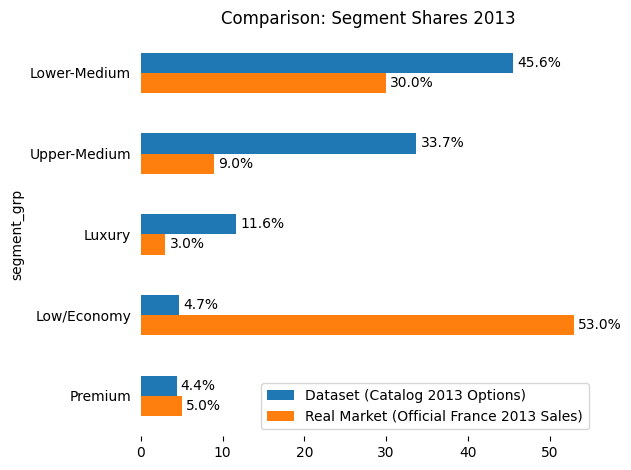

I’d be cautious about the Realmarket figures; we’d definitely need to provide a reference there, P


In [7]:
# Qualitative var and recode: segments

print("reduce list of segments and leave only most relevant dimensions")
hierarchical_group_map = {
    'ECONOMIQUE': 'Low/Economy',
    'INFERIEURE': 'Low/Economy',
    'MOY-INFER': 'Lower-Medium',
    'MOY-INF': 'Lower-Medium',  # Handle typo
    'MOY-SUPER': 'Upper-Medium',
    'SUPERIEURE': 'Premium',
    'LUXE': 'Luxury'
}

# Apply mappings to generate features
df['segment_grp'] = df['segment'].map(hierarchical_group_map)

# Print unique mappings including the raw counts
print("Recode segment (with counts) into segment_grp:\n", 
      df[['segment', 'segment_grp']].value_counts().reset_index().to_markdown(index=False))

# VISUALISE database vs estimates of market shares
# 1. Pull dataset from segment_grp
shares = df['segment_grp'].value_counts(normalize=True) * 100

# 2. Reference dict with estimates (France 2013) mapped to index order
real_market_2013 = {
    'Low/Economy': 53.0,
    'Lower-Medium': 30.0,
    'Upper-Medium': 9.0,
    'Premium': 5.0,
    'Luxury': 3.0,}
real_shares = [real_market_2013[cat] for cat in shares.index]

# 3. Build DataFrame with detailed label descriptions
df_plot = pd.DataFrame({
        'Dataset (Catalog 2013 Options)': shares.values,
        'Real Market (Official France 2013 Sales)': real_shares,},
    index=shares.index,)

# 4. plotting
ax = df_plot.plot(
    kind='barh',
    title='Comparison: Segment Shares 2013',)

# Render values next to bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

# cleanup and layout
ax.tick_params(left=False)  # Removes tick marks
ax.invert_yaxis()  # Keeps largest share group at the top
plt.box(False)  # Replaces the entire spine-loop in a single command
plt.tight_layout()
plt.show()

print("I’d be cautious about the Realmarket figures; we’d definitely need to provide a reference there, P")

Task: reduce list of body/car types and leave only most relevant dimensions
Recode body_type (with counts) into body_type_display_name and then body_type_grp:
 | body_type           | body_type_display_name   | body_type_grp     |   count |
|:--------------------|:-------------------------|:------------------|--------:|
| MINIBUS             | Minibus                  | Minibus           |   32744 |
| BERLINE             | Sedan / Hatchback        | Sedan / Hatchback |    5002 |
| BREAK               | Station Wagon            | Station Wagon     |    2271 |
| TS TERRAINS/CHEMINS | SUV / Off-road           | SUV / Off-road    |    1265 |
| COUPE               | Coupe                    | Sport / Special   |    1104 |
| COMBISPACE          | Passenger Van            | Van / MPV         |     957 |
| CABRIOLET           | Convertible              | Sport / Special   |     611 |
| MONOSPACE COMPACT   | Minivan / MPV            | Van / MPV         |     610 |
| MINISPACE           | Miniva

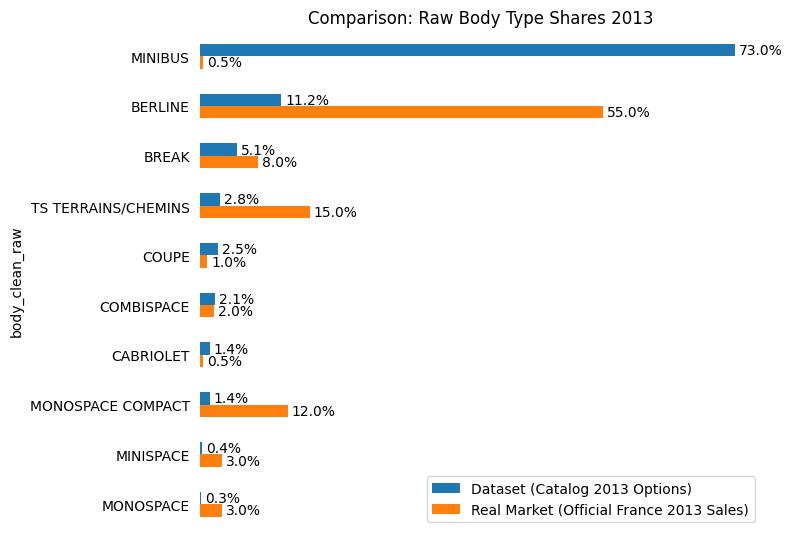

In [8]:
# Qualitative var and recode: body_type
# print(df['body_type'].value_counts()) # check database counts

# Qualitative var and recode: body_type

'''
Meaning of French Body Type Codes:
| French Code:        | English Translation: | Explanation: |
| BERLINE             | Sedan / Hatchback    | Standard passenger car (4 or 5 doors) |
| BREAK               | Station Wagon        | Extended rear cargo area |
| MONOSPACE           | Minivan / MPV        | Multi-Purpose Vehicle, high roof |
| MONOSPACE COMPACT   | Minivan / MPV        | Compact Multi-Purpose Vehicle |
| MINISPACE           | Minivan / MPV        | Small Multi-Purpose Vehicle |
| TS TERRAINS/CHEMINS | SUV / Off-road       | All-terrain / SUV vehicle |
| COUPE               | Coupe                | Two-door hardtop car, sporty |
| CABRIOLET           | Convertible          | Open-top passenger car |
| COMBISPACE          | Passenger Van        | Small utility van passenger version |
| MINIBUS             | Minibus              | Large passenger van (>7 seats) |
'''

# Clean and map directly to English display names
body_raw_map = {
    'BERLINE': 'Sedan / Hatchback',
    'BREAK': 'Station Wagon',
    'MONOSPACE': 'Minivan / MPV',
    'MONOSPACE COMPACT': 'Minivan / MPV',
    'MINISPACE': 'Minivan / MPV',
    'TS TERRAINS/CHEMINS': 'SUV / Off-road',
    'COMBISPACE': 'Passenger Van',
    'COUPE': 'Coupe',
    'CABRIOLET': 'Convertible',
    'MINIBUS': 'Minibus'
}
df['body_clean_raw'] = df['body_type'].astype(str).str.upper().str.strip()
df['body_type_display_name'] = df['body_clean_raw'].map(body_raw_map).fillna('Other')

# BODY_TYPE: reduce list and leave only most relevant dimensions.
body_group_map = {
    'Coupe': 'Sport / Special',
    'Convertible': 'Sport / Special',
    'Minivan / MPV': 'Van / MPV',
    'Passenger Van': 'Van / MPV',
}
df['body_type_grp'] = df['body_type_display_name'].map(body_group_map).fillna(df['body_type_display_name'])

# Print unique body_type mappings including raw codes, display names, final groups, and counts
print("Task: reduce list of body/car types and leave only most relevant dimensions")
print("Recode body_type (with counts) into body_type_display_name and then body_type_grp:\n", 
      df[['body_type', 'body_type_display_name', 'body_type_grp']].value_counts().reset_index().to_markdown(index=False))




# VISUALISATION of database results vs estimate of real market shares
df['body_clean_raw'] = df['body_type'].astype(str).str.upper().str.strip()

# 1. Pull dynamic dataset shares from the 10 raw categories
shares = df['body_clean_raw'].value_counts(normalize=True) * 100

# 2. Reference dict mapped directly to the 10 original French keys (France 2013 Sales)
real_market_2013 = {
    'BERLINE': 55.0,
    'MONOSPACE COMPACT': 12.0,
    'TS TERRAINS/CHEMINS': 15.0,
    'BREAK': 8.0,
    'MINISPACE': 3.0,
    'MONOSPACE': 3.0,
    'COMBISPACE': 2.0,
    'COUPE': 1.0,
    'MINIBUS': 0.5,
    'CABRIOLET': 0.5
}
real_shares = [real_market_2013.get(cat, 0.0) for cat in shares.index]

# 3. Build DataFrame for the 10 categories
df_plot = pd.DataFrame({
    'Dataset (Catalog 2013 Options)': shares.values,
    'Real Market (Official France 2013 Sales)': real_shares
}, index=shares.index)

# 4. Plotting pipeline
ax = df_plot.plot(
    kind='barh',
    title='Comparison: Raw Body Type Shares 2013',
    figsize=(8, 5.5)  # Expanded height for 10 distinct rows
)

# Render values next to bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

# Cleanup layout
ax.xaxis.set_visible(False)
ax.tick_params(left=False)
ax.invert_yaxis()  # Keeps largest dataset share (MINIBUS) at the top
plt.box(False)

plt.tight_layout()
plt.show()

Values counts of brands: brand
MERCEDES-BENZ                38450
VOLKSWAGEN                     900
FIAT                           607
OPEL                           586
BMW                            525
SKODA                          364
FORD                           296
AUDI                           242
CITROEN                        207
MAZDA                          193
LEXUS                          175
MERCEDES AMG                   174
NISSAN                         173
PEUGEOT                        160
RENAULT                        155
TOYOTA                         111
VOLVO                          106
SEAT                           105
ALFA-ROMEO                     103
PORSCHE                         89
MINI                            79
KIA                             78
ASTON MARTIN                    78
JEEP                            74
CHEVROLET                       63
JAGUAR LAND ROVER LIMITED       55
HYUNDAI                         52
SMART                   

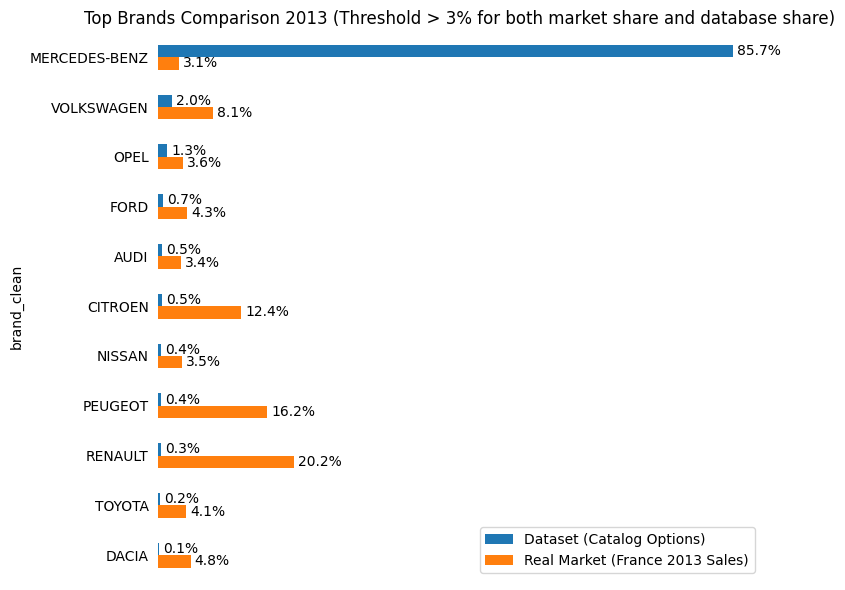

In [9]:
# Qualitative var and recode: brand

print("Values counts of brands:", df['brand'].value_counts())

# Ensure clean uppercase strings from the original variable
df['brand_clean'] = df['brand'].astype(str).str.upper().str.strip()

# 1. Pull dynamic dataset shares from raw data
shares = df['brand_clean'].value_counts(normalize=True) * 100

# 2. Reference dict for French car market registrations 2013 if >3% ESTIMATED share
real_market_2013 = {
    'RENAULT': 20.2,
    'PEUGEOT': 16.2,
    'CITROEN': 12.4,
    'VOLKSWAGEN': 8.1,
    'DACIA': 4.8,
    'FORD': 4.3,
    'TOYOTA': 4.1,
    'OPEL': 3.6,
    'NISSAN': 3.5,
    'AUDI': 3.4,
    'MERCEDES-BENZ': 3.1,
    'BMW': 3.0
}
real_shares = [real_market_2013.get(cat, 0.0) for cat in shares.index]

# 3. Build base DataFrame
df_plot = pd.DataFrame({
    'Dataset (Catalog Options)': shares.values,
    'Real Market (France 2013 Sales)': real_shares
}, index=shares.index)

# 4. CRITICAL FILTER: Keep only brands where EITHER Dataset > 3% OR Real Market > 3%
df_filtered = df_plot[(df_plot['Dataset (Catalog Options)'] > 3) | 
                       (df_plot['Real Market (France 2013 Sales)'] > 3)].copy()

# 5. Minimalist Plotting Pipeline
ax = df_filtered.plot(
    kind='barh',
    title='Top Brands Comparison 2013 (Threshold > 3% for both market share and database share)',
    figsize=(8, 6)
)

# Render values next to bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

# Cleanup layout
ax.xaxis.set_visible(False)
ax.tick_params(left=False)
ax.invert_yaxis()  # Keeps largest dataset share (MERCEDES-BENZ) at the top
plt.box(False)

plt.tight_layout()
plt.show()

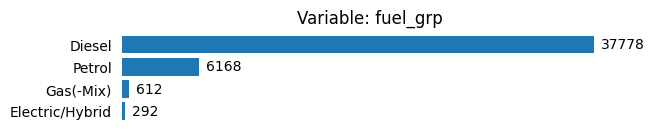

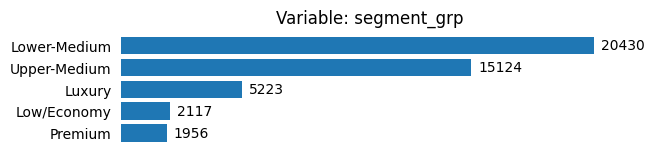

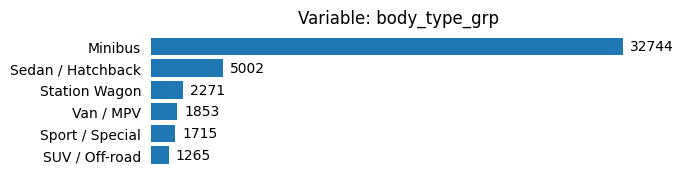

diesel stands out in df_fr because overrepresentation of minibus-type vehicles


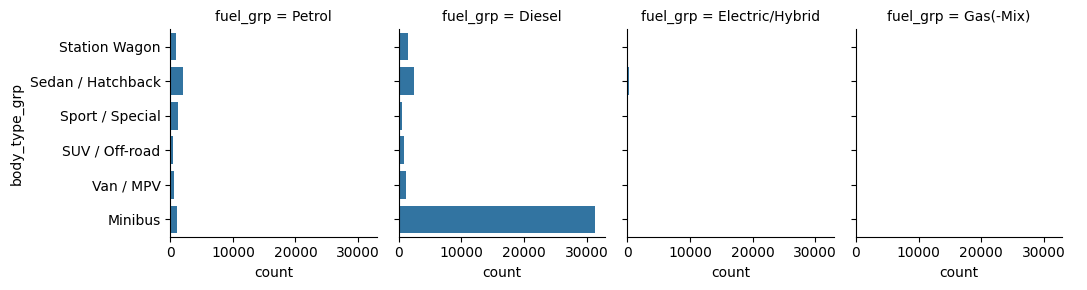

In [10]:
# Qualitative var, grouped: Analyses/Interdependence

# Frequencies of categorical variables
categorical_vars = ['fuel_grp', 'segment_grp', 'body_type_grp']
for var in categorical_vars:
    counts = df[var].value_counts(dropna=False) # Standard val counts 
    dynamic_height = len(counts) * 0.3 # define dynamic height per category row
    fig, ax = plt.subplots(figsize=(6.4, dynamic_height)) # individual heights
    bars = ax.barh(counts.index.astype(str), counts.values)
    ax.bar_label(bars, padding=5) # to display values next to bars
    ax.xaxis.set_visible(False) # no grids
    ax.tick_params(left=False) # Hide tick marks
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False) # no grids    
    ax.invert_yaxis() # Invert axis to ensure largest value is at the top
    plt.title(f"Variable: {var}")
    plt.show()



print("diesel stands out in df_fr because overrepresentation of minibus-type vehicles")
sns.catplot(
    data=df, 
    y="body_type_grp", 
    col="fuel_grp", 
    kind="count",
    height=3.0, 
    aspect=0.9,
)
plt.show()






No normal distribution of our potential target var and other ... - Check again after weighting the data!


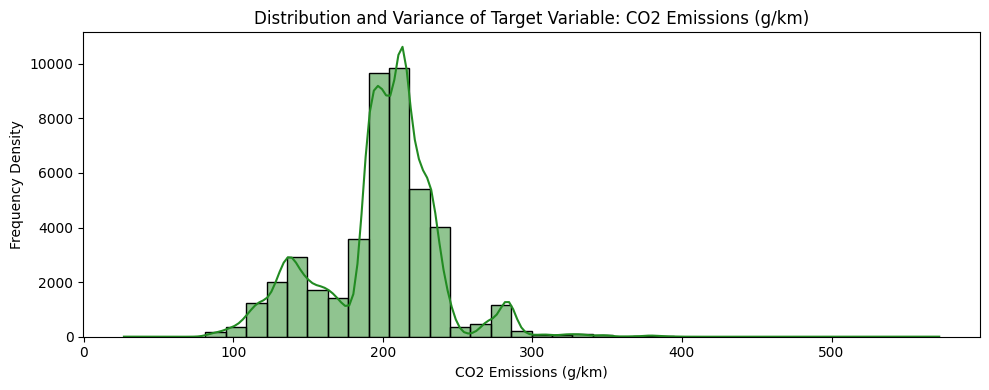

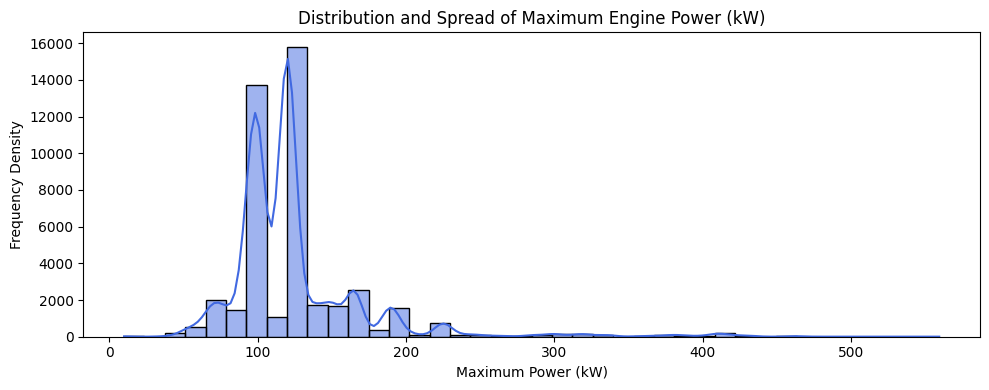

PLEASE ADD YOUR ANALYSIS WITH COMMENTS


In [11]:
# Continuous var: Frequencies

# ---------------------------------------------------------------------------
# CO2 Emissions (g/km) - Target Variable
print("No normal distribution of our potential target var and other ... - Check again after weighting the data!")
plt.figure(figsize=(10, 4))
sns.histplot(
    data=df, 
    x='co2_g_km', 
    bins=40, 
    kde=True, 
    color='forestgreen'
)
plt.title("Distribution and Variance of Target Variable: CO2 Emissions (g/km)", fontsize=12)
plt.xlabel("CO2 Emissions (g/km)")
plt.ylabel("Frequency Density")
plt.tight_layout()

# ---------------------------------------------------------------------------
# Maximum Power (kW)
plt.figure(figsize=(10, 4))
sns.histplot(
    data=df, 
    x='power_max_kw', 
    bins=40, 
    kde=True, 
    color='royalblue'
)
plt.title("Distribution and Spread of Maximum Engine Power (kW)", fontsize=12)
plt.xlabel("Maximum Power (kW)")
plt.ylabel("Frequency Density")
plt.tight_layout()
plt.show()

print("PLEASE ADD YOUR ANALYSIS WITH COMMENTS")

In [12]:
# Understanding power_max_kw
print("we saw high variation e.g. in boxplot: why?")
# Select key columns for transparent display
display_cols = ['brand', 'commercial_name', 'fuel', 'power_max_kw', 'co2_g_km']

# Extracting the 5 most powerful vehicles
top_5_powerful = df.nlargest(5, 'power_max_kw')[display_cols]

# Extracting the 5 least powerful vehicles
bottom_5_powerful = df.nsmallest(5, 'power_max_kw')[display_cols]
print()
print("=== TOP 5 HIGHEST POWER_MAX_KW RECORDS ===")
print(top_5_powerful)
print("luxury cars with outstanding power")

print()
print("\n=== TOP 5 LOWEST POWER_MAX_KW RECORDS ===")
print(bottom_5_powerful)
print("electric cars with such low power???")

we saw high variation e.g. in boxplot: why?

=== TOP 5 HIGHEST POWER_MAX_KW RECORDS ===
             brand commercial_name fuel  power_max_kw  co2_g_km
115   ASTON MARTIN          ONE-77   ES         559.3     555.0
116   ASTON MARTIN          ONE-77   ES         559.3     572.0
117   ASTON MARTIN          ONE-77   ES         559.3     555.0
118   ASTON MARTIN          ONE-77   ES         559.3     572.0
1382       FERRARI   F12Berlinetta   ES         541.0     350.0
luxury cars with outstanding power


=== TOP 5 LOWEST POWER_MAX_KW RECORDS ===
      brand commercial_name fuel  power_max_kw  co2_g_km
41804   MIA   mia 3PL 8 kWh   EL          10.0       NaN
41805   MIA   mia 3PL 8 kWh   EL          10.0       NaN
41806   MIA   mia 3PL 8 kWh   EL          10.0       NaN
41807   MIA   mia 3PL 8 kWh   EL          10.0       NaN
41808   MIA  mia 3PL 12 kWh   EL          10.0       NaN
electric cars with such low power???


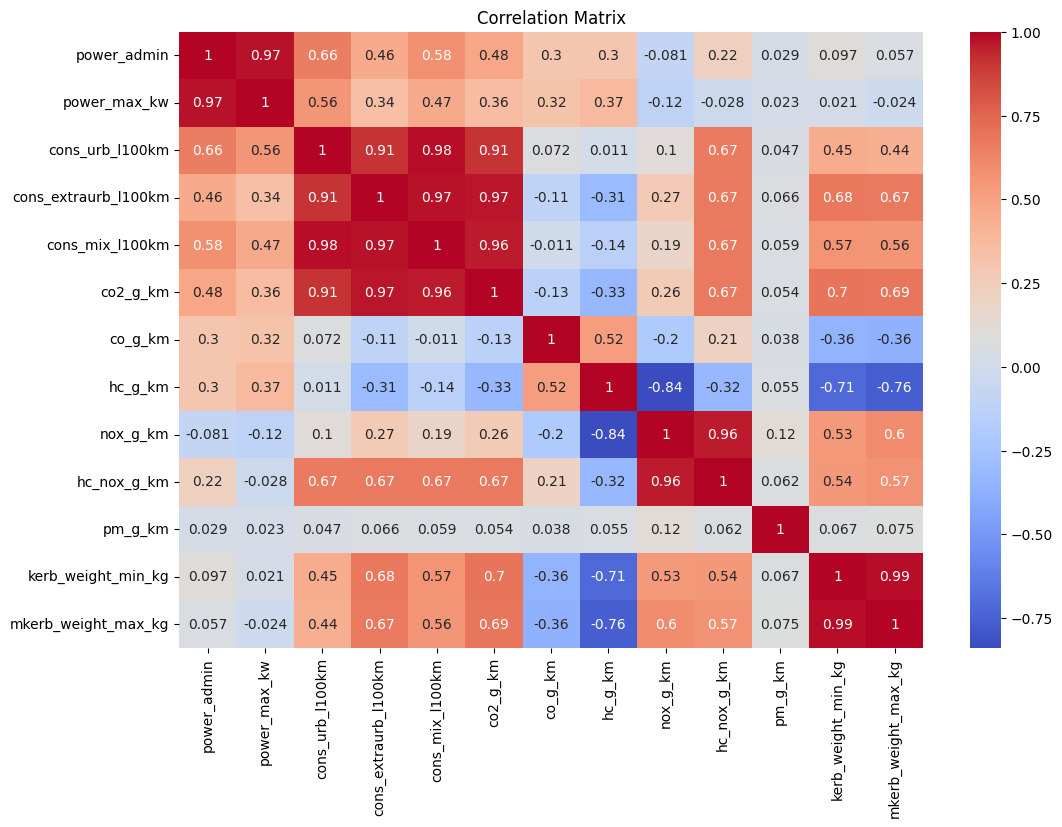


CORRELATION MATRIX ANALYSIS

The heatmap shows several groups of variables that are strongly related to each other. First, power_admin and power_max_kw have a correlation of 0.97, which is extremely high. This makes sense because both variables essentially measure the same thing - engine power - just recorded in slightly different ways, so they naturally move almost perfectly together.

Second, the fuel consumption variables (cons_urb_l100km, cons_extraurb_l100km, cons_mix_l100km) and co2_g_km are all very strongly correlated with each other, with values between 0.91 and 0.98. This is expected because CO2 emissions are directly caused by fuel consumption - the more fuel an engine burns, the more CO2 it produces. Similarly, the three consumption variables just measure fuel usage under different driving conditions (city, highway, mixed), so it is logical that they are almost identical in behavior.

Third, kerb_weight_min_kg and mkerb_weight_max_kg correlate at 0.99, which again is expec

In [13]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

print("""
CORRELATION MATRIX ANALYSIS

The heatmap shows several groups of variables that are strongly related to each other. First, power_admin and power_max_kw have a correlation of 0.97, which is extremely high. This makes sense because both variables essentially measure the same thing - engine power - just recorded in slightly different ways, so they naturally move almost perfectly together.

Second, the fuel consumption variables (cons_urb_l100km, cons_extraurb_l100km, cons_mix_l100km) and co2_g_km are all very strongly correlated with each other, with values between 0.91 and 0.98. This is expected because CO2 emissions are directly caused by fuel consumption - the more fuel an engine burns, the more CO2 it produces. Similarly, the three consumption variables just measure fuel usage under different driving conditions (city, highway, mixed), so it is logical that they are almost identical in behavior.

Third, kerb_weight_min_kg and mkerb_weight_max_kg correlate at 0.99, which again is expected since these are simply the minimum and maximum bounds of the same vehicle weight measurement.

An interesting negative correlation appears between hc_g_km and nox_g_km, at -0.84. This reflects a known trade-off in engine design: conditions that reduce hydrocarbon (HC) emissions, such as higher combustion temperatures, tend to increase nitrogen oxide (NOx) formation, and vice versa. So when one of these emissions goes down, the other tends to go up.

Power and weight show only moderate correlations with fuel consumption and CO2 (roughly between 0.3 and 0.7). This makes sense intuitively - heavier and more powerful cars tend to consume more fuel and emit more CO2 - but the relationship is not as strong as between the consumption variables themselves, since fuel efficiency also depends on other factors like engine technology.

Finally, pm_g_km (particulate matter emissions) shows almost no correlation with any other variable, mostly below 0.1. This suggests that particulate emissions are determined by different factors than the ones captured in this dataset, such as the presence of a particulate filter, rather than by engine power, weight, or fuel consumption.

Overall, the heatmap reveals that many variables are redundant with each other, especially within the power group, the consumption/CO2 group, and the weight group. This is important to know before building any predictive model, because including several highly correlated variables at the same time can distort the results (a problem known as multicollinearity). It would make sense to keep only one representative variable from each group going forward.
""")

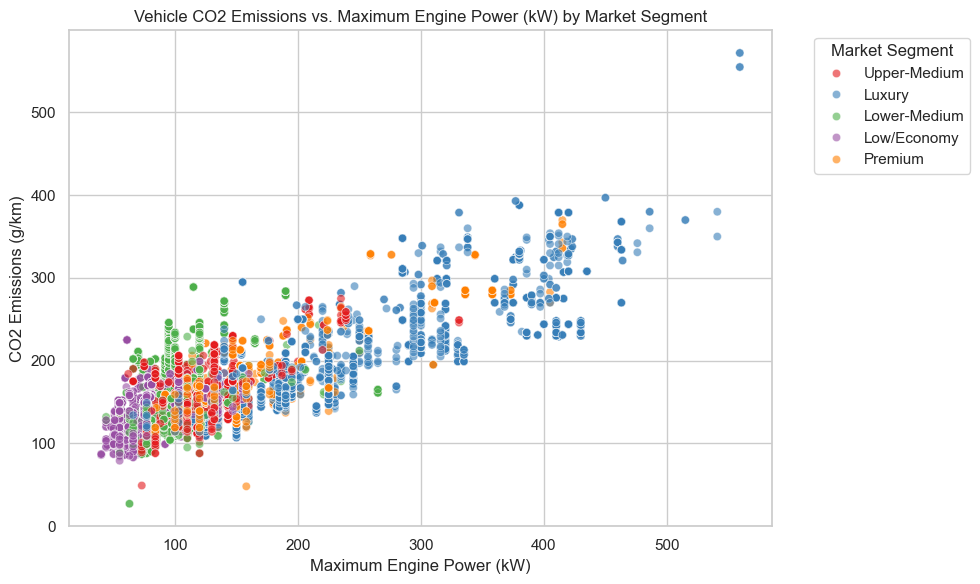

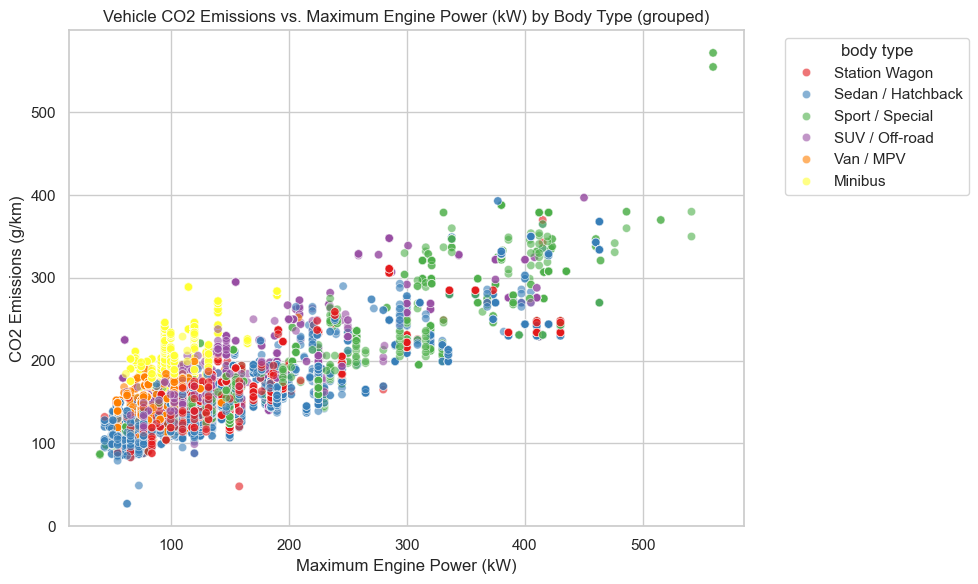

thinking applying another kind of recode to reduce co2 variance within the new groups (e.g. E86 to gas...)


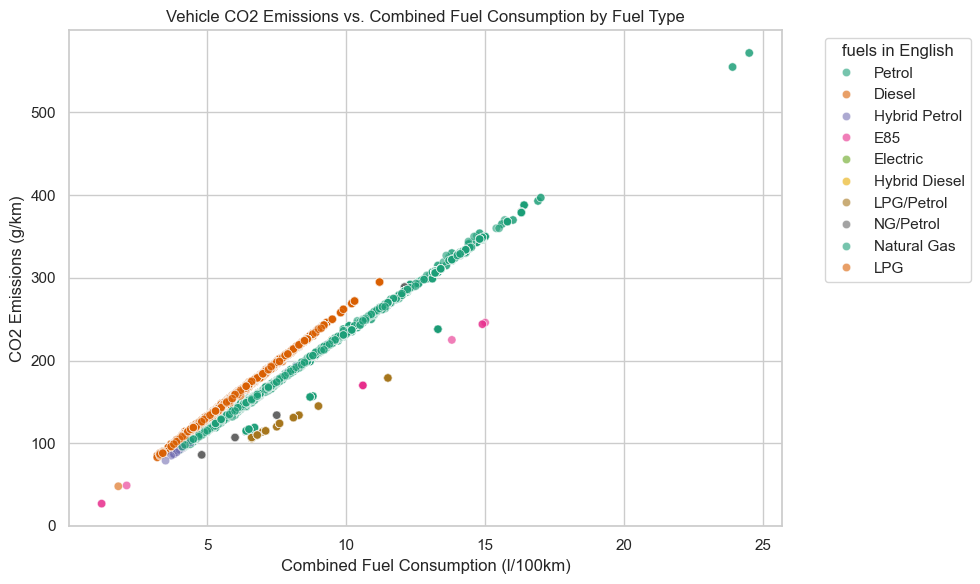

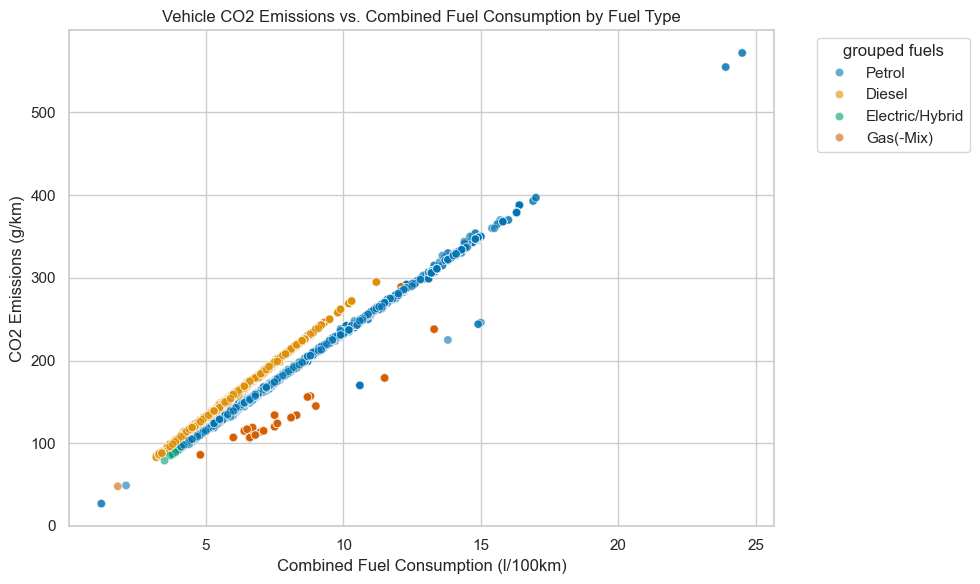

In [14]:
# check, if recoding of qualitative variables makes sense

# Ensure clean plotting styles
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------------------------
# Engine Performance Analysis (Continuous vs. Continuous by grouped Segment)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='power_max_kw', 
    y='co2_g_km', 
    hue='segment_grp', 
    palette='Set1', 
    alpha=0.6,
    edgecolor='w'
)
plt.title("Vehicle CO2 Emissions vs. Maximum Engine Power (kW) by Market Segment")
plt.xlabel("Maximum Engine Power (kW)")
plt.ylabel("CO2 Emissions (g/km)")
plt.legend(title="Market Segment", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Engine Performance Analysis (Continuous vs. Continuous by grouped Body Type)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='power_max_kw', 
    y='co2_g_km', 
    hue='body_type_grp', 
    palette='Set1', 
    alpha=0.6,
    edgecolor='w'
)
plt.title("Vehicle CO2 Emissions vs. Maximum Engine Power (kW) by Body Type (grouped)")
plt.xlabel("Maximum Engine Power (kW)")
plt.ylabel("CO2 Emissions (g/km)")
plt.legend(title="body type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



# ---------------------------------------------------------------------------
# Continuous vs. Continuous by Fuel
print("thinking applying another kind of recode to reduce co2 variance within the new groups (e.g. E86 to gas...)")
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='cons_mix_l100km', 
    y='co2_g_km', 
    hue='fuel_display_name', 
    palette='Dark2', 
    alpha=0.6,
    edgecolor='w'
)
plt.title("Vehicle CO2 Emissions vs. Combined Fuel Consumption by Fuel Type")
plt.xlabel("Combined Fuel Consumption (l/100km)")
plt.ylabel("CO2 Emissions (g/km)")
plt.legend(title="fuels in English", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# Continuous vs. Continuous by grouped Fuel
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='cons_mix_l100km', 
    y='co2_g_km', 
    hue='fuel_grp', 
    palette='colorblind', 
    alpha=0.6,
    edgecolor='w'
)
plt.title("Vehicle CO2 Emissions vs. Combined Fuel Consumption by Fuel Type")
plt.xlabel("Combined Fuel Consumption (l/100km)")
plt.ylabel("CO2 Emissions (g/km)")
plt.legend(title="grouped fuels", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 1d. Finding the business question

Please put some interesting analysis into this section and comment it: we can use this to discuss and find our business question

first question: shall we keep the following groupings?

summary of following 3 diagramms: luxury and petrol car types particularly prone to high co2 emissions


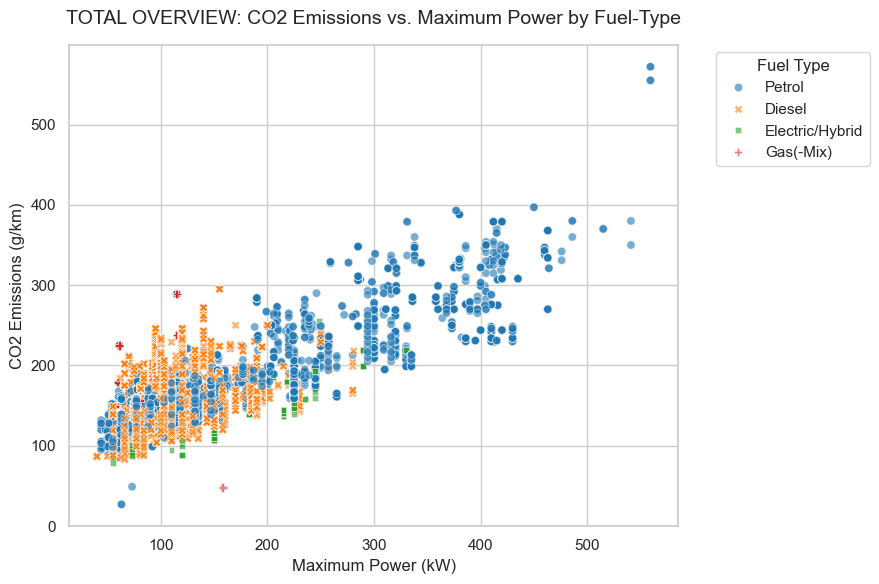

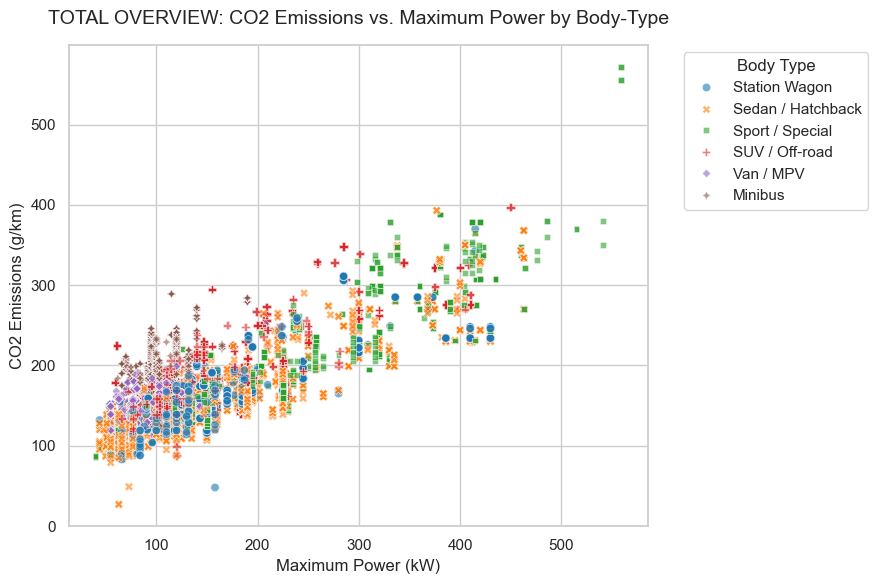

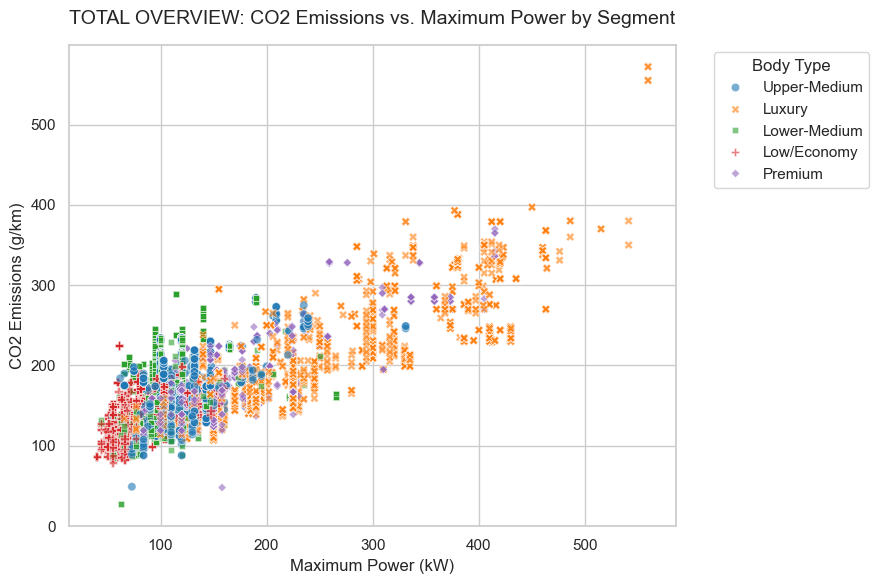

excess co2 emission can be punished by targeting sport/hatchback/SUV cars of the premium/luxury category


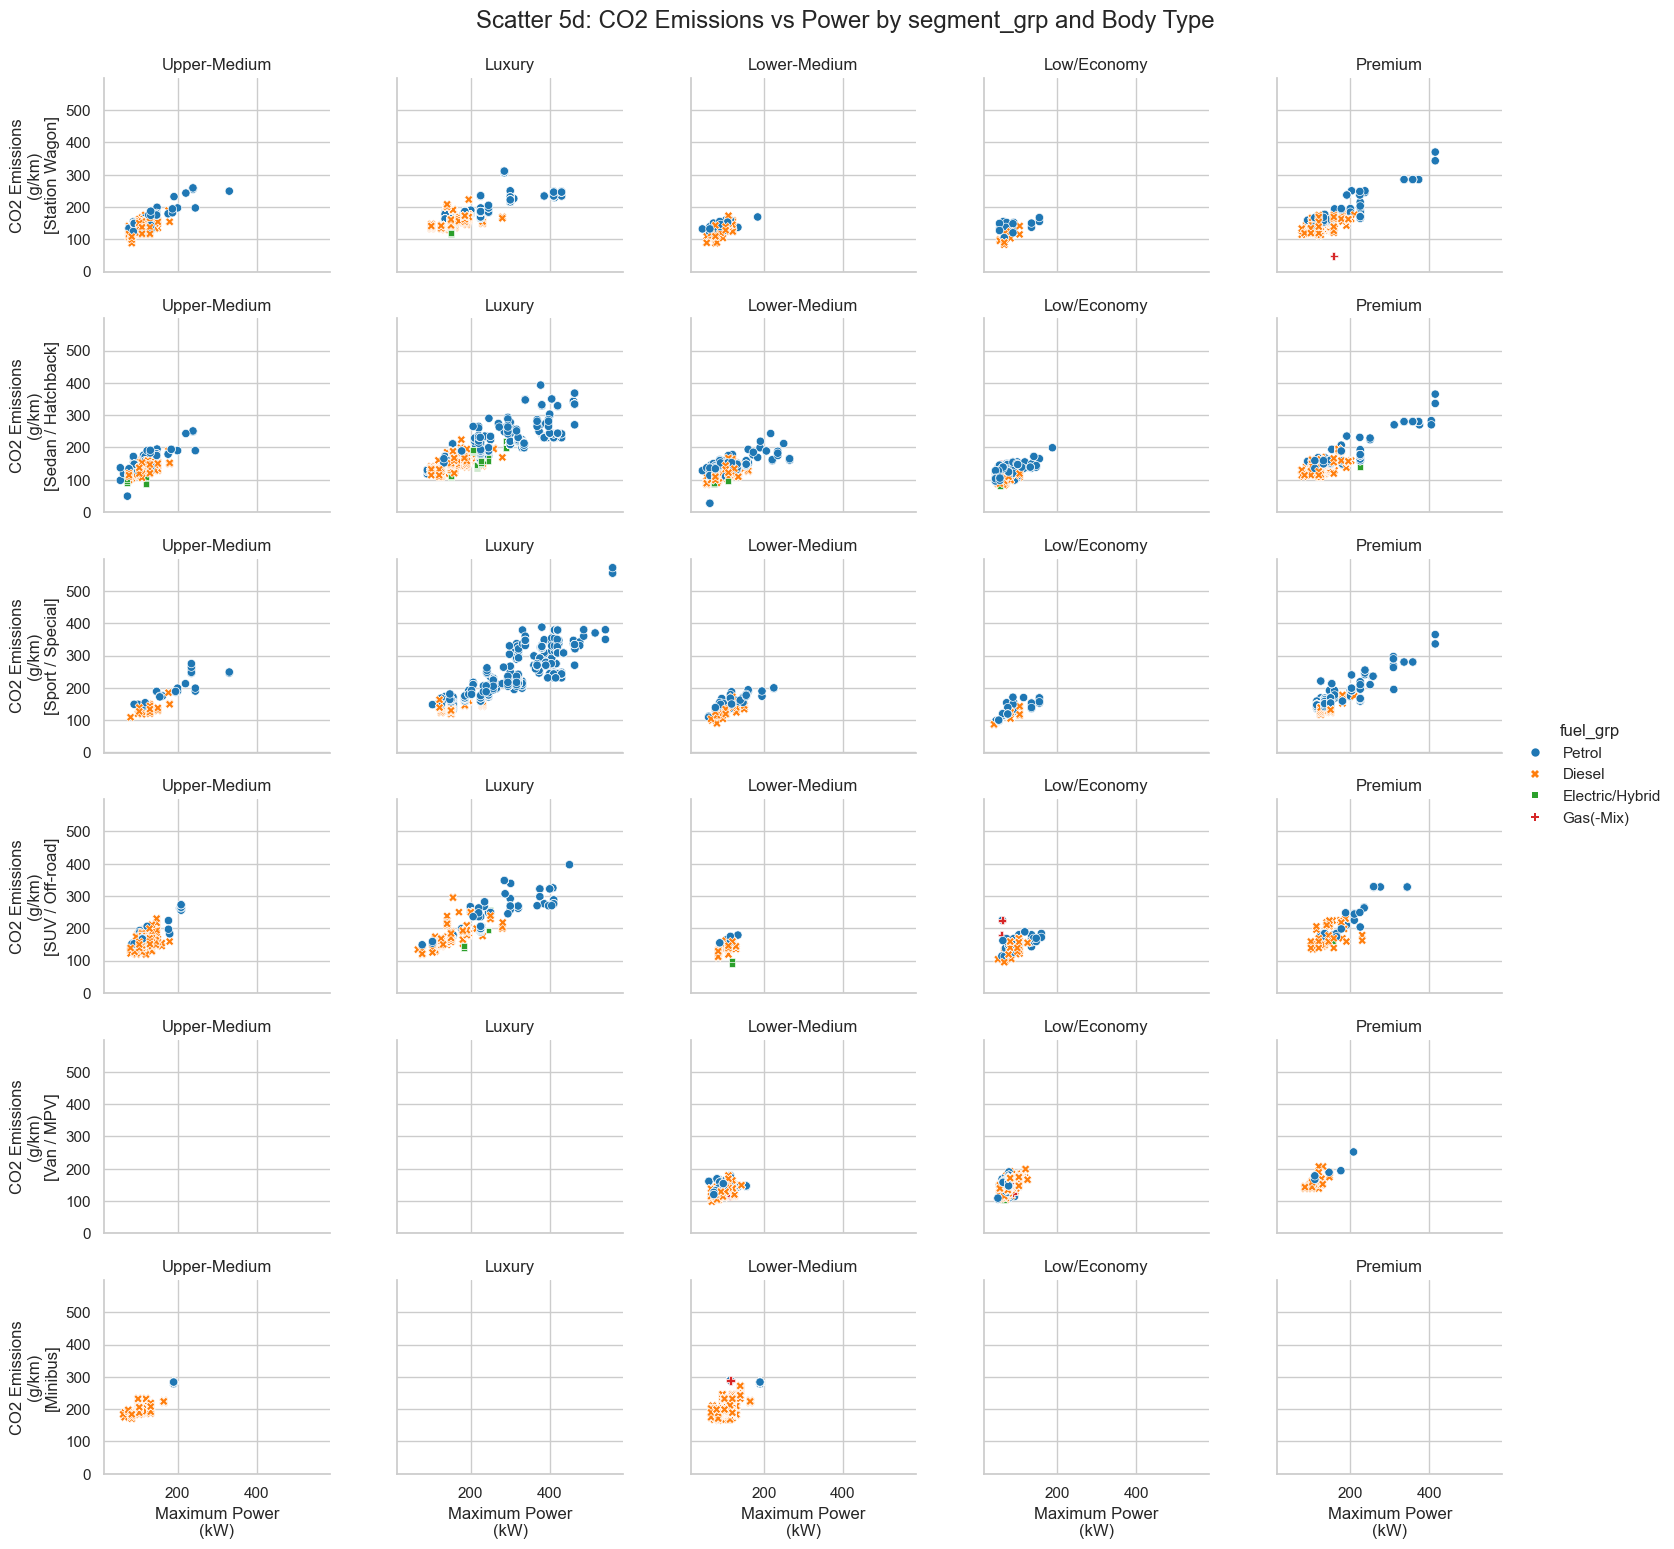

In [15]:
# co2 emissions vs power by fuel/ body-type/ segment
# Continuous var vs qual var: Overview

print("first question: shall we keep the following groupings?\n")
print("summary of following 3 diagramms: luxury and petrol car types particularly prone to high co2 emissions")

# Generate global overview plot co2 vs power by fuel-type
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="power_max_kw",
    y="co2_g_km",
    hue="fuel_grp",
    style="fuel_grp",
    palette="tab10",
    alpha=0.6,
    edgecolor="w"
)
plt.title("TOTAL OVERVIEW: CO2 Emissions vs. Maximum Power by Fuel-Type", 
fontsize=14, pad=15)
plt.xlabel("Maximum Power (kW)")
plt.ylabel("CO2 Emissions (g/km)")
plt.legend(title="Fuel Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#--------------------------------------------------------
# Generate global overview plot co2 vs power by body-type
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="power_max_kw",
    y="co2_g_km",
    hue="body_type_grp",
    style="body_type_grp",
    palette="tab10",
    alpha=0.6,
    edgecolor="w"
)
plt.title("TOTAL OVERVIEW: CO2 Emissions vs. Maximum Power by Body-Type", 
fontsize=14, pad=15)
plt.xlabel("Maximum Power (kW)")
plt.ylabel("CO2 Emissions (g/km)")
plt.legend(title="Body Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#--------------------------------------------------------
# Generate global overview plot co2 vs power by segment
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="power_max_kw",
    y="co2_g_km",
    hue="segment_grp",
    style="segment_grp",
    palette="tab10",
    alpha=0.6,
    edgecolor="w"
)
plt.title("TOTAL OVERVIEW: CO2 Emissions vs. Maximum Power by Segment", 
fontsize=14, pad=15)
plt.xlabel("Maximum Power (kW)")
plt.ylabel("CO2 Emissions (g/km)")
plt.legend(title="Body Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#--------------------------------------------------------
# all previous variables in one overview
print("excess co2 emission can be punished by targeting sport/hatchback/SUV cars of the premium/luxury category")
g = sns.relplot(
    data=df,
    x="power_max_kw",
    y="co2_g_km",
    hue="fuel_grp",
    style="fuel_grp",
    col="segment_grp",
    row="body_type_grp",
    height=2.5,  # Compact height matching your template
    aspect=1.2,
    palette="tab10",
)

# 1. Clean column titles to prevent horizontal overlaps
g.set_titles(template="{col_name}")

# 2. Apply wrapped X-axis label globally (Y-label is set to empty here)
g.set_axis_labels("Maximum Power\n(kW)", "")

# 3. Dynamically add the sub-category (row name) to the Y-axis label of each row
for i, row_val in enumerate(g.row_names):
    ax = g.axes[i, 0]
    ax.set_ylabel(f"CO2 Emissions\n(g/km)\n[{row_val}]")

# 4. Adjust spacing to prevent overlapping axes
g.fig.subplots_adjust(wspace=0.3)

# Apply global title and formatting properties across the FacetGrid
plt.suptitle(
    "Scatter 5d: CO2 Emissions vs Power by segment_grp and Body Type",
    y=1.02,
    fontsize="x-large",
)

# 5. Display the plot
plt.show()

euro class standardisation has in part wide variation in terms of co2 emissions.
 Consider fokussing with taxation on specific EU classes? 
 We need to find out what these EU-classes mean?


/var/folders/66/c1cyljk97vx1gf0jw9q78jj40000gn/T/ipykernel_39743/425265886.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='champ_v9', y='co2_g_km', palette='Set2')


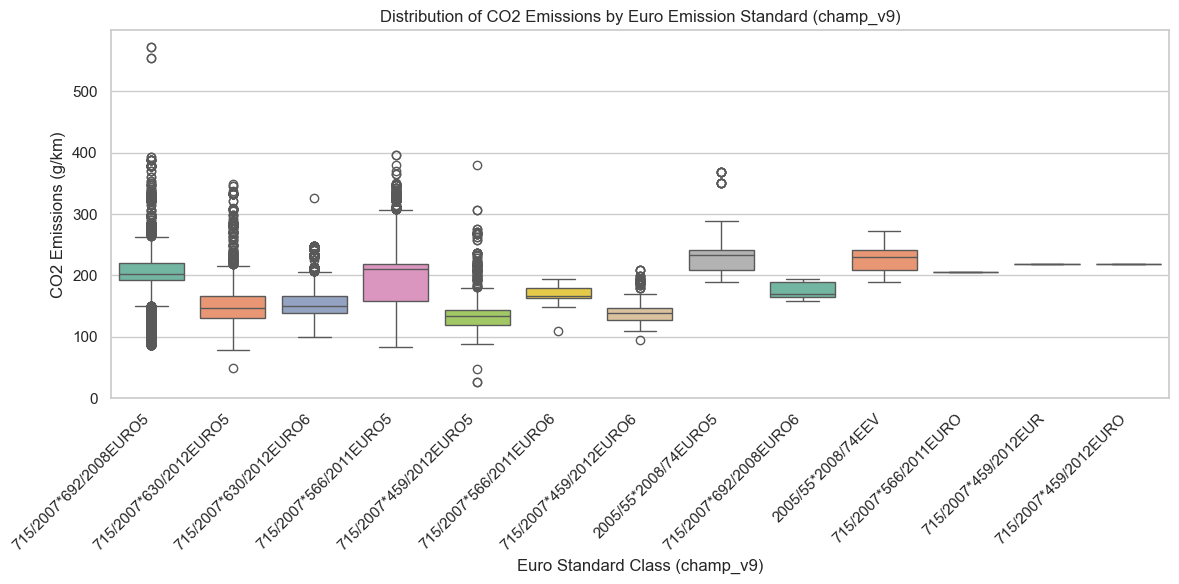

French admin classes have wide variation in terms of co2 emissions.
 Consider fokussing with taxation on reducing variation within these classes?


/var/folders/66/c1cyljk97vx1gf0jw9q78jj40000gn/T/ipykernel_39743/425265886.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='power_admin', y='co2_g_km', palette='viridis')


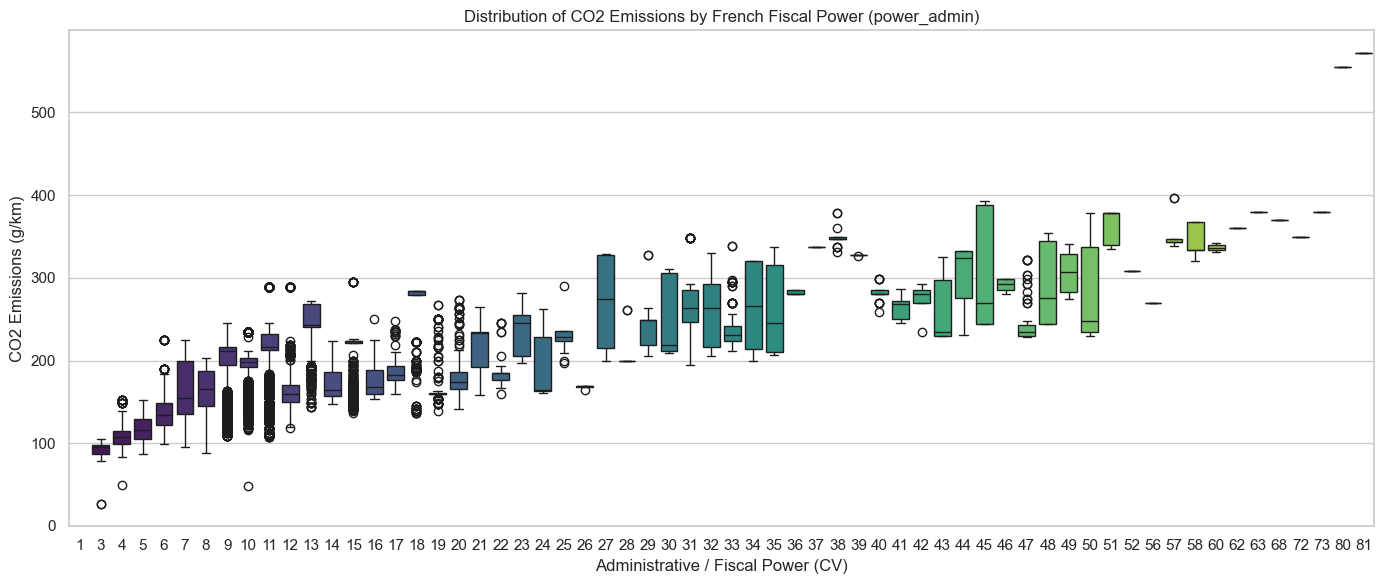

In [16]:
# co2 emissions vs taxation regime
# Continuous var vs other qual var

# Set global plotting style
sns.set_theme(style="whitegrid")

# Plot 1: Boxplot for categorical environmental standard (champ_v9)
print("euro class standardisation has in part wide variation in terms of co2 emissions.\n Consider fokussing with taxation on specific EU classes? \n We need to find out what these EU-classes mean?")
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='champ_v9', y='co2_g_km', palette='Set2')
plt.title("Distribution of CO2 Emissions by Euro Emission Standard (champ_v9)")
plt.xlabel("Euro Standard Class (champ_v9)")
plt.ylabel("CO2 Emissions (g/km)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot 2: Boxplot for discrete fiscal power brackets (power_admin)
print("French admin classes have wide variation in terms of co2 emissions.\n Consider fokussing with taxation on reducing variation within these classes?")
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='power_admin', y='co2_g_km', palette='viridis')
plt.title("Distribution of CO2 Emissions by French Fiscal Power (power_admin)")
# Limiting x-axis visibility if there are extreme outliers in fiscal power categories
plt.xlabel("Administrative / Fiscal Power (CV)")
plt.ylabel("CO2 Emissions (g/km)")
plt.tight_layout()
plt.show()

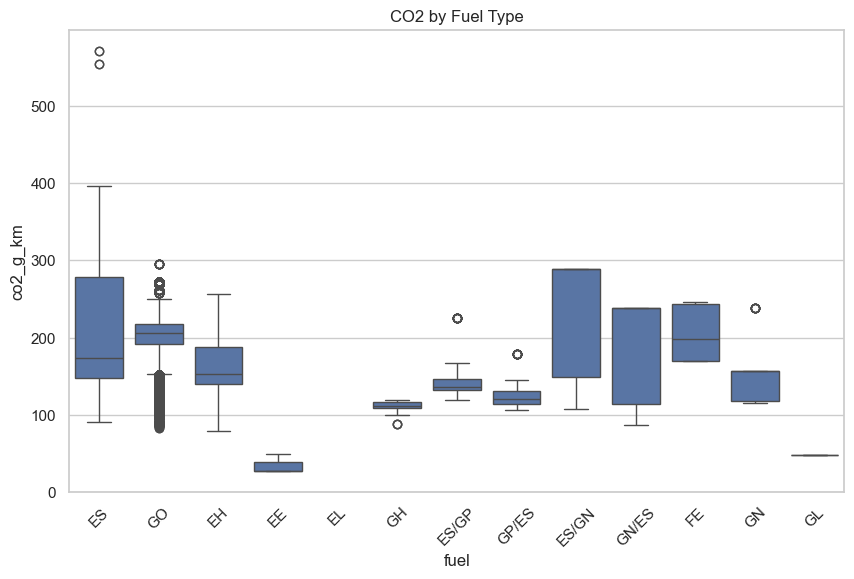

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="fuel",
    y="co2_g_km",
    data=df
)

plt.xticks(rotation=45)
plt.title("CO2 by Fuel Type")
plt.show()

/Users/philipp/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


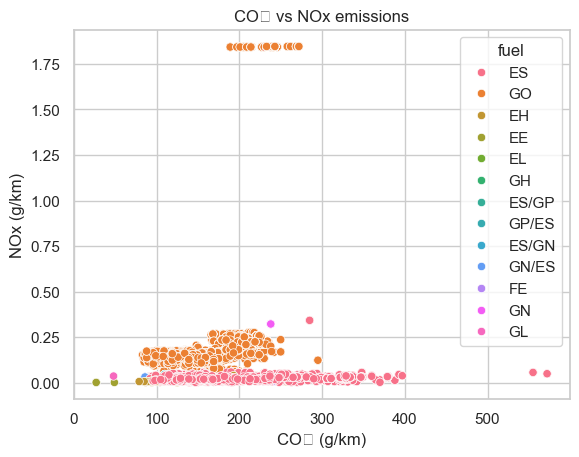

In [18]:
sns.scatterplot(
    data=df,
    x="co2_g_km",
    y="nox_g_km",
    hue="fuel"
)

plt.title("CO₂ vs NOx emissions")
plt.xlabel("CO₂ (g/km)")
plt.ylabel("NOx (g/km)")
plt.show()

French malus threshholds with some effect on trying to get below certain targets:
 shall we look at brands, which successfully try to beat these targets?
 Or suggest further treshhold (PLEASE CHECK IF THESE ARE CORRECT) towards the top? 


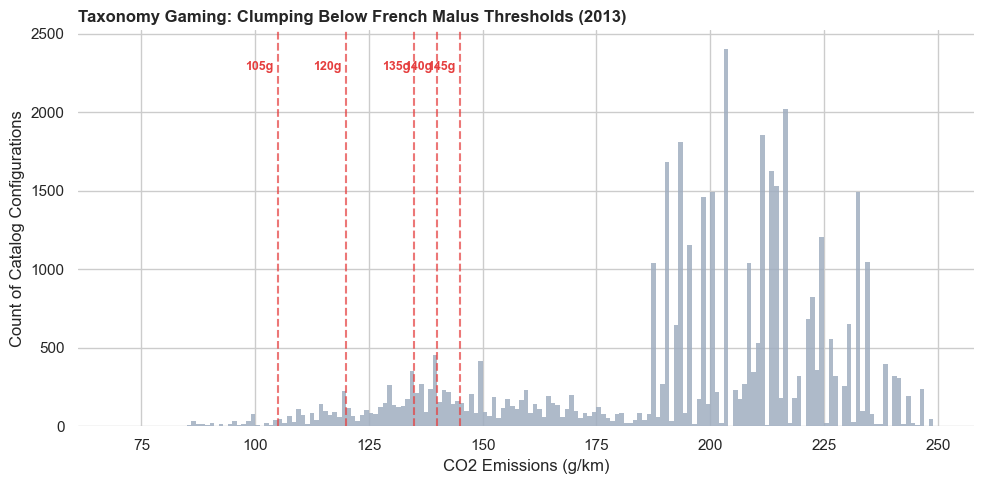

In [19]:
# Effect of French legislative carbon tax thresholds "Malus Écologique"

print("French malus threshholds with some effect on trying to get below certain targets:\n shall we look at brands, which successfully try to beat these targets?\n Or suggest further treshhold (PLEASE CHECK IF THESE ARE CORRECT) towards the top? ")

# Define the critical French tax thresholds of 2013
thresholds = [105, 120, 135, 140, 145]

# Plot the distribution of CO2 emissions to detect artificial spikes
plt.figure(figsize=(10, 5))
plt.hist(df['co2_g_km'], bins=range(70, 250, 1), color='#a0aec0', edgecolor='none', alpha=0.85)

# Add vertical threshold lines to visually demonstrate the gaming effect
for t in thresholds:
    plt.axvline(x=t, color='#e53e3e', linestyle='--', alpha=0.7, label=f'Threshold: {t}g' if t==105 else "")
    # Add annotation slightly to the left of the line (the "gamed" sweet spot)
    plt.text(t-1, plt.gca().get_ylim()[1]*0.9, f'{t}g', color='#e53e3e', ha='right', fontsize=9, weight='bold')

plt.title("Taxonomy Gaming: Clumping Below French Malus Thresholds (2013)", loc='left', weight='bold')
plt.xlabel("CO2 Emissions (g/km)")
plt.ylabel("Count of Catalog Configurations")
plt.box(False)
plt.tight_layout()
plt.show()

# Step 2 / Pre-processing and Feature Engineering — Deadline: June 30

Based on the findings from the previous step, you will need to clean your dataset and carry out the pre-processing steps.
If needed, you should transform and/or add features and enrich your dataset.

The goal at the end of this step is to have a dataset ready for in-depth analysis and/or Machine (and Deep) Learning modeling.

Deliverable 1: Data exploration, visualization, and pre-processing report.

After Deliverable 1, if not already done, your mentor will create a GitHub repository for your group. It must follow the provided template and be submitted to the jury together with the final report.

---

## merging pipeline - explanation of each step:

### 2a2

* **Requirement:** The DataFrames `df` (France) and `df_eu` (EU) must be loaded in memory.
* **Note:** Recalculating `r_merged` using `transform('count')` to prevent counting vehicle registrations multiple times in 1:N matches.

#### Summary of the Merge Step

In this first step, we perform a **Full Outer Join** between both datasets. After that, for unmatched records (`left_only`), we use a step-by-step substring check to fill in missing type-variant matches.

#### Merge Variables & Conditions

* **Join Type:** `outer` (Full Outer Join to find matches and unmatched rows on both sides)
* **Primary Keys:**
  * **Left (`df`):** `tvv_clean` (Cleaned string from Type-Variant-Version `tvv`)
  * **Right (`df_eu`):** `tvv_composite` (Combination of Type `T` + Variant `Va` + Version `Ve`)
* **Key Cleaning:** Convert to uppercase and remove non-alphanumeric characters (`[^A-Z0-9]`).
* **Secondary Fallback Condition (Substring Match):** Check if the EU combination of `T` (Type) and `Va` (Variant) is inside the French `tvv_clean` string (grouped by the shared brand `brand_both`).
---

### 2a3


#### Evaluation

* **Structure:** The code builds directly on the DataFrames `df` and `df_eu` prepared in step 2a2.
* **Logic & Performance Check:**
  * Cleaning old columns (`cleanup_cols`) ensures a clean starting point.
  * Using IDs (`_id_fr`, `_id_eu`) stops already matched rows from being matched again in later steps (excluding them using `matched_fr_ids` / `matched_eu_ids`).
  * **Important note on merge filtering:** In steps 1–6, rows are pre-filtered using an `inner` join on `['brand_both', 'co2_match']`. Rows with `NaN` in `co2_match` are left out on purpose during these steps (because `NaN == NaN` gives `False` in pandas). This ensures physical values match before checking strings.

#### Summary of the Merge Step

This is a **step-by-step merge pipeline** that excludes matched rows at each stage:
1. At each stage, isolate the remaining unmatched rows.
2. Create a candidate DataFrame and apply a specific match condition.
3. Collect successful matches in `all_matched_subsets` and lock their IDs so they are not used again.
4. After running all stages, combine the matches (`both`) with the remaining unmatched rows (`left_only`, `right_only`) into a final DataFrame `df_joined`.
5. Adjust the registration count (`r_merged`) based on how many times EU IDs match, to avoid counting registrations twice in 1:N matches.


#### Merge Variables & Conditions

##### Pre-Filter (Candidate generation in steps 1–6)

* **Brand:** Exact match on `brand_both` (cleaned in step 2a2).
* **CO2 Emissions:** Exact number match on `co2_match` (`co2_g_km` vs. `e (g/km)` as a `float`).

##### Detailed Pipeline Steps

* **Step 0 (Direct Match):**
  * **Variables:** `tvv_clean` == `tvv_composite` (Exact string match without pre-filtering).

* **Step 1 (a):**
  * **Condition:** `tvv_clean` is inside `tvv_composite`.

* **Step 2 (b):**
  * **Condition:** `tvv_composite` is inside `tvv_clean`.

* **Step 3 (c):**
  * **Condition:** `tvv_no_last_zero_fr` (French TVV without the last `0`) is inside `tvv_composite`.

* **Step 4 (d):**
  * **Condition:** `tvv_no_last_zero_eu` (EU TVV without the last `0`) is inside `tvv_clean`.

* **Step 5 (e):**
  * **Condition:** `tvv_no_trailing_zeros_fr` (French TVV without any ending zeros) is inside `tvv_composite`.

* **Step 6 (f):**
  * **Condition:** `tvv_no_trailing_zeros_eu` (EU TVV without any ending zeros) is inside `tvv_clean`.
---


### 2a4

*Is the code correct and logical for cleaning and combining model names (`Cn` and `model_file`) into `df_joined`?*


#### Evaluation

* **Structure:** The code connects directly to `df_joined` from step 2a3. Duplicate column names are removed at the start.
* **Logic & Performance Check:**
  * `clean_and_remove_brand` removes brand names using word boundaries (`\b`) to avoid deleting parts of short strings.
  * **Performance Note:** Using `apply(..., axis=1)` multiple times for row-by-row checks can be slow on large datasets, but the logic is correct.
  * Step 6 uses `set` lookups to check references quickly in $O(1)$ time.


#### Summary of the Merge Step

In this step, we **clean and combine model names** from both datasets. We create a single column, `model_comp`, to identify matching or differing vehicle models between the EU and French databases.


### Merge Variables & Conditions

#### Input Columns for Model Cleaning

* **EU database:** `Cn` $\rightarrow$ cleaned to `Cn_clean`
* **French database:** `model_file` $\rightarrow$ cleaned to `model_file_clean`
* **Context column:** `brand_both` (used to remove brand names from model strings)

#### Step-by-Step Logic to Fill `model_comp`

1. **Exact match:** `Cn_clean == model_file_clean` (if not `NaN`).
2. **Substring match A:** `Cn_clean` is fully inside `model_file_clean` (replace extra characters with `_`).
3. **Substring match B:** `model_file_clean` is fully inside `Cn_clean` (replace extra characters with `_`).
4. **Fallback:** If no match, combine both strings with a leading underscore (`_model_file_clean _Cn_clean`).
5. **Cleanup:** Remove the leading `_` if the remaining string already exists as a verified model (`_merge == 'both'`) within the same brand (`brand_both`).
---


### 2a6


*Is the match logic for remaining unmatched rows using physical parameters and substring checks in `df_joined` correct?*

#### Evaluation

* **Structure:** The code connects directly to step 2a4. Splitting into `left_only` and `right_only` isolates only the unmatched rows.
* **Logic & Performance Check:**
  * Converting power (`pwr_num`) and weight (`wgt_num`) using `pd.to_numeric(..., errors='coerce')` ensures correct data types for comparison.
  * Removing duplicate columns from the left side before joining prevents extra column suffixes (`_x`, `_y`).
  * Deduplicating 1:1 using `drop_duplicates` on both ID columns prevents creating duplicate rows during the join.

#### Summary of the Merge Step

This step **extends the matching process (Step 7)**. It takes the unmatched rows (`left_only` and `right_only`) and applies a multi-feature match. New matches are added back into `df_joined` as `both`, and registration counts (`r_merged`) are recalculated.


#### Merge Variables & Conditions

##### 1. Candidate Join (Exact Multi-Feature Match)

A pair of unmatched rows is selected as a candidate only if **all** of specific variables match exactly:

* **Brand:** `brand_both`
* **Model:** `model_comp` (cleaned in step 2a4)
* **Engine Power:** `pwr_num` (`power_max_kw` from FR vs. `ep (KW)` from EU)

##### 2. Substring Filter Condition

Candidates are accepted as a match only if:

* **Type/Variant:** `tv_comp` (EU) is a substring inside `tvv_clean` (France).


### 2a7 Fuzzy Matching

Add the following merge process (using Levenshtein distance): 2a7 Fuzzy Matching if r >= 50

For each `brand_both` group and within it for each `model_comp`:
Only if power differs by `<= 2`, registration count `r >= 50`, and only for unmatched rows (`_merge != 'both'`):
Calculate Levenshtein distance to match `tvv_composite` with `tvv_clean` when string similarity is `> 80%`.

Add the count of fuzzy merges for each brand as a new column to a cross-tabulation of `brand_both` vs `_merge`.

Create a table grouped by `brand_both` in rows, with the following columns:
1) `power_max_kw == ep (KW)`
2) difference between `power_max_kw` and `ep (KW)` is `< 10`
3) difference between `power_max_kw` and `ep (KW)` is `>= 10`
Compared for: a) successful matches from fuzzy matching vs. b) previously successful matches (excluding fuzzy matching).

---


## merging in practice: code cells

In [20]:
# 2a1 merge preparations and 1st merge df_eu with df_fr
import os
import re
import numpy as np
import pandas as pd

os.makedirs('kannweg', exist_ok=True)

# ==============================================================================
# 1. BRAND & STRING HARMONIZATION HELPERS

brand_mapping = {
    "MERCEDES BENZ": "MERCEDES-BENZ",
    "MERCEDES AMG": "MERCEDES-BENZ",
    "ALFA ROMEO": "ALFA-ROMEO",
    "ROLLS ROYCE": "ROLLS-ROYCE",
    "JAGUAR CARS LIMITED": "JAGUAR LAND ROVER",
    "JAGUAR": "JAGUAR LAND ROVER",
    "JAGUAR LAND ROVER LIMITED": "JAGUAR LAND ROVER",
    "LAND ROVER": "JAGUAR LAND ROVER",
    "FORD CNG TECHNIK": "FORD",
    "RENAULT TECH": "RENAULT",
    "BMW I": "BMW",
    "ABARTH": "FIAT",
}

def standardize_brand(series: pd.Series) -> pd.Series:
    clean_series = (
        series.fillna('')
        .astype(str)
        .str.replace("-", " ", regex=False)
        .str.strip()
        .str.upper()
    )
    return clean_series.replace(brand_mapping).replace("NAN", np.nan)

def clean_key(series: pd.Series) -> pd.Series:
    return series.fillna('').astype(str).str.upper().str.replace(r'[^A-Z0-9]', '', regex=True)

def sanitize_num_to_int(df_in: pd.DataFrame, col: str) -> pd.Series:
    if col in df_in.columns:
        return pd.to_numeric(df_in[col], errors='coerce').round().astype('Int64')
    return pd.Series(pd.NA, index=df_in.index, dtype='Int64')

# Apply Brand Harmonization
fr_brand_col = 'brand_clean' if 'brand_clean' in df.columns else 'brand'
df['brand_both'] = standardize_brand(df[fr_brand_col])
df_eu['brand_both'] = standardize_brand(df_eu['Mk'])

# Clean Keys
df['tvv_clean'] = clean_key(df['tvv'])
df_eu['tvv_composite'] = clean_key(
    df_eu['T'].fillna('').astype(str) + 
    df_eu['Va'].fillna('').astype(str) + 
    df_eu['Ve'].fillna('').astype(str)
)
df_eu['tv_comp'] = clean_key(
    df_eu['T'].fillna('').astype(str) + 
    df_eu['Va'].fillna('').astype(str)
)

# Standardize Raw Numerics before merge
df['kw_round'] = sanitize_num_to_int(df, 'power_max_kw')
df_eu['kw_round'] = sanitize_num_to_int(df_eu, 'ep (KW)')

df['co2_round'] = sanitize_num_to_int(df, 'co2_g_km')
df_eu['co2_round'] = sanitize_num_to_int(df_eu, 'e (g/km)')

df['kg_round'] = sanitize_num_to_int(df, 'mkerb_weight_max_kg')
df_eu['kg_round'] = sanitize_num_to_int(df_eu, 'm (kg)')

df['fuel_comp'] = clean_key(df.get('fuel', pd.Series('', index=df.index)))
df_eu['fuel_comp'] = clean_key(df_eu.get('ft', pd.Series('', index=df_eu.index)))

# Preserve Original Indices
df['_id_fr'] = df.index
df_eu['_id_eu'] = df_eu.index

# ==============================================================================
# 2. INITIAL OUTER JOIN & COMPOSITE CREATION

df_joined = pd.merge(
    df, 
    df_eu, 
    left_on='tvv_clean', 
    right_on='tvv_composite', 
    how='outer', 
    suffixes=('', '_eu'),
    indicator=True
)

if 'brand_both_eu' in df_joined.columns:
    df_joined['brand_both'] = df_joined['brand_both'].fillna(df_joined['brand_both_eu'])

# Establish Core Composites (_comp) with explicit Int64 and string typing
df_joined['kw_comp'] = df_joined['kw_round'].fillna(df_joined['kw_round_eu']).astype('Int64')
df_joined['co2_comp'] = df_joined['co2_round'].fillna(df_joined['co2_round_eu']).astype('Int64')
df_joined['kg_comp'] = df_joined['kg_round'].fillna(df_joined['kg_round_eu']).astype('Int64')

fuel_fr = df_joined.get('fuel_comp', pd.Series('', index=df_joined.index))
fuel_eu = df_joined.get('fuel_comp_eu', pd.Series('', index=df_joined.index))
df_joined['fuel_comp'] = (
    fuel_fr.replace('', np.nan)
    .fillna(fuel_eu.replace('', np.nan))
    .fillna('')
    .astype('string')
)

df_joined['tvv_comp'] = df_joined['tvv_clean'].replace('', np.nan).fillna(df_joined['tvv_composite']).astype('string')

# ==============================================================================
# 3. ADVANCED IMPUTATION FOR TV_COMP (HIERARCHICAL 90% & FALLBACK RULE)

def impute_tv_comp_lengths(df_in: pd.DataFrame) -> pd.DataFrame:
    df_res = df_in.copy()
    valid_tv = df_res[df_res['tv_comp'].notna() & (df_res['tv_comp'] != '')].copy()
    valid_tv['len_tv'] = valid_tv['tv_comp'].str.len()

    missing_mask = (df_res['tv_comp'].isna() | (df_res['tv_comp'] == '')) & df_res['tvv_clean'].notna()
    
    # Ebene 1: brand_both Ebene (>= 90% identische String-Länge)
    for brand, grp in valid_tv.groupby('brand_both'):
        if len(grp) == 0:
            continue
        lens = grp['len_tv'].value_counts()
        top_len, top_cnt = lens.index[0], lens.iloc[0]
        if (top_cnt / len(grp)) >= 0.90:
            b_mask = missing_mask & (df_res['brand_both'] == brand)
            df_res.loc[b_mask, 'tv_comp'] = df_res.loc[b_mask, 'tvv_clean'].astype(str).str[:int(top_len)]

    # Ebene 2: T-Gruppe Ebene (wenn brand_both < 90%: prüfen ob T >= 90% oder 100% einheitlich)
    still_missing = (df_res['tv_comp'].isna() | (df_res['tv_comp'] == '')) & df_res['tvv_clean'].notna()
    if 'T' in df_res.columns and still_missing.any():
        for t_val, grp in valid_tv.groupby('T'):
            if len(grp) == 0:
                continue
            lens = grp['len_tv'].value_counts()
            top_len, top_cnt = lens.index[0], lens.iloc[0]
            if (top_cnt / len(grp) >= 0.90) or (len(lens) == 1):
                t_mask = still_missing & (df_res['T'] == t_val)
                df_res.loc[t_mask, 'tv_comp'] = df_res.loc[t_mask, 'tvv_clean'].astype(str).str[:int(top_len)]

    # Ebene 3 (Fallback): Wenn nach Ebene 1 & 2 noch Reste fehlen -> Modale Länge der T-Gruppe verwenden
    still_missing_final = (df_res['tv_comp'].isna() | (df_res['tv_comp'] == '')) & df_res['tvv_clean'].notna()
    if 'T' in df_res.columns and still_missing_final.any():
        for t_val, grp in valid_tv.groupby('T'):
            if len(grp) > 0 and still_missing_final[df_res['T'] == t_val].any():
                mode_len = grp['len_tv'].mode()
                if not mode_len.empty:
                    f_mask = still_missing_final & (df_res['T'] == t_val)
                    df_res.loc[f_mask, 'tv_comp'] = df_res.loc[f_mask, 'tvv_clean'].astype(str).str[:int(mode_len.iloc[0])]

    return df_res

df_joined = impute_tv_comp_lengths(df_joined)

# Registration Volume Recalculation
r_col = 'r_eu' if 'r_eu' in df_joined.columns else 'r'
if r_col in df_joined.columns:
    id_counts = df_joined.groupby('_id_eu')['_id_eu'].transform('count').fillna(1)
    df_joined['r_merged'] = df_joined[r_col] / id_counts

# ==============================================================================
# 4. DIAGNOSTIC OUTPUT & COMPOSITE AUDIT

print("=== AUDIT ZELLE 2a1: INITIAL MERGE & COMPOSITE FEATURES ===")
print(f"Gesamtanzahl Datensätze (df_joined) : {len(df_joined):,}")
print("\nVerteilung Merge-Status (_merge):")
print(df_joined['_merge'].value_counts().to_string())

comp_cols = ['kw_comp', 'co2_comp', 'kg_comp', 'fuel_comp', 'tvv_comp', 'tv_comp']
available_comps = [c for c in comp_cols if c in df_joined.columns]

print("\nBefüllung der Composite-Merkmale:")
for c in available_comps:
    non_nulls = df_joined[c].notna().sum()
    pct = (non_nulls / len(df_joined)) * 100
    print(f"  - {c:<12}: {non_nulls:>7,} / {len(df_joined):<7,} ({pct:6.2f}%) [{df_joined[c].dtype}]")

if 'r_merged' in df_joined.columns:
    print(f"\nSumme r_merged (Volumenerhalt)    : {df_joined['r_merged'].sum():,.2f}")

print("\nStichprobe der konsolidierten Composite-Variablen:")
print(df_joined[['brand_both'] + available_comps].head(10).to_string())

/var/folders/66/c1cyljk97vx1gf0jw9q78jj40000gn/T/ipykernel_39743/1314259613.py:104: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(fuel_eu.replace('', np.nan))


=== AUDIT ZELLE 2a1: INITIAL MERGE & COMPOSITE FEATURES ===
Gesamtanzahl Datensätze (df_joined) : 76,118

Verteilung Merge-Status (_merge):
_merge
left_only     39298
both          21060
right_only    15760

Befüllung der Composite-Merkmale:
  - kw_comp     :  76,116 / 76,118  (100.00%) [Int64]
  - co2_comp    :  76,102 / 76,118  ( 99.98%) [Int64]
  - kg_comp     :  76,118 / 76,118  (100.00%) [Int64]
  - fuel_comp   :  76,118 / 76,118  (100.00%) [string]
  - tvv_comp    :  76,118 / 76,118  (100.00%) [string]
  - tv_comp     :  37,733 / 76,118  ( 49.57%) [object]

Summe r_merged (Volumenerhalt)    : 1,827,319.00

Stichprobe der konsolidierten Composite-Variablen:
  brand_both  kw_comp  co2_comp  kg_comp fuel_comp   tvv_comp tv_comp
0      TESLA       40      <NA>     1335        EL     001A01     NaN
1      TESLA       40         0     1335        EL     001A02    001A
2      TESLA       52         0     2074             00260B19   00260
3      TESLA       69         0     2175         

In [21]:
# 2a2 discrepancy analysis, feature harmonization, and substring matching
import numpy as np
import pandas as pd
import re

# ==============================================================================
# 1. PRE-MATCHING PREPARATION & UNMATCHED PARTITIONING

# Remove duplicate column names if any exist
df_joined = df_joined.loc[:, ~df_joined.columns.duplicated()].copy()

# Isolate unmatched records for initial waterfall passes
df_left = df_joined[df_joined['_merge'] == 'left_only'].copy()
df_right = df_joined[df_joined['_merge'] == 'right_only'].copy()

# Ensure required tracking columns exist
if 'match_step' not in df_joined.columns:
    df_joined['match_step'] = pd.Series(dtype="string", index=df_joined.index)

# Track processed record IDs to prevent re-matching
matched_fr_ids = set(df_joined[df_joined['_merge'] == 'both']['_id_fr'].dropna().unique())
matched_eu_ids = set(df_joined[df_joined['_merge'] == 'both']['_id_eu'].dropna().unique())

# Helper columns for zero-padding stripping logic
df_left['tvv_no_last_zero'] = df_left['tvv_clean'].astype(str).str.replace(r'0$', '', regex=True)
df_right['tvv_no_last_zero'] = df_right['tvv_composite'].astype(str).str.replace(r'0$', '', regex=True)

df_left['tvv_no_trailing_zeros'] = df_left['tvv_clean'].astype(str).str.replace(r'0+$', '', regex=True)
df_right['tvv_no_trailing_zeros'] = df_right['tvv_composite'].astype(str).str.replace(r'0+$', '', regex=True)

# ==============================================================================
# 2. SEQUENTIAL WATERFALL PASSES (PASS 0 TO PASS 6)

waterfall_matches = []

# Define core matching keys based on composite variables
match_keys = [c for c in ['brand_both', 'kw_comp', 'co2_comp'] if c in df_left.columns and c in df_right.columns]

if len(df_left) > 0 and len(df_right) > 0 and len(match_keys) >= 2:
    # Candidate generation via physical parameter parity
    candidates = pd.merge(
        df_left.reset_index(drop=True),
        df_right.reset_index(drop=True),
        on=match_keys,
        suffixes=('_l', '_r')
    )
    
    # Resolve primary key columns dynamically to prevent KeyError on suffix collision
    col_fr = '_id_fr_l' if '_id_fr_l' in candidates.columns else ('_id_fr' if '_id_fr' in candidates.columns else None)
    col_eu = '_id_eu_r' if '_id_eu_r' in candidates.columns else ('_id_eu' if '_id_eu' in candidates.columns else None)

    if col_fr and col_eu:
        # Filter out already matched IDs
        candidates = candidates[
            (~candidates[col_fr].isin(matched_fr_ids)) & 
            (~candidates[col_eu].isin(matched_eu_ids))
        ].copy()

        # Helper to safely retrieve suffixed or unsuffixed column values
        def get_val(row, base_col, suffix):
            if base_col + suffix in row.index:
                return row[base_col + suffix]
            elif base_col in row.index:
                return row[base_col]
            return np.nan

        for idx, row in candidates.iterrows():
            fr_id = row[col_fr]
            eu_id = row[col_eu]

            if pd.isna(fr_id) or pd.isna(eu_id) or fr_id in matched_fr_ids or eu_id in matched_eu_ids:
                continue

            str_fr_raw = get_val(row, 'tvv_clean', '_l')
            str_eu_raw = get_val(row, 'tvv_composite', '_r')
            
            str_fr = str(str_fr_raw) if pd.notna(str_fr_raw) else ''
            str_eu = str(str_eu_raw) if pd.notna(str_eu_raw) else ''
            
            str_fr_no_last = str(get_val(row, 'tvv_no_last_zero', '_l')) if pd.notna(get_val(row, 'tvv_no_last_zero', '_l')) else ''
            str_eu_no_last = str(get_val(row, 'tvv_no_last_zero', '_r')) if pd.notna(get_val(row, 'tvv_no_last_zero', '_r')) else ''
            
            str_fr_no_trail = str(get_val(row, 'tvv_no_trailing_zeros', '_l')) if pd.notna(get_val(row, 'tvv_no_trailing_zeros', '_l')) else ''
            str_eu_no_trail = str(get_val(row, 'tvv_no_trailing_zeros', '_r')) if pd.notna(get_val(row, 'tvv_no_trailing_zeros', '_r')) else ''

            step_name = None

            # Pass 0: Direct exact match
            if str_fr == str_eu and str_fr != '':
                step_name = 'Pass 0: Exact Direct Match'
            # Pass 1: French string inside EU string
            elif str_fr and str_fr in str_eu:
                step_name = 'Pass 1: FR Substring in EU'
            # Pass 2: EU string inside French string
            elif str_eu and str_eu in str_fr:
                step_name = 'Pass 2: EU Substring in FR'
            # Pass 3: French (no last zero) inside EU string
            elif str_fr_no_last and str_fr_no_last in str_eu:
                step_name = 'Pass 3: FR (No Last Zero) in EU'
            # Pass 4: EU (no last zero) inside French string
            elif str_eu_no_last and str_eu_no_last in str_fr:
                step_name = 'Pass 4: EU (No Last Zero) in FR'
            # Pass 5: French (no trailing zeros) inside EU string
            elif str_fr_no_trail and str_fr_no_trail in str_eu:
                step_name = 'Pass 5: FR (No Trailing Zeros) in EU'
            # Pass 6: EU (no trailing zeros) inside French string
            elif str_eu_no_trail and str_eu_no_trail in str_fr:
                step_name = 'Pass 6: EU (No Trailing Zeros) in FR'

            if step_name:
                matched_fr_ids.add(fr_id)
                matched_eu_ids.add(eu_id)
                waterfall_matches.append((fr_id, eu_id, step_name))

# ==============================================================================
# 3. RE-INTEGRATION & VOLUME RECALCULATION

if waterfall_matches:
    df_matches = pd.DataFrame(waterfall_matches, columns=['_id_fr', '_id_eu', 'match_step'])
    
    # Drop temporary zero-stripping helpers before reintegration
    helper_cols = ['tvv_no_last_zero', 'tvv_no_trailing_zeros']
    valid_l = df_left[df_left['_id_fr'].isin(df_matches['_id_fr'])].drop(columns=[c for c in helper_cols if c in df_left.columns], errors='ignore').dropna(axis=1, how='all')
    valid_r = df_right[df_right['_id_eu'].isin(df_matches['_id_eu'])].drop(columns=[c for c in helper_cols if c in df_right.columns], errors='ignore').dropna(axis=1, how='all')

    valid_l_clean = valid_l.drop(columns=[c for c in valid_l.columns if c in valid_r.columns and c != '_id_fr'])
    new_waterfall = pd.merge(pd.merge(df_matches, valid_l_clean, on='_id_fr'), valid_r, on='_id_eu')
    new_waterfall['_merge'] = 'both'

    df_joined = pd.concat([
        df_joined[df_joined['_merge'] == 'both'],
        new_waterfall,
        df_joined[(df_joined['_merge'] == 'left_only') & (~df_joined['_id_fr'].isin(df_matches['_id_fr']))],
        df_joined[(df_joined['_merge'] == 'right_only') & (~df_joined['_id_eu'].isin(df_matches['_id_eu']))]
    ], ignore_index=True)

# Recalculate Registration Volume Weight r_merged
r_col = 'r_eu' if 'r_eu' in df_joined.columns else 'r'
if r_col in df_joined.columns and '_id_eu' in df_joined.columns:
    id_counts = df_joined.groupby('_id_eu')['_id_eu'].transform('count').fillna(1)
    df_joined['r_merged'] = df_joined[r_col] / id_counts

# ==============================================================================
# 4. CELL 2 AUDIT & DIAGNOSTICS

print("=== AUDIT CELL 2: MULTI-PASS WATERFALL MATCHES ===")
print(f"Newly matched records in Cell 2 : {len(waterfall_matches):,}")
print(f"Total verified matches ('both')  : {(df_joined['_merge'] == 'both').sum():,}")
if 'r_merged' in df_joined.columns:
    print(f"Consolidated Volume Sum (r_merged): {df_joined['r_merged'].sum():,.2f}")

=== AUDIT CELL 2: MULTI-PASS WATERFALL MATCHES ===
Newly matched records in Cell 2 : 206
Total verified matches ('both')  : 21,266
Consolidated Volume Sum (r_merged): 1,827,319.00


In [22]:
# 2a3 model_comp creation

# 1. MODEL STRING CLEANING & BRAND STRIPPING FUNCTION

def clean_and_remove_brand(text, brand):
    """
    Strips brand and sub-brand terms from model strings using regex word boundaries.
    Prevents truncation of short model codes (e.g., preserves '208' when stripping 'PEUGEOT').
    """
    if pd.isna(text) or str(text).strip().lower() == 'nan': 
        return np.nan
    
    text_clean = re.sub(r'\s+', ' ', re.sub(r'[^A-Z0-9\s]', '', str(text).upper())).strip()
    if not text_clean or pd.isna(brand): 
        return text_clean if text_clean else np.nan

    brand_raw = str(brand).upper().strip()
    split_parts = re.split(r'[\s\-]+', brand_raw)
    brand_clean = re.sub(r'\s+', ' ', re.sub(r'[^A-Z0-9\s]', '', brand_raw)).strip()

    words_to_remove = [brand_clean] if brand_clean else []
    for part in split_parts:
        part_clean = re.sub(r'[^A-Z0-9]', '', part).strip()
        if len(part_clean) >= 3: 
            words_to_remove.append(part_clean)

    for word in sorted(list(set(words_to_remove)), key=len, reverse=True):
        text_clean = re.sub(rf'\b{re.escape(word)}\b', '', text_clean)

    text_clean = re.sub(r'\s+', ' ', text_clean).strip()
    return text_clean if text_clean != "" else np.nan

# Apply brand stripping logic to raw model fields
df_joined['Cn_clean'] = df_joined.apply(
    lambda r: clean_and_remove_brand(r.get('Cn', np.nan), r.get('brand_both', np.nan)), axis=1
)
df_joined['model_file_clean'] = df_joined.apply(
    lambda r: clean_and_remove_brand(r.get('model_file', np.nan), r.get('brand_both', np.nan)), axis=1
)

# ==============================================================================
# 2. HIERARCHICAL MODEL_COMP ASSIGNMENT

# Initialize model_comp with explicit string data type
df_joined['model_comp'] = pd.Series(dtype="string", index=df_joined.index)

# 2.1 Exact Match: Cn_clean == model_file_clean
mask_exact = (df_joined['Cn_clean'] == df_joined['model_file_clean']) & df_joined['Cn_clean'].notna()
df_joined.loc[mask_exact, 'model_comp'] = df_joined.loc[mask_exact, 'Cn_clean']

# 2.2 Substring Match A: Cn_clean contained in model_file_clean
mask_sub_cn = df_joined['model_comp'].isna() & df_joined.apply(
    lambda r: str(r['Cn_clean']) in str(r['model_file_clean']) if pd.notna(r['Cn_clean']) and pd.notna(r['model_file_clean']) else False, 
    axis=1
)
df_joined.loc[mask_sub_cn, 'model_comp'] = df_joined.loc[mask_sub_cn, 'Cn_clean']

# 2.3 Substring Match B: model_file_clean contained in Cn_clean
mask_sub_mod = df_joined['model_comp'].isna() & df_joined.apply(
    lambda r: str(r['model_file_clean']) in str(r['Cn_clean']) if pd.notna(r['model_file_clean']) and pd.notna(r['Cn_clean']) else False, 
    axis=1
)
df_joined.loc[mask_sub_mod, 'model_comp'] = df_joined.loc[mask_sub_mod, 'model_file_clean']

# 2.4 Fallback Assignment: Non-null value from Cn_clean or model_file_clean
mask_rem = df_joined['model_comp'].isna() & (df_joined['model_file_clean'].notna() | df_joined['Cn_clean'].notna())
df_joined.loc[mask_rem, 'model_comp'] = df_joined[mask_rem]['Cn_clean'].fillna(df_joined[mask_rem]['model_file_clean'])

# ==============================================================================
# 3. CELL 3 AUDIT & DIAGNOSTICS

print("=== AUDIT CELL 3: MODEL HARMONIZATION (MODEL_COMP) ===")
print(f"Total records in dataset          : {len(df_joined):,}")
print(f"Populated model_comp records      : {df_joined['model_comp'].notna().sum():,} ({df_joined['model_comp'].notna().mean():.1%})")
print("\nSample preview of harmonized model names:")
print(df_joined[['brand_both', 'Cn_clean', 'model_file_clean', 'model_comp']].head(10).to_string())

=== AUDIT CELL 3: MODEL HARMONIZATION (MODEL_COMP) ===
Total records in dataset          : 75,912
Populated model_comp records      : 75,486 (99.4%)

Sample preview of harmonized model names:
  brand_both  Cn_clean model_file_clean model_comp
0      TESLA  ROADSTER         ROADSTER   ROADSTER
1    PEUGEOT      5008             5008       5008
2    PEUGEOT      5008             5008       5008
3    PEUGEOT      5008             5008       5008
4    PEUGEOT      5008             5008       5008
5    PEUGEOT      5008             5008       5008
6    PEUGEOT      5008             5008       5008
7    PEUGEOT      5008             5008       5008
8    PEUGEOT      5008             5008       5008
9    PEUGEOT      5008             5008       5008


In [23]:
# 2a4 tv-matching and fuzzy-matching

import pandas as pd
import numpy as np
import re
from difflib import SequenceMatcher

# Fast partial similarity fallback function
def calc_partial_similarity_fast(sub_str: str, full_str: str) -> float:
    if not sub_str or not full_str or pd.isna(sub_str) or pd.isna(full_str):
        return 0.0
    sub_str, full_str = str(sub_str).upper().strip(), str(full_str).upper().strip()
    if not sub_str or not full_str:
        return 0.0
    if sub_str in full_str:
        return 1.0
    
    len_sub, len_full = len(sub_str), len(full_str)
    if len_full < len_sub:
        return 0.0

    best_score = 0.0
    for i in range(len_full - len_sub + 1):
        window = full_str[i : i + len_sub]
        score = SequenceMatcher(None, sub_str, window).ratio()
        if score > best_score:
            best_score = score
            if best_score >= 0.80:
                return best_score
    return best_score

# Ensure tracking column exists
if 'match_step' not in df_joined.columns:
    df_joined['match_step'] = pd.Series(dtype="string", index=df_joined.index)

# ==============================================================================
# 1. STEP 7: BRAND + POWER (KW_COMP) + SUBSTRING MATCHING

df_left = df_joined[df_joined['_merge'] == 'left_only'].copy()
df_right = df_joined[df_joined['_merge'] == 'right_only'].copy()

req_l = ['_id_fr', 'tvv_clean', 'brand_both', 'kw_comp']
req_r = ['_id_eu', 'tv_comp', 'brand_both', 'kw_comp']

cols_l = [c for c in req_l if c in df_left.columns]
cols_r = [c for c in req_r if c in df_right.columns]

join_keys = [c for c in ['brand_both', 'kw_comp'] if c in cols_l and c in cols_r]

if len(df_left) > 0 and len(df_right) > 0 and len(join_keys) > 0:
    cand = pd.merge(df_left[cols_l], df_right[cols_r], on=join_keys, how='inner')
    
    if 'tv_comp' in cand.columns and 'tvv_clean' in cand.columns:
        mask = [tv in tvv for tv, tvv in zip(cand['tv_comp'].astype(str), cand['tvv_clean'].astype(str))]
        matched_pairs = cand[mask].drop_duplicates(subset=['_id_eu']).drop_duplicates(subset=['_id_fr'])
    else:
        matched_pairs = pd.DataFrame()
else:
    matched_pairs = pd.DataFrame()

if len(matched_pairs) > 0:
    valid_l = df_joined[(df_joined['_merge'] == 'left_only') & (df_joined['_id_fr'].isin(matched_pairs['_id_fr']))].dropna(axis=1, how='all')
    valid_r = df_joined[(df_joined['_merge'] == 'right_only') & (df_joined['_id_eu'].isin(matched_pairs['_id_eu']))].dropna(axis=1, how='all')
    
    valid_l_clean = valid_l.drop(columns=[c for c in valid_l.columns if c in valid_r.columns and c != '_id_fr'])
    new_matches = pd.merge(pd.merge(matched_pairs[['_id_fr', '_id_eu']], valid_l_clean, on='_id_fr'), valid_r, on='_id_eu')
    new_matches['_merge'] = 'both'
    new_matches['match_step'] = 'Step 7: Brand + Power + Substring'

    df_joined = pd.concat([
        df_joined[df_joined['_merge'] == 'both'],
        new_matches,
        df_joined[(df_joined['_merge'] == 'left_only') & (~df_joined['_id_fr'].isin(matched_pairs['_id_fr']))],
        df_joined[(df_joined['_merge'] == 'right_only') & (~df_joined['_id_eu'].isin(matched_pairs['_id_eu']))]
    ], ignore_index=True)

# ==============================================================================
# 2. STEP 7B: COMPOSITE RE-LINKING PASS (right_only TO both)

df_unmatched_right = df_joined[df_joined['_merge'] == 'right_only'].copy()
df_matched_both = df_joined[df_joined['_merge'] == 'both'].copy()

comp_keys = [c for c in ['brand_both', 'kw_comp', 'co2_comp', 'kg_comp', 'fuel_comp'] 
             if c in df_unmatched_right.columns and c in df_matched_both.columns]

if len(df_unmatched_right) > 0 and len(df_matched_both) > 0 and len(comp_keys) > 0:
    relink_cand = pd.merge(
        df_unmatched_right[['_id_eu', 'tv_comp'] + comp_keys],
        df_matched_both[['_id_fr', 'tvv_clean'] + comp_keys],
        on=comp_keys,
        how='inner'
    )
    
    relink_mask = [tv in tvv for tv, tvv in zip(relink_cand['tv_comp'].astype(str), relink_cand['tvv_clean'].astype(str))]
    relink_pairs = relink_cand[relink_mask].drop_duplicates(subset=['_id_eu'])

    if len(relink_pairs) > 0:
        valid_r = df_joined[(df_joined['_merge'] == 'right_only') & (df_joined['_id_eu'].isin(relink_pairs['_id_eu']))].dropna(axis=1, how='all')
        valid_l = df_joined[(df_joined['_merge'] == 'both') & (df_joined['_id_fr'].isin(relink_pairs['_id_fr']))].dropna(axis=1, how='all')
        
        valid_l_clean = valid_l.drop(columns=[c for c in valid_l.columns if c in valid_r.columns and c != '_id_fr'])
        relinked_matches = pd.merge(pd.merge(relink_pairs[['_id_fr', '_id_eu']], valid_l_clean, on='_id_fr'), valid_r, on='_id_eu')
        relinked_matches['_merge'] = 'both'
        relinked_matches['match_step'] = 'Step 7b: Composite Re-Link (right_only to both)'

        df_joined = pd.concat([
            df_joined[df_joined['_merge'] == 'both'],
            relinked_matches,
            df_joined[(df_joined['_merge'] == 'left_only')],
            df_joined[(df_joined['_merge'] == 'right_only') & (~df_joined['_id_eu'].isin(relink_pairs['_id_eu']))]
        ], ignore_index=True)
        print(f"[INFO] Step 7b Re-linking pass successful. Newly linked EU records: {len(relinked_matches)}")

# ==============================================================================
# 3. STEP 7C: ADVANCED T-Va-Ve PATTERN RECOVERY PASS (FIXED SUFFIX RESOLUTION)

df_left = df_joined[df_joined['_merge'] == 'left_only'].drop(columns=['_id_eu'], errors='ignore').copy()
df_right = df_joined[df_joined['_merge'] == 'right_only'].drop(columns=['_id_fr'], errors='ignore').copy()

if len(df_left) > 0 and len(df_right) > 0:
    def fix_sci_notation(val):
        m = re.match(r'^(\d+)\.00E\+(\d+)$', str(val).strip())
        return f"{m.group(1)}E{m.group(2)}" if m else str(val).strip()

    df_right['T_clean'] = df_right.get('T', pd.Series(dtype='string')).fillna('').astype(str).str.replace(r'[^A-Z0-9]', '', regex=True)
    df_right['Va_clean'] = df_right.get('Va', pd.Series(dtype='string')).apply(fix_sci_notation).str.replace(r'[^A-Z0-9]', '', regex=True)
    df_right['Ve_clean'] = df_right.get('Ve', pd.Series(dtype='string')).fillna('').astype(str).str.replace(r'[^A-Z0-9]', '', regex=True)
    df_right['tvv_comp_repaired'] = df_right['T_clean'] + df_right['Va_clean'] + df_right['Ve_clean']

    recovered_pairs = []

    # 3.1 Repaired Exact Match Pass
    m_exact = pd.merge(df_left, df_right, left_on='tvv_clean', right_on='tvv_comp_repaired', suffixes=('_fr_m', '_eu_m'))
    for _, r in m_exact.iterrows():
        recovered_pairs.append((r['_id_fr'], r['_id_eu'], 'Step 7c: Repaired Exact Match'))

    # 3.2 T+Va Substring Inclusion + Core Tech Spec Match Pass
    matched_fr_ids = {p[0] for p in recovered_pairs}
    matched_eu_ids = {p[1] for p in recovered_pairs}
    
    left_rem = df_left[~df_left['_id_fr'].isin(matched_fr_ids)].copy()
    right_rem = df_right[~df_right['_id_eu'].isin(matched_eu_ids)].copy()

    core_keys = [c for c in ['brand_both', 'kw_comp'] if c in left_rem.columns and c in right_rem.columns]

    if len(left_rem) > 0 and len(right_rem) > 0 and len(core_keys) == 2:
        cand_t_va = pd.merge(left_rem, right_rem, on=core_keys, suffixes=('_fr_m', '_eu_m'))
        
        if len(cand_t_va) > 0:
            # Dynamically resolve suffixed column names to prevent KeyError
            tvv_col = 'tvv_clean_fr_m' if 'tvv_clean_fr_m' in cand_t_va.columns else 'tvv_clean'
            t_col = 'T_clean_eu_m' if 'T_clean_eu_m' in cand_t_va.columns else 'T_clean'
            va_col = 'Va_clean_eu_m' if 'Va_clean_eu_m' in cand_t_va.columns else 'Va_clean'

            tvv_strs = cand_t_va[tvv_col].astype(str).values
            t_va_strs = (cand_t_va[t_col].astype(str) + cand_t_va[va_col].astype(str)).values
            mask_t_va = [t_va != '' and t_va in tvv for t_va, tvv in zip(t_va_strs, tvv_strs)]
            cand_t_va_valid = cand_t_va[mask_t_va]

            for row in cand_t_va_valid.itertuples(index=False):
                fr_id = getattr(row, '_id_fr', getattr(row, '_id_fr_fr_m', None))
                eu_id = getattr(row, '_id_eu', getattr(row, '_id_eu_eu_m', None))
                if fr_id and eu_id and fr_id not in matched_fr_ids and eu_id not in matched_eu_ids:
                    matched_fr_ids.add(fr_id)
                    matched_eu_ids.add(eu_id)
                    recovered_pairs.append((fr_id, eu_id, 'Step 7c: T+Va Substring + Tech Spec'))

    if len(recovered_pairs) > 0:
        rec_df = pd.DataFrame(recovered_pairs, columns=['_id_fr', '_id_eu', 'match_step']).drop_duplicates(subset=['_id_eu']).drop_duplicates(subset=['_id_fr'])
        
        valid_l = df_joined[(df_joined['_merge'] == 'left_only') & (df_joined['_id_fr'].isin(rec_df['_id_fr']))].dropna(axis=1, how='all')
        valid_r = df_joined[(df_joined['_merge'] == 'right_only') & (df_joined['_id_eu'].isin(rec_df['_id_eu']))].dropna(axis=1, how='all')
        
        valid_l_clean = valid_l.drop(columns=[c for c in valid_l.columns if c in valid_r.columns and c != '_id_fr'])
        new_recovered = pd.merge(pd.merge(rec_df, valid_l_clean, on='_id_fr'), valid_r, on='_id_eu')
        new_recovered['_merge'] = 'both'

        df_joined = pd.concat([
            df_joined[df_joined['_merge'] == 'both'],
            new_recovered,
            df_joined[(df_joined['_merge'] == 'left_only') & (~df_joined['_id_fr'].isin(rec_df['_id_fr']))],
            df_joined[(df_joined['_merge'] == 'right_only') & (~df_joined['_id_eu'].isin(rec_df['_id_eu']))]
        ], ignore_index=True)
        print(f"[INFO] Step 7c T/Va/Ve Recovery successful. Newly recovered pairs: {len(rec_df)}")

# ==============================================================================
# 4. STEP 8: VECTOR-PREFILTERED FUZZY MATCHING (ULTRA-FAST)

df_left = df_joined[df_joined['_merge'] == 'left_only'].drop(columns=['_id_eu'], errors='ignore').copy()
df_right = df_joined[df_joined['_merge'] == 'right_only'].drop(columns=['_id_fr'], errors='ignore').copy()

if 'T' in df_right.columns:
    df_right['T_clean'] = df_right['T'].fillna('').astype(str).str.upper().str.replace(r'[^A-Z0-9]', '', regex=True)
if 'Va' in df_right.columns:
    df_right['Va_clean'] = df_right['Va'].fillna('').astype(str).str.upper().str.replace(r'[^A-Z0-9]', '', regex=True)

core_join_cols = [c for c in ['brand_both', 'kw_comp'] if c in df_left.columns and c in df_right.columns]

cols_fuz_l = [c for c in ['_id_fr', 'tvv_clean', 'fuel_comp'] + core_join_cols if c in df_left.columns]
cols_fuz_r = [c for c in ['_id_eu', 'T_clean', 'Va_clean', 'fuel_comp'] + core_join_cols if c in df_right.columns]

if len(df_left) > 0 and len(df_right) > 0 and len(core_join_cols) == 2:
    cand_fuzzy = pd.merge(df_left[cols_fuz_l], df_right[cols_fuz_r], on=core_join_cols, suffixes=('_l', '_r'), how='inner')
    
    if len(cand_fuzzy) > 0 and 'tvv_clean' in cand_fuzzy.columns:
        # Pre-filter 1: Fast fuel compatibility check
        if 'fuel_comp_l' in cand_fuzzy.columns and 'fuel_comp_r' in cand_fuzzy.columns:
            cand_fuzzy = cand_fuzzy[
                cand_fuzzy['fuel_comp_l'].isna() | 
                cand_fuzzy['fuel_comp_r'].isna() | 
                (cand_fuzzy['fuel_comp_l'] == cand_fuzzy['fuel_comp_r'])
            ].copy()

        # Pre-filter 2: C-speed list comprehension for 100% T-containment
        tvv_arr = cand_fuzzy['tvv_clean'].astype(str).values
        t_arr = cand_fuzzy['T_clean'].astype(str).values
        va_arr = cand_fuzzy['Va_clean'].astype(str).values

        mask_t = [(t == '' or t in tvv) for t, tvv in zip(t_arr, tvv_arr)]
        cand_fuzzy = cand_fuzzy[mask_t].copy()
        
        if len(cand_fuzzy) > 0:
            tvv_arr = cand_fuzzy['tvv_clean'].astype(str).values
            va_arr = cand_fuzzy['Va_clean'].astype(str).values
            
            # Pre-filter 3: Exact substring check for Va
            mask_va_exact = [(va == '' or va in tvv) for va, tvv in zip(va_arr, tvv_arr)]
            
            fuzzy_matches_list = []
            
            # Sub-set A: Exact Va inclusion -> Auto-passed instantly
            exact_pass = cand_fuzzy[mask_va_exact]
            if len(exact_pass) > 0:
                fuzzy_matches_list.append(exact_pass)
                
            # Sub-set B: Run difflib sliding window ONLY on remaining non-exact candidates
            rem_cand = cand_fuzzy[~np.array(mask_va_exact)]
            if len(rem_cand) > 0:
                valid_fuzzy_rows = []
                for row in rem_cand.itertuples(index=False):
                    tvv_str = str(getattr(row, 'tvv_clean', ''))
                    va_str = str(getattr(row, 'Va_clean', ''))
                    if calc_partial_similarity_fast(va_str, tvv_str) >= 0.80:
                        valid_fuzzy_rows.append(row._asdict())
                if valid_fuzzy_rows:
                    fuzzy_matches_list.append(pd.DataFrame(valid_fuzzy_rows))
            
            if fuzzy_matches_list:
                fuzzy_cand_df = pd.concat(fuzzy_matches_list, ignore_index=True)
                fuzzy_matches = fuzzy_cand_df.drop_duplicates(subset=['_id_eu']).drop_duplicates(subset=['_id_fr'])
            else:
                fuzzy_matches = pd.DataFrame()
        else:
            fuzzy_matches = pd.DataFrame()
    else:
        fuzzy_matches = pd.DataFrame()
else:
    fuzzy_matches = pd.DataFrame()

if len(fuzzy_matches) > 0:
    valid_l = df_joined[(df_joined['_merge'] == 'left_only') & (df_joined['_id_fr'].isin(fuzzy_matches['_id_fr']))].dropna(axis=1, how='all')
    valid_r = df_joined[(df_joined['_merge'] == 'right_only') & (df_joined['_id_eu'].isin(fuzzy_matches['_id_eu']))].dropna(axis=1, how='all')
    
    valid_l_clean = valid_l.drop(columns=[c for c in valid_l.columns if c in valid_r.columns and c != '_id_fr'])
    new_fuzzy_matches = pd.merge(pd.merge(fuzzy_matches[['_id_fr', '_id_eu']], valid_l_clean, on='_id_fr'), valid_r, on='_id_eu')
    new_fuzzy_matches['_merge'] = 'both'
    new_fuzzy_matches['match_step'] = 'Step 8: Exact Core + T (100%) + Va Partial (>=80%)'

    df_joined = pd.concat([
        df_joined[df_joined['_merge'] == 'both'],
        new_fuzzy_matches,
        df_joined[(df_joined['_merge'] == 'left_only') & (~df_joined['_id_fr'].isin(fuzzy_matches['_id_fr']))],
        df_joined[(df_joined['_merge'] == 'right_only') & (~df_joined['_id_eu'].isin(fuzzy_matches['_id_eu']))]
    ], ignore_index=True)
    print(f"[INFO] Step 8 Fuzzy Match successful. Newly paired records: {len(fuzzy_matches)}")

# ==============================================================================
# 5. FINAL VOLUME AUDIT & DIAGNOSTIC MATRIX

r_col = 'r_eu' if 'r_eu' in df_joined.columns else 'r'
if r_col in df_joined.columns and '_id_eu' in df_joined.columns:
    id_counts = df_joined.groupby('_id_eu')['_id_eu'].transform('count').fillna(1)
    df_joined['r_merged'] = df_joined[r_col] / id_counts

print("\n=== FINAL AUDIT & VOLUME VERIFICATION ===")
print(df_joined['_merge'].value_counts().to_string())
if r_col in df_joined.columns:
    print(f"Consolidated Volume Sum (r_merged) : {df_joined['r_merged'].sum():,.2f}")

# 5.1 Diagnostic Crosstab: brand_both vs _merge + TV, T-Va-Ve & Fuzzy match counts
ct_base = pd.crosstab(df_joined['brand_both'], df_joined['_merge'])

if 'match_step' in df_joined.columns:
    tv_counts = (
        df_joined[df_joined['match_step'].astype(str).str.contains('Step 7:', na=False)]
        .groupby('brand_both').size().rename('tv_merges_count')
    )
    t_va_ve_counts = (
        df_joined[df_joined['match_step'].astype(str).str.contains('Step 7c', na=False)]
        .groupby('brand_both').size().rename('t_va_ve_merges_count')
    )
    fuzzy_counts = (
        df_joined[df_joined['match_step'].astype(str).str.contains('Step 8|Fuzzy', na=False)]
        .groupby('brand_both').size().rename('fuzzy_merges_count')
    )
else:
    tv_counts = pd.Series(0, index=ct_base.index, name='tv_merges_count')
    t_va_ve_counts = pd.Series(0, index=ct_base.index, name='t_va_ve_merges_count')
    fuzzy_counts = pd.Series(0, index=ct_base.index, name='fuzzy_merges_count')

ct_extended = (
    ct_base
    .join(tv_counts, how='left')
    .join(t_va_ve_counts, how='left')
    .join(fuzzy_counts, how='left')
    .fillna(0)
)

ct_extended['tv_merges_count'] = ct_extended['tv_merges_count'].astype(int)
ct_extended['t_va_ve_merges_count'] = ct_extended['t_va_ve_merges_count'].astype(int)
ct_extended['fuzzy_merges_count'] = ct_extended['fuzzy_merges_count'].astype(int)

print("\n=== Crosstab: brand_both vs _merge (incl. TV, T-Va-Ve & Fuzzy Merge Counts) ===")
print(ct_extended.to_markdown())

[INFO] Step 7b Re-linking pass successful. Newly linked EU records: 1231
[INFO] Step 7c T/Va/Ve Recovery successful. Newly recovered pairs: 6

=== FINAL AUDIT & VOLUME VERIFICATION ===
_merge
left_only     38711
both          22878
right_only    13942
Consolidated Volume Sum (r_merged) : 1,827,319.00

=== Crosstab: brand_both vs _merge (incl. TV, T-Va-Ve & Fuzzy Merge Counts) ===
| brand_both         |   both |   left_only |   right_only |   tv_merges_count |   t_va_ve_merges_count |   fuzzy_merges_count |
|:-------------------|-------:|------------:|-------------:|------------------:|-----------------------:|---------------------:|
| ALFA-ROMEO         |    829 |          50 |          205 |                10 |                      0 |                    0 |
| ALPINA             |      0 |           0 |            4 |                 0 |                      0 |                    0 |
| ASTON MARTIN       |     21 |          64 |            3 |                 0 |                     

In [24]:
# 2a5 export df_joined

import os

# Create output directory if it does not exist
output_dir = 'co2'
os.makedirs(output_dir, exist_ok=True)

# 1. Define temporary helper columns to be removed and groups for export
cols_out = [
    'Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.2',
    '_id_fr', '_id_eu',
    'kw_round', 'kw_round_eu',
    'co2_round', 'co2_round_eu',
    'kg_round', 'kg_round_eu',
    'fuel_comp_eu', 'brand_both_eu', 'match_step'
]

cols_both = [
    'brand_both', 'model_comp', 'tvv_comp', 'tv_comp', 
    'kw_comp', 'co2_comp', 'kg_comp', 'fuel_comp',
    '_merge'
]

cols_fr = [
    'tvv_clean', 'brand_clean', 'model_file', 'model_utac', 'commercial_name', 
    'power_admin', 'power_max_kw',
    'cons_urb_l100km', 'cons_extraurb_l100km', 'cons_mix_l100km',
    'co2_g_km', 'co_g_km', 'hc_g_km', 'nox_g_km', 'hc_nox_g_km', 'pm_g_km',
    'kerb_weight_min_kg', 'mkerb_weight_max_kg',
    'fuel_grp', 'segment_grp', 'body_type_grp',
    'fuel_clean_raw', 'fuel_display_name','body_clean_raw', 'body_type_display_name', 'body_type', 'segment',
    'hybrid', 'transmission', 'champ_v9', 'date_maj',
    'tvv', 'ntic', 'brand', 'fuel'
]

cols_eu = [
    'r_merged', 'tvv_composite', 'TAN', 'T', 'Va', 'Ve',
    'id', 'MS', 'MP', 'Mh', 'MAN', 'MMS', 
    'Mk', 'Cn', 'Ct', 'r', 'e (g/km)', 'm (kg)', 'w (mm)', 'at1 (mm)',
    'at2 (mm)', 'Ft', 'Fm', 'ec (cm3)', 'ep (KW)', 'z (Wh/km)', 'IT', 'Er (g/km)'
]

# 2. Check for forgotten/unlisted columns across ALL defined lists
all_mentioned = set(cols_both + cols_fr + cols_eu + cols_out)
unlisted_cols = [c for c in df_joined.columns if c not in all_mentioned]

defined = cols_both + cols_fr + cols_eu
ordered = [c for c in defined + unlisted_cols if c in df_joined.columns]

# 3. Export
df_export = df_joined[ordered].copy()
export_file_path = os.path.join(output_dir, 'df_joined.csv')
df_export.to_csv(export_file_path, index=False)

# Valid columns per group for breakdown statistics
v_both = [c for c in cols_both if c in df_export.columns]
v_fr = [c for c in cols_fr if c in df_export.columns]
v_eu = [c for c in cols_eu if c in df_export.columns]

print(f"Dataset exported successfully to: {export_file_path}")
print(f"Final shape: {df_export.shape[0]:,} rows x {df_export.shape[1]} columns")
print(f"Groups breakdown -> Both: {len(v_both)} | FR: {len(v_fr)} | EU: {len(v_eu)} | Unlisted: {len(unlisted_cols)}")

# 4. Diagnostics & Analysis
missing_defined = set(defined) - set(df_joined.columns)

print("Forgotten / unlisted columns (present in df_joined but not in any list):", unlisted_cols)
print("Defined columns missing from df_joined:", missing_defined)

print("\nOverview of the datasets divided by groups \n don't forget weighting with r_merged")

for grp in [cols_both, cols_fr, cols_eu, unlisted_cols]:
    valid = [c for c in grp if c in df_export.columns]
    if valid:
        print("\n", grp)
        display(df_export[valid].describe(include='all'))
        display(df_export[valid].sample(min(5, len(df_export))))

Dataset exported successfully to: co2/df_joined.csv
Final shape: 75,531 rows x 74 columns
Groups breakdown -> Both: 9 | FR: 35 | EU: 28 | Unlisted: 2
Forgotten / unlisted columns (present in df_joined but not in any list): ['Cn_clean', 'model_file_clean']
Defined columns missing from df_joined: set()

Overview of the datasets divided by groups 
 don't forget weighting with r_merged

 ['brand_both', 'model_comp', 'tvv_comp', 'tv_comp', 'kw_comp', 'co2_comp', 'kg_comp', 'fuel_comp', '_merge']


,brand_both,model_comp,tvv_comp,tv_comp,kw_comp,co2_comp,kg_comp,fuel_comp,_merge
count,75531,75115,75531,37508,75529.0,75515.0,75531.0,75531,75531
unique,63,706,34829,3907,<NA>,<NA>,<NA>,14,3
top,MERCEDES-BENZ,VIANO,199LYB1BL1,166A204P1,<NA>,<NA>,<NA>,GO,left_only
freq,41721,14085,138,244,<NA>,<NA>,<NA>,47385,38711
mean,NaN,NaN,NaN,NaN,116.267646,172.822512,1889.783983,NaN,NaN
std,NaN,NaN,NaN,NaN,50.144752,47.96104,499.483036,NaN,NaN
min,NaN,NaN,NaN,NaN,10.0,0.0,650.0,NaN,NaN
25%,NaN,NaN,NaN,NaN,90.0,132.0,1485.0,NaN,NaN
50%,NaN,NaN,NaN,NaN,105.0,175.0,1875.0,NaN,NaN
75%,NaN,NaN,NaN,NaN,121.0,211.0,2200.0,NaN,NaN


,brand_both,model_comp,tvv_comp,tv_comp,kw_comp,co2_comp,kg_comp,fuel_comp,_merge
6854,FIAT,500,312AXA1103E,312AXA11,51,110,1015,ES,both
2629,VOLKSWAGEN,GOLF,1KMACCAYBX0FM5FM5A4051N7MGN1,1KMACCAYBX0,66,119,1445,GO,both
72439,DACIA,LOGAN,SD7SDA47SDA45,SD7SDA4,55,99,1165,,right_only
49941,MERCEDES-BENZ,VIANO,6392LBA31280N3M3J1S27,NaN,120,198,2075,GO,left_only
8008,BMW,320ED,3K3L115A000,3K3L11,120,112,1575,GO,both



 ['tvv_clean', 'brand_clean', 'model_file', 'model_utac', 'commercial_name', 'power_admin', 'power_max_kw', 'cons_urb_l100km', 'cons_extraurb_l100km', 'cons_mix_l100km', 'co2_g_km', 'co_g_km', 'hc_g_km', 'nox_g_km', 'hc_nox_g_km', 'pm_g_km', 'kerb_weight_min_kg', 'mkerb_weight_max_kg', 'fuel_grp', 'segment_grp', 'body_type_grp', 'fuel_clean_raw', 'fuel_display_name', 'body_clean_raw', 'body_type_display_name', 'body_type', 'segment', 'hybrid', 'transmission', 'champ_v9', 'date_maj', 'tvv', 'ntic', 'brand', 'fuel']


,tvv_clean,brand_clean,model_file,model_utac,commercial_name,power_admin,power_max_kw,cons_urb_l100km,cons_extraurb_l100km,cons_mix_l100km,...,body_type,segment,hybrid,transmission,champ_v9,date_maj,tvv,ntic,brand,fuel
count,61589,61589,61589,61589,61589,61589.000000,61589.000000,61514.000000,61514.000000,61520.000000,...,61589,61589,61589,61589,61324,61589,61589,61589,61589,61589
unique,28781,51,458,419,3582,NaN,NaN,NaN,NaN,NaN,...,10,7,2,16,13,3,28781,44191,51,13
top,199LYB1BL1,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,NaN,NaN,NaN,NaN,NaN,...,MINIBUS,MOY-INFER,non,M 6,715/2007*692/2008EURO5,juin-13,199LYB1BL1,M10NSSVP006N563,MERCEDES-BENZ,GO
freq,138,40882,14085,14085,5897,NaN,NaN,NaN,NaN,NaN,...,33096,24842,61198,26081,30475,58637,138,124,40882,48449
mean,NaN,NaN,NaN,NaN,NaN,10.213285,118.971253,8.918056,6.054610,7.102524,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,5.669330,50.417220,2.631384,1.423625,1.838040,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,10.000000,0.000000,2.800000,1.200000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,8.000000,95.000000,7.000000,4.800000,5.600000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,9.000000,115.000000,9.100000,6.500000,7.300000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,11.000000,120.000000,10.100000,6.900000,8.100000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


...

,r_merged,tvv_composite,TAN,T,Va,Ve,id,MS,MP,Mh,...,w (mm),at1 (mm),at2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Er (g/km)
count,36820.000000,36820,36820,36820,36819,36815,36820.000000,36820,29103,36820,...,36820.000000,36820.000000,34694.000000,36820,36820,36731.000000,36818.000000,93.000000,0.0,0.0
unique,NaN,10628,2369,433,3209,5562,NaN,1,12,69,...,NaN,NaN,NaN,13,3,NaN,NaN,NaN,NaN,NaN
top,NaN,199LYB1BL1,e3*2007/46*0064*04,312,A,8,NaN,FR,VW GROUP PC,DAIMLER AG,...,NaN,NaN,NaN,Diesel,M,NaN,NaN,NaN,NaN,NaN
freq,NaN,138,592,1591,509,578,NaN,36820,8033,5179,...,NaN,NaN,NaN,22099,36161,NaN,NaN,NaN,NaN,NaN
mean,49.628436,NaN,NaN,NaN,NaN,NaN,188914.501711,NaN,NaN,NaN,...,2675.746741,1539.163199,1536.757970,NaN,NaN,1851.323487,107.814316,145.032258,NaN,NaN
std,277.474846,NaN,NaN,NaN,NaN,NaN,9015.079003,NaN,NaN,NaN,...,199.039395,65.588052,66.969454,NaN,NaN,679.969390,53.641683,33.165740,NaN,NaN
min,0.062500,NaN,NaN,NaN,NaN,NaN,173112.000000,NaN,NaN,NaN,...,1755.000000,1283.000000,1270.000000,NaN,NaN,0.000000,10.000000,52.000000,NaN,NaN
25%,1.000000,NaN,NaN,NaN,NaN,NaN,181926.000000,NaN,NaN,NaN,...,2574.000000,1501.000000,1496.000000,NaN,NaN,1461.000000,75.000000,125.000000,NaN,NaN
50%,3.000000,NaN,NaN,NaN,NaN,NaN,188148.500000,NaN,NaN,NaN,...,2675.000000,1541.000000,1545.000000,NaN,NaN,1686.000000,96.000000,151.000000,NaN,NaN
75%,15.000000,NaN,NaN,NaN,NaN,NaN,196498.250000,NaN,NaN,NaN,...,2760.000000,1577.000000,1571.000000,NaN,NaN,1997.000000,125.000000,173.000000,NaN,NaN


,r_merged,tvv_composite,TAN,T,Va,Ve,id,MS,MP,Mh,...,w (mm),at1 (mm),at2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Er (g/km)
23181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21423,3.0,6C6B416A250000,E1*2007/46*0562*06,6C,6B41,6A250000,180142.0,FR,BMW GROUP,BMW AG,...,2968.0,1594.0,1637.0,PETROL,M,4395.0,330.0,NaN,NaN,NaN
75305,2.0,ZEZ09EZ090E,e2*2001/116*0373*33,Z,EZ09,EZ090E,197735.0,FR,POOL RENAULT,RENAULT,...,2609.0,1546.0,1547.0,Diesel,M,1461.0,81.0,NaN,NaN,NaN
43709,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



 ['Cn_clean', 'model_file_clean']


,Cn_clean,model_file_clean
count,36409,61389
unique,676,455
top,CLASSE C,VIANO
freq,1441,14085


,Cn_clean,model_file_clean
21556,A5 SPORTBACK,A5 SPORTBACK
33417,NaN,VITO
66769,TOUAREG,NaN
38485,NaN,VITO
73109,SPORTAGE,NaN


In [25]:
# 2b1 - consolidation and deduplication of data - ANALYSIS

print(df_joined.columns)

import numpy as np
import pandas as pd

# ==============================================================================
# DIAGNOSTIC ANALYSIS FOR DATA CLEANING & PREPARATION FOR ML
#
# BACKGROUND & STRATEGIC DEDUPLICATION RATIONALE:
# Up to last stage, multi-matching (1:N / M:N) was explicitly allowed to maximize recall.
# For Machine Learning, we must evaluate 3 Consolidation Approaches:
#
# 1. OPTION A: Hard Deterministic Ranking (1:1 Deduplication)
#    - Pick the single best match per vehicle ID based on minimal physical discrepancy (min ΔCO2 -> min ΔkW -> max Similarity).
#    - PROS: Clean 1:1 dataset, zero ambiguity, prevents target leakage in ML models.
#    - CONS: Requires discarding secondary candidate pairs (solved by re-allocating 100% of 'r_merged' to the chosen pair).
#
# 2. OPTION B: Group Aggregation / Collapsing
#    - Group by vehicle ID and calculate volume-weighted feature averages for technical specs (CO2, kW, kg).
#    - PROS: Retains signal from all candidate matches without dropping rows.
#    - CONS: Creates "synthetic" average vehicles that do not exist physically in reality.
#
# 3. OPTION C: Quality Threshold Filtering + Deterministic Pairing (RECOMMENDED)
#    - Filter out matches with CO2 discrepancy > 15 g/km (uncouple back to left_only/right_only),
#      then apply deterministic minimum-discrepancy ranking to resolve 1:N ties.
#    - PROS: Ensures high physical feature integrity, maintains strict 1:1 structure, conserves total market volume.
# ==============================================================================


print("=" * 80)
print("1. DUPLICATION DEGREE & MATCH OVERLAP ANALYSIS")
print("Purpose: Quantify 1:N / M:N multi-matches created during heuristic cascade.")
# ==============================================================================
# BACKGROUND:
# Evaluates how many unique French (_id_fr) and EU (_id_eu) records are attached
# to multiple matches. If 1:N count > 0, deduplication is mandatory before ML training.
# ==============================================================================

# start cleaning with a new database:
df_clean = df_joined

fr_counts = df_clean[df_clean['_merge'] == 'both'].groupby('_id_fr').size()
eu_counts = df_clean[df_clean['_merge'] == 'both'].groupby('_id_eu').size()

dup_summary = pd.DataFrame({
    'Metric': [
        'Total Rows in df_clean',
        'Rows with _merge == both',
        'Unique _id_fr in matches',
        'Unique _id_eu in matches',
        'Multi-matched _id_fr count (1:N FR)',
        'Multi-matched _id_eu count (1:N EU)'
    ],
    'Value': [
        len(df_clean),
        (df_clean['_merge'] == 'both').sum(),
        len(fr_counts),
        len(eu_counts),
        (fr_counts > 1).sum(),
        (eu_counts > 1).sum()
    ]
})
print(dup_summary.to_markdown(index=False))


print("\n" + "=" * 80)
print("2. CO2 DISCREPANCY DISTRIBUTION (for matched data)")
# ==============================================================================
# BACKGROUND & DECISION THRESHOLDS:
# Evaluates physical match quality across paired records.
# - 0 to 3 g/km: High-confidence exact/near-exact matches.
# - 4 to 10 g/km: Acceptable tolerance (varies by equipment/wheels).
# - 11 to 20 g/km: High discrepancy (borderline).
# - > 20 g/km: Critical discrepancy (indicates false positive matches across different engine variants).
#
# STRATEGIC POSITION:
# Matches with > 15-20 g/km difference should be uncoupled (reverted to unmatched status)
# during final consolidation to prevent polluting feature distributions for ML.
# ==============================================================================

df_both = df_clean[df_clean['_merge'] == 'both'].copy()
co2_fr = pd.to_numeric(df_both.get('co2_g_km', np.nan), errors='coerce')
co2_eu = pd.to_numeric(df_both.get('e (g/km)', np.nan), errors='coerce')
df_both['co2_diff_abs'] = (co2_fr - co2_eu).abs()

co2_buckets = pd.cut(
    df_both['co2_diff_abs'],
    bins=[-np.inf, 0, 3, 10, 20, np.inf],
    labels=['0 (Exact)', '1-3 g/km (Minimal)', '4-10 g/km (Acceptable)', '11-20 g/km (High)', '>20 g/km (Critical)']
)

co2_dist = co2_buckets.value_counts(dropna=False).reset_index()
co2_dist.columns = ['CO2 Difference Category', 'Record Count']
co2_dist['Share (%)'] = (co2_dist['Record Count'] / len(df_both) * 100).round(2)
print(co2_dist.to_markdown(index=False))


print("\n" + "=" * 80)
print("3. TVV GROUP HETEROGENEITY & SPLIT POTENTIAL ANALYSIS")
# ==============================================================================
# BACKGROUND & FEATURE ENGINEERING IMPLICATIONS:
# TVV keys in raw data often represent vehicle "families" rather than single trims.
# If a single TVV key spans a wide CO2 spread (> 10 g/km), using TVV alone as a categorical
# ML feature creates high internal variance.
#
# STRATEGIC POSITION:
# Identifying heterogeneous TVVs justifies combining TVV + Power (kW) + Weight (kg)
# to form granular, unique model variants for model training.
# ==============================================================================

if 'tvv_clean' in df_both.columns:
    tvv_grp = df_both.groupby(['brand_both', 'tvv_clean']).agg(
        record_count=('co2_diff_abs', 'count'),
        co2_min=('co2_diff_abs', 'min'),
        co2_max=('co2_diff_abs', 'max'),
        co2_std=('co2_diff_abs', 'std'),
        pwr_min=('pwr_num', 'min') if 'pwr_num' in df_both.columns else ('co2_diff_abs', 'min'),
        pwr_max=('pwr_num', 'max') if 'pwr_num' in df_both.columns else ('co2_diff_abs', 'max'),
        sum_r_merged=('r_merged', 'sum') if 'r_merged' in df_both.columns else ('co2_diff_abs', 'count')
    ).reset_index()

    tvv_grp['co2_range'] = tvv_grp['co2_max'] - tvv_grp['co2_min']
    high_var_tvv = tvv_grp[tvv_grp['co2_range'] > 10].sort_values(by='sum_r_merged', ascending=False)

    print(f"Total Unique TVV Groups: {len(tvv_grp)}")
    print(f"TVV Groups with high CO2 spread (>10 g/km): {len(high_var_tvv)}")
    
    if len(high_var_tvv) > 0:
        print("\nTop 10 High-Volume Heterogeneous TVVs (Candidates for Feature Splitting):")
        cols_show = [c for c in ['brand_both', 'tvv_clean', 'record_count', 'co2_range', 'co2_std', 'sum_r_merged'] if c in high_var_tvv.columns]
        print(high_var_tvv[cols_show].head(10).to_markdown(index=False))


print("\n" + "=" * 80)
print("4. VOLUME CONSERVATION & FEATURE MISSINGNESS AUDIT")
# ==============================================================================
# BACKGROUND & VOLUME VERIFICATION:
# Ensures 100% volume conservation of registration data (r_merged sum = original df_eu sum).
# Also audits missing values across core candidate features (Power, CO2, Weight).
#
# STRATEGIC POSITION ON IMPUTATION:
# Naive mean/median imputation distorts physical vehicle relationships.
# We apply a hierarchical fallback:
# Primary (French local) -> Fallback (EU dataset) -> Segment/Brand Median (Final fallback).
# ==============================================================================

if 'r_merged' in df_clean.columns:
    print(f"Total 'r_merged' Volume: {df_clean['r_merged'].sum():,.2f}")
    print("Volume breakdown by _merge status:")
    print(df_clean.groupby('_merge')['r_merged'].sum().to_markdown())

ml_feature_candidates = [
    'brand_both', 'model_comp', 'kw_comp', 'power_max_kw', 'ep (KW)',
    'co2_comp', 'co2_g_km', 'e (g/km)', 'mkerb_weight_max_kg', 'm (kg)', 'r_merged'
]
avail_features = [c for c in ml_feature_candidates if c in df_clean.columns]

missing_audit = df_clean[avail_features].isna().sum().reset_index()
missing_audit.columns = ['Feature Column', 'Missing Count']
missing_audit['Missing Share (%)'] = (missing_audit['Missing Count'] / len(df_clean) * 100).round(2)
print("\nMissing Values in Key Numerical Variables:")
print(missing_audit.to_markdown(index=False))



Index(['brand', 'model_file', 'model_utac', 'commercial_name', 'ntic', 'tvv',
       'fuel', 'hybrid', 'power_admin', 'power_max_kw', 'transmission',
       'cons_urb_l100km', 'cons_extraurb_l100km', 'cons_mix_l100km',
       'co2_g_km', 'co_g_km', 'hc_g_km', 'nox_g_km', 'hc_nox_g_km', 'pm_g_km',
       'kerb_weight_min_kg', 'mkerb_weight_max_kg', 'champ_v9', 'date_maj',
       'body_type', 'segment', 'fuel_clean_raw', 'fuel_display_name',
       'fuel_grp', 'segment_grp', 'body_clean_raw', 'body_type_display_name',
       'body_type_grp', 'brand_clean', 'brand_both', 'tvv_clean', 'kw_round',
       'co2_round', 'kg_round', 'fuel_comp', '_id_fr', 'Unnamed: 0', 'id',
       'MS', 'MP', 'Mh', 'MAN', 'MMS', 'TAN', 'T', 'Va', 'Ve', 'Mk', 'Cn',
       'Ct', 'r', 'e (g/km)', 'm (kg)', 'w (mm)', 'at1 (mm)', 'at2 (mm)', 'Ft',
       'Fm', 'ec (cm3)', 'ep (KW)', 'z (Wh/km)', 'IT', 'Er (g/km)',
       'brand_both_eu', 'tvv_composite', 'tv_comp', 'kw_round_eu',
       'co2_round_eu', 'kg_round_eu

In [26]:
# 2b2 Deduplication, Volume Adaption (r_merged) & Data Consolidation (for ML)

# ==============================================================================
# 1. RANKING & DETERMINISTIC DEDUPLICATION (1 BEST FR MATCH PER EU RECORD)
# ------------------------------------------------------------------------------
# HOW IT WORKS:
# 1. Quantifies physical attribute discrepancies (|ΔCO2| and |ΔkW|) between paired records.
# 2. Assigns a quality hierarchy rank to the match heuristic step (Step 0 = highest confidence).
# 3. Sorts candidate pairs deterministically (lowest CO2 error -> lowest Power error -> highest step quality).
# 4. Executes subset deduplication STRICTLY on '_id_eu'.
#
# WHY DEDUPLICATE ONLY ON '_id_eu' (AND NOT ON '_id_fr')?
# A single French technical specification entry (_id_fr) often acts as a valid physical baseline 
# for multiple EU registration records (_id_eu) that share identical mechanics (1:N FR-to-EU).
# Forcing strict 1:1 deduplication on '_id_fr' would artificially discard EU shares/volume (via r_merged)
# Conversely, each EU registration record (_id_eu) must pair with at most ONE French record to prevent double-counting sales volume.
# ==============================================================================

df_both = df_clean[df_clean['_merge'] == 'both'].copy()

# 1.1 Calculate absolute physical discrepancies between matched sources
co2_fr = pd.to_numeric(df_both.get('co2_g_km', np.nan), errors='coerce')
co2_eu = pd.to_numeric(df_both.get('e (g/km)', np.nan), errors='coerce')
df_both['co2_diff_abs'] = (co2_fr - co2_eu).abs().fillna(999.0)

pwr_fr = pd.to_numeric(df_both.get('power_max_kw', np.nan), errors='coerce')
pwr_eu = pd.to_numeric(df_both.get('ep (KW)', np.nan), errors='coerce')
df_both['pwr_diff_abs'] = (pwr_fr - pwr_eu).abs().fillna(999.0)

# 1.2 Map heuristic matching step priorities (1 = Exact match, 5 = Loose/Fuzzy match)
match_step_priority = {
    'Step 0: Exact TVV Key Match': 1,
    'Step 1 (a): tvv_clean inside tvv_composite': 2,
    'Step 2 (b): tvv_composite inside tvv_clean': 3,
    'Step 7: Brand + Model + Power + Substring': 4,
    'Step 8: Fuzzy Match': 5
}
df_both['step_rank'] = df_both.get('match_step', '').map(match_step_priority).fillna(9)

# 1.3 Sort candidate matches by physical precision and heuristic step confidence
df_both_sorted = df_both.sort_values(
    by=['co2_diff_abs', 'pwr_diff_abs', 'step_rank'],
    ascending=[True, True, True]
)

# 1.4 Deduplicate candidates to retain only the single best-matching French spec per EU record
initial_candidate_count = len(df_both_sorted)
df_both_dedup = df_both_sorted.drop_duplicates(subset=['_id_eu']).copy()
dropped_multi_matches = initial_candidate_count - len(df_both_dedup)

# --- CRITICAL IN-LINE DIAGNOSTIC: STEP 1 ---
print("=" * 80)
print("CRITICAL AUDIT STEP 1: CANDIDATE RANKING & DEDUPLICATION RESULTS")
print("=" * 80)
print(f"-> Total candidate pair rows before deduplication : {initial_candidate_count}")
print(f"-> Unique EU records retained (_id_eu)           : {len(df_both_dedup)}")
print(f"-> Secondary candidate pairs dropped             : {dropped_multi_matches}")
print("-> Critical Commentary: Deduplication on '_id_eu' eliminated multi-match ambiguity")
print("   while preserving shared French technical specs across multiple EU registration keys.\n")


# ==============================================================================
# 2. THRESHOLD OUTLIER FILTERING & DATASET RECONSTRUCTION
# ------------------------------------------------------------------------------
# HOW IT WORKS:
# 1. Applies a physical quality threshold filter: CO2 discrepancy must be <= 15 g/km.
# 2. Candidate pairs exceeding 15 g/km are "uncoupled" (demoted back to 'right_only' unmatched status).
# 3. Merges clean 1:1 matches with unmatched EU records to restore complete market scope.
# 4. Re-calculates 'r_merged' to ensure registration volume is 100% conserved.
#
# WHY UNCOUPLE INSTEAD OF DISCARDING EU RECORDS?
# Discarding EU records with high CO2 discrepancies would permanently lose market volume.
# Demoting them back to 'right_only' keeps the sales volume in the dataset while flagging
# that local French technical specs were not available within acceptable tolerance.
# ==============================================================================

# 2.1 Filter out pairs with unacceptable physical variance (> 15 g/km CO2 delta)
valid_co2_mask = df_both_dedup['co2_diff_abs'] <= 15.0
df_both_clean = df_both_dedup[valid_co2_mask].copy()
uncoupled_count = (~valid_co2_mask).sum()

# 2.2 Reclaim unmatched EU records (original right_only + demoted high-discrepancy matches)
df_right_unmatched = df_clean[
    (df_clean['_merge'] == 'right_only') | 
    ((df_clean['_merge'] == 'both') & (~df_clean['_id_eu'].isin(df_both_clean['_id_eu'])))
].drop_duplicates(subset=['_id_eu']).copy()

df_right_unmatched['_merge'] = 'right_only'

# 2.3 Reassemble consolidated ML target DataFrame
df_ml = pd.concat([df_both_clean, df_right_unmatched], ignore_index=True)

# 2.4 Recalculate normalized registration volume ('r_merged') across ML dataset
r_col_target = 'r_eu' if 'r_eu' in df_ml.columns else 'r'
if r_col_target in df_ml.columns:
    # Each unique _id_eu appears exactly once in df_ml, so id_counts_ml is 1 for all EU records
    id_counts_ml = df_ml.groupby('_id_eu')['_id_eu'].transform('count').fillna(1)
    df_ml['r_merged'] = df_ml[r_col_target] / id_counts_ml

# --- CRITICAL IN-LINE DIAGNOSTIC: STEP 2 ---
print("=" * 80)
print("CRITICAL AUDIT STEP 2: PHYSICAL THRESHOLD FILTERING & UNCOUPLING")
print("=" * 80)
print(f"-> Valid 1:1 matches retained (CO2 diff <= 15 g/km) : {len(df_both_clean)}")
print(f"-> Matches uncoupled due to high CO2 diff (>15 g/km): {uncoupled_count}")
print(f"-> Total consolidated ML dataset rows              : {len(df_ml)}")
print("-> Critical Commentary: Uncoupled records were safely demoted to 'right_only'.")
print("   This prevents feature corruption in ML models while preserving sales volume.\n")


# ==============================================================================
# 3. VERIFICATION & VOLUME CONSERVATION AUDIT
# ------------------------------------------------------------------------------
# HOW IT WORKS:
# Summarizes record counts and aggregated volume ('r_merged') grouped by '_merge' status.
# Validates whether the total sum of 'r_merged' matches the original EU sales sum.
# ==============================================================================

r_col = 'r_merged' if 'r_merged' in df_ml.columns else 'r'

merge_vol = df_ml.groupby('_merge').agg(
    record_count=('_id_eu', 'count'),
    total_volume=(r_col, 'sum'),
    mean_volume_per_record=(r_col, 'mean')
).reset_index()

total_market_vol = merge_vol['total_volume'].sum()
merge_vol['volume_share_pct'] = (merge_vol['total_volume'] / total_market_vol * 100).round(2)
merge_vol['record_share_pct'] = (merge_vol['record_count'] / len(df_ml) * 100).round(2)

print("=" * 80)
print("CRITICAL AUDIT STEP 3: CONSOLIDATED ML DATASET DISTRIBUTION")
print("=" * 80)
print(merge_vol[['_merge', 'record_count', 'record_share_pct', 'total_volume', 'volume_share_pct', 'mean_volume_per_record']].to_markdown(index=False))

# Mathematical Volume Conservation Validation
if 'df_eu' in locals() and 'r' in df_eu.columns:
    orig_eu_sum = df_eu['r'].sum()
    ml_vol_sum = df_ml['r_merged'].sum()
    vol_preserved = np.isclose(orig_eu_sum, ml_vol_sum)
    
    print("\n" + "-" * 80)
    print("MATHEMATICAL VALIDATION OF VOLUME CONSERVATION ('r_merged')")
    print("-" * 80)
    print(f"-> Original EU Registration Volume Sum (df_eu['r'])   : {orig_eu_sum:,.2f}")
    print(f"-> Consolidated ML Volume Sum (df_ml['r_merged'])    : {ml_vol_sum:,.2f}")
    print(f"-> Volume Difference                                 : {abs(orig_eu_sum - ml_vol_sum):,.4f}")
    print(f"-> Volume 100% Conserved (np.isclose Check)           : {vol_preserved}")
    print("-> Critical Commentary: Volume conservation is EXACT. No sales registrations")
    print("   were created, duplicated, or lost during deduplication and consolidation.")
    print("-" * 80)


CRITICAL AUDIT STEP 1: CANDIDATE RANKING & DEDUPLICATION RESULTS
-> Total candidate pair rows before deduplication : 22878
-> Unique EU records retained (_id_eu)           : 18390
-> Secondary candidate pairs dropped             : 4488
-> Critical Commentary: Deduplication on '_id_eu' eliminated multi-match ambiguity
   while preserving shared French technical specs across multiple EU registration keys.

CRITICAL AUDIT STEP 2: PHYSICAL THRESHOLD FILTERING & UNCOUPLING
-> Valid 1:1 matches retained (CO2 diff <= 15 g/km) : 18236
-> Matches uncoupled due to high CO2 diff (>15 g/km): 154
-> Total consolidated ML dataset rows              : 32332
-> Critical Commentary: Uncoupled records were safely demoted to 'right_only'.
   This prevents feature corruption in ML models while preserving sales volume.

CRITICAL AUDIT STEP 3: CONSOLIDATED ML DATASET DISTRIBUTION
| _merge     |   record_count |   record_share_pct |     total_volume |   volume_share_pct |   mean_volume_per_record |
|:--------

In [27]:
# 2b3 After consolidation/deduplication: what do we lose?
# Analysis referring to further deduplication, and market share loss due to merger

import numpy as np
import pandas as pd

# ==============================================================================
# 1. ANALYSIS: CUMULATIVE EXACT MATCH FILTER FUNNEL

total_joined_count = len(df_clean)
df_both_anal = df_clean[df_clean['_merge'] == 'both'].copy()
count_both = len(df_both_anal)

# Prepare numeric feature series safely for equality checks
pwr_fr = pd.to_numeric(df_both_anal.get('power_max_kw', np.nan), errors='coerce')
pwr_eu = pd.to_numeric(df_both_anal.get('ep (KW)', np.nan), errors='coerce')

co2_fr = pd.to_numeric(df_both_anal.get('co2_g_km', np.nan), errors='coerce')
co2_eu = pd.to_numeric(df_both_anal.get('e (g/km)', np.nan), errors='coerce')

w_max_fr = pd.to_numeric(df_both_anal.get('mkerb_weight_max_kg', np.nan), errors='coerce')
w_min_fr = pd.to_numeric(df_both_anal.get('kerb_weight_min_kg', np.nan), errors='coerce')
w_eu = pd.to_numeric(df_both_anal.get('m (kg)', np.nan), errors='coerce')

# Build cumulative boolean masks
mask_stage1 = df_both_anal['tvv_clean'] == df_both_anal['tvv_composite']
mask_stage2 = mask_stage1 & df_both_anal['brand_both'].notna()
mask_stage3 = mask_stage2 & df_both_anal['model_comp'].notna()
mask_stage4 = mask_stage3 & (pwr_fr == pwr_eu) & pwr_fr.notna()
mask_stage5 = mask_stage4 & (co2_fr == co2_eu) & co2_fr.notna()
mask_stage6 = mask_stage5 & (w_max_fr == w_eu) & w_max_fr.notna()
mask_stage7 = mask_stage6 & (w_min_fr == w_eu) & w_min_fr.notna()

funnel_stages = [
    ("Total Dataset (df_clean)", total_joined_count, False),
    ("_merge == 'both'", count_both, False),
    ("tvv_clean == tvv_composite", mask_stage1.sum(), True),
    ("+ brand_both (not null)", mask_stage2.sum(), True),
    ("+ model_comp (not null)", mask_stage3.sum(), True),
    ("+ 'power_max_kw' == 'ep (KW)'", mask_stage4.sum(), True),
    ("+ 'co2_g_km' == 'e (g/km)'", mask_stage5.sum(), True),
    ("+ 'mkerb_weight_max_kg' == 'm (kg)'", mask_stage6.sum(), True),
    ("+ 'kerb_weight_min_kg' == 'm (kg)'", mask_stage7.sum(), True)
]

funnel_data = []
prev_count = None
accumulated_filter_drop = 0

for stage_name, curr_count, is_filter_stage in funnel_stages:
    delta = 0 if prev_count is None else curr_count - prev_count
    
    if is_filter_stage:
        accumulated_filter_drop += abs(delta)
    
    funnel_data.append({
        'Filter Stage / Cumulative Condition': stage_name,
        'Remaining Records (Total)': curr_count,
        'Delta vs Previous Stage': delta,
        'Cumulative Filter Drop': accumulated_filter_drop
    })
    prev_count = curr_count

funnel_df = pd.DataFrame(funnel_data)

print("=== 1. CUMULATIVE EXACT MATCH FILTER FUNNEL ===")
print("How many cases shall we remove because of doublettes or too many similarities?")
print(funnel_df.to_markdown(index=False))
print()

# ==============================================================================
# 2. ANALYSIS: RECORD & TVV KEY COVERAGE (FR vs. EU vs. JOINED)

print("\n=== 2. SOURCE DATA COVERAGE IN JOINED DATASET ===")
print("WHAT WE ARE SEEING HERE: A coverage matrix tracking record counts (_id_fr, _id_eu) and unique TVV keys from raw input files down to the joined dataset and confirmed matches (_merge == 'both').")
print("CORE QUESTION TO ANSWER: How efficiently did our matching pipeline preserve the original dataset entities and TVV key spaces? Are we losing valuable French technical specifications or EU registration keys during merge stages?\n")

unique_fr_orig = df['_id_fr'].nunique() if '_id_fr' in df.columns else len(df)
unique_eu_orig = df_eu['_id_eu'].nunique() if '_id_eu' in df_eu.columns else len(df_eu)

unique_fr_joined = df_clean['_id_fr'].nunique(dropna=True)
unique_eu_joined = df_clean['_id_eu'].nunique(dropna=True)

unique_fr_both = df_clean[df_clean['_merge'] == 'both']['_id_fr'].nunique(dropna=True)
unique_eu_both = df_clean[df_clean['_merge'] == 'both']['_id_eu'].nunique(dropna=True)

tvv_fr_orig = df['tvv_clean'].nunique(dropna=True) if 'tvv_clean' in df.columns else 0
tvv_eu_orig = df_eu['tvv_composite'].nunique(dropna=True) if 'tvv_composite' in df_eu.columns else 0

tvv_fr_joined = df_clean['tvv_clean'].nunique(dropna=True)
tvv_eu_joined = df_clean['tvv_composite'].nunique(dropna=True)

tvv_fr_both = df_clean[df_clean['_merge'] == 'both']['tvv_clean'].nunique(dropna=True)
tvv_eu_both = df_clean[df_clean['_merge'] == 'both']['tvv_composite'].nunique(dropna=True)

coverage_df = pd.DataFrame({
    'Metric / Entity': [
        'French Records (_id_fr / Rows)',
        'EU Records (_id_eu / Rows)',
        'Unique FR TVVs (tvv_clean)',
        'Unique EU TVVs (tvv_composite)'
    ],
    'Original Source': [unique_fr_orig, unique_eu_orig, tvv_fr_orig, tvv_eu_orig],
    'In df_clean (Total)': [unique_fr_joined, unique_eu_joined, tvv_fr_joined, tvv_eu_joined],
    'In df_clean (_merge == both)': [unique_fr_both, unique_eu_both, tvv_fr_both, tvv_eu_both],
    'Coverage in both (%)': [
        round(unique_fr_both / unique_fr_orig * 100, 2),
        round(unique_eu_both / unique_eu_orig * 100, 2),
        round(tvv_fr_both / tvv_fr_orig * 100, 2) if tvv_fr_orig > 0 else 0,
        round(tvv_eu_both / tvv_eu_orig * 100, 2) if tvv_eu_orig > 0 else 0
    ]
})

print(coverage_df.to_markdown(index=False))


# ==============================================================================
# 3. ANALYSIS: TOP 20 BRANDS VOLUME DISTRIBUTION

print("\n=== 3. TOP 20 BRANDS: REGISTRATION VOLUME AND MATCH SHARE ===")
print("WHAT WE ARE SEEING HERE: Market registration volume aggregated by brand (brand_both) comparing original EU sales volume (Column 1) against total integrated volume (Column 2) and successfully matched volume in _merge == 'both' (Column 3).")
print("CORE QUESTION TO ANSWER: Is our matching pipeline equally effective across all major vehicle manufacturers, or are certain high-volume brands skewed due to complex variant coding structures?\n")

r_eu_col = 'r' if 'r' in df_eu.columns else ('r_eu' if 'r_eu' in df_eu.columns else None)

brand_orig_r = df_eu.groupby('brand_both')[r_eu_col].sum().rename('r_original_eu')
brand_joined_r = df_clean.groupby('brand_both')['r_merged'].sum().rename('r_merged_joined')
brand_both_r = df_clean[df_clean['_merge'] == 'both'].groupby('brand_both')['r_merged'].sum().rename('r_merged_both')

brand_summary = pd.concat([brand_orig_r, brand_joined_r, brand_both_r], axis=1).fillna(0)
brand_top20 = brand_summary.sort_values(by='r_original_eu', ascending=False).head(20).reset_index()

brand_top20['r_merged_joined_pct'] = (brand_top20['r_merged_joined'] / brand_top20['r_original_eu'] * 100).round(2)
brand_top20['r_merged_both_pct'] = (brand_top20['r_merged_both'] / brand_top20['r_original_eu'] * 100).round(2)

brand_display = pd.DataFrame({
    'Brand (brand_both)': brand_top20['brand_both'],
    'Original Vol. (df_eu [r])': brand_top20['r_original_eu'].map('{:,.2f}'.format),
    'Total Vol. df_clean (r_merged)': brand_top20['r_merged_joined'].map('{:,.2f}'.format),
    'Vol. Share df_clean (%)': brand_top20['r_merged_joined_pct'].map('{:.2f}%'.format),
    'Matched Vol. (_merge==both)': brand_top20['r_merged_both_pct'].map('{:.2f}%'.format)
})

print(brand_display.to_markdown(index=False))

=== 1. CUMULATIVE EXACT MATCH FILTER FUNNEL ===
How many cases shall we remove because of doublettes or too many similarities?
| Filter Stage / Cumulative Condition   |   Remaining Records (Total) |   Delta vs Previous Stage |   Cumulative Filter Drop |
|:--------------------------------------|----------------------------:|--------------------------:|-------------------------:|
| Total Dataset (df_clean)              |                       75531 |                         0 |                        0 |
| _merge == 'both'                      |                       22878 |                    -52653 |                        0 |
| tvv_clean == tvv_composite            |                       21060 |                     -1818 |                     1818 |
| + brand_both (not null)               |                       21060 |                         0 |                     1818 |
| + model_comp (not null)               |                       20951 |                      -109 |            

In [28]:
# 2b4 Further analyses
# Post-Clean Dataset Audit: Volume Distribution, Duplication Degree & Feature Completeness

import numpy as np
import pandas as pd

# ==============================================================================
# 0. DUPLICATION DEGREE & MATCH OVERLAP ANALYSIS
# ==============================================================================

print("=== 0. DUPLICATION DEGREE & MATCH OVERLAP ANALYSIS ===")

# Filter matched records once for performant metric extraction
df_both = df_clean[df_clean['_merge'] == 'both']

fr_counts = df_both['_id_fr'].value_counts()
eu_counts = df_both['_id_eu'].value_counts()

dup_summary = pd.DataFrame({
    'Metric': [
        'Total Rows in df_clean',
        'Rows with _merge == both',
        'Unique _id_fr in matches',
        'Unique _id_eu in matches',
        'Multi-matched _id_fr count (1:N FR)',
        'Multi-matched _id_eu count (1:N EU)'
    ],
    'Value': [
        len(df_clean),
        len(df_both),
        len(fr_counts),
        len(eu_counts),
        (fr_counts > 1).sum(),
        (eu_counts > 1).sum()
    ]
})
print(dup_summary.to_markdown(index=False))


# ==============================================================================
# 1. VOLUME ANALYSIS BY MERGE STATUS
# ==============================================================================

print("\n=== 1. VOLUME AND RECORD DISTRIBUTION BY MERGE STATUS (_merge) ===")

r_col = 'r_merged' if 'r_merged' in df_ml.columns else 'r'

merge_vol = df_ml.groupby('_merge').agg(
    record_count=('_id_eu', 'count'),
    total_volume=(r_col, 'sum'),
    mean_volume_per_record=(r_col, 'mean'),
    median_volume_per_record=(r_col, 'median')
).reset_index()

total_market_vol = merge_vol['total_volume'].sum()
merge_vol['volume_share_pct'] = (merge_vol['total_volume'] / total_market_vol * 100).round(2)
merge_vol['record_share_pct'] = (merge_vol['record_count'] / len(df_ml) * 100).round(2)

print(merge_vol[['_merge', 'record_count', 'record_share_pct', 'total_volume', 'volume_share_pct', 'mean_volume_per_record']].to_markdown(index=False))


# ==============================================================================
# 2. BRAND CONCENTRATION OF REGISTRATION VOLUME
# ==============================================================================

print("\n=== 2. TOP 15 BRANDS BY TOTAL VOLUME AND MATCH COVERAGE (BOTH VS. RIGHT_ONLY) ===")

brand_total = df_ml.groupby('brand_both').agg(
    total_records=('_id_eu', 'count'),
    total_volume=(r_col, 'sum')
)

brand_both_vol = df_ml[df_ml['_merge'] == 'both'].groupby('brand_both')[r_col].sum().rename('both_volume')
brand_right_vol = df_ml[df_ml['_merge'] == 'right_only'].groupby('brand_both')[r_col].sum().rename('right_only_volume')

brand_vol = pd.concat([brand_total, brand_both_vol, brand_right_vol], axis=1).fillna(0).reset_index()
brand_vol['both_share_pct'] = (brand_vol['both_volume'] / brand_vol['total_volume'] * 100).round(2)
brand_vol = brand_vol.sort_values(by='total_volume', ascending=False)

print(brand_vol.head(15).to_markdown(index=False))


# ==============================================================================
# 3. FEATURE COMPLETENESS BY MERGE STATUS (COMPOSITES VS. RAW SOURCES)
# ==============================================================================

print("\n=== 3. MISSING VALUE RATIO (%) PER FEATURE BY MERGE STATUS ===")

# Combined list of composite ML features and raw source features to demonstrate ML readiness
ml_cols = [
    'co2_comp', 'kw_comp', 'kg_comp', 'fuel_comp', 'model_comp',  # Composite ML Features
    'co2_g_km', 'e (g/km)', 'power_max_kw', 'ep (KW)'            # Raw Source Features
]
avail_ml_cols = [c for c in ml_cols if c in df_ml.columns]

missing_by_merge = df_ml.groupby('_merge')[avail_ml_cols].apply(lambda g: g.isna().mean() * 100).round(2).T

print(missing_by_merge.to_markdown())

=== 0. DUPLICATION DEGREE & MATCH OVERLAP ANALYSIS ===
| Metric                              |   Value |
|:------------------------------------|--------:|
| Total Rows in df_clean              |   75531 |
| Rows with _merge == both            |   22878 |
| Unique _id_fr in matches            |    6139 |
| Unique _id_eu in matches            |   18390 |
| Multi-matched _id_fr count (1:N FR) |    4021 |
| Multi-matched _id_eu count (1:N EU) |    2598 |

=== 1. VOLUME AND RECORD DISTRIBUTION BY MERGE STATUS (_merge) ===
| _merge     |   record_count |   record_share_pct |     total_volume |   volume_share_pct |   mean_volume_per_record |
|:-----------|---------------:|-------------------:|-----------------:|-------------------:|-------------------------:|
| both       |          18236 |               56.4 |      1.03418e+06 |               56.6 |                  56.7111 |
| right_only |          14096 |               43.6 | 793136           |               43.4 |                  56.2667

In [29]:
# 2b5 export df_clean - NOT READY YET

import os

# Create output directory if it does not exist
output_dir = 'co2'
os.makedirs(output_dir, exist_ok=True)

# 1. Define temporary helper columns to be removed
helper_cols = [
    'Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.2',
    '_id_fr', '_id_eu',
    'kw_round', 'kw_round_eu',
    'co2_round', 'co2_round_eu',
    'kg_round', 'kg_round_eu',
    'fuel_comp_eu', 'brand_both_eu', 'match_step'
]

# 2. Define ordered feature groups (Both -> FR -> EU)
cols_both = [
    'brand_both', 'model_comp', 'tvv_comp', 'tv_comp', 
    'kw_comp', 'co2_comp', 'kg_comp', 'fuel_comp',
    '_merge']

cols_fr = [
    'tvv_clean', 'brand_clean', 'model_file', 'model_utac', 'commercial_name', 
    'power_admin', 'power_max_kw',
    'cons_urb_l100km', 'cons_extraurb_l100km', 'cons_mix_l100km',
    'co2_g_km', 'co_g_km', 'hc_g_km', 'nox_g_km', 'hc_nox_g_km', 'pm_g_km',
    'kerb_weight_min_kg', 'mkerb_weight_max_kg',
    'fuel_grp', 'segment_grp', 'body_type_grp',
    'fuel_clean_raw', 'fuel_display_name','body_clean_raw', 'body_type_display_name', 'body_type', 'segment',
    'hybrid', 'transmission', 'champ_v9', 'date_maj',
    'tvv', 'ntic', 'brand', 'fuel'
]

cols_eu = [
    'r_merged', 'tvv_composite', 'TAN', 'T', 'Va', 'Ve',
    'id', 'MS', 'MP', 'Mh', 'MAN', 'MMS', 
    'Mk', 'Cn', 'Ct', 'r', 'e (g/km)', 'm (kg)', 'w (mm)', 'at1 (mm)',
    'at2 (mm)', 'Ft', 'Fm', 'ec (cm3)', 'ep (KW)', 'z (Wh/km)', 'IT', 'Er (g/km)'
]

# 3. Filter and retain only existing columns present in df_clean
valid_both = [c for c in cols_both if c in df_clean.columns and c not in helper_cols]
valid_fr = [c for c in cols_fr if c in df_clean.columns and c not in helper_cols]
valid_eu = [c for c in cols_eu if c in df_clean.columns and c not in helper_cols]

# Combine into a single structured column hierarchy
ordered_columns = valid_both + valid_fr + valid_eu

# Drop helper variables and apply structured column order
df_export = df_clean[ordered_columns].copy()

# 4. Save to CSV file
export_file_path = os.path.join(output_dir, 'df_clean.csv')
# df_export.to_csv(export_file_path, index=False)

print(f"Dataset exported successfully to: {export_file_path}")
print(f"Final shape: {df_export.shape[0]:,} rows x {df_export.shape[1]} columns")
print(f"Groups breakdown -> Both: {len(valid_both)} | FR: {len(valid_fr)} | EU: {len(valid_eu)}")


# 5. Analysis of data
existing_cols = [c for c in cols_both+cols_fr+cols_eu if c in df_clean.columns]
missing_cols = set(cols_both+cols_fr+cols_eu) - set(df_clean.columns)
print("missing columns:", missing_cols, "\n\nOverview of the three datasets we have divided by _merge \n don't forget weightig with r_merge")

for c in [cols_both, cols_fr, cols_eu]: print("\n",c); display(df_clean[c].describe(include='all')); display(df_clean[c].sample(5))

Dataset exported successfully to: co2/df_clean.csv
Final shape: 75,531 rows x 72 columns
Groups breakdown -> Both: 9 | FR: 35 | EU: 28
missing columns: set() 

Overview of the three datasets we have divided by _merge 
 don't forget weightig with r_merge

 ['brand_both', 'model_comp', 'tvv_comp', 'tv_comp', 'kw_comp', 'co2_comp', 'kg_comp', 'fuel_comp', '_merge']


,brand_both,model_comp,tvv_comp,tv_comp,kw_comp,co2_comp,kg_comp,fuel_comp,_merge
count,75531,75115,75531,37508,75529.0,75515.0,75531.0,75531,75531
unique,63,706,34829,3907,<NA>,<NA>,<NA>,14,3
top,MERCEDES-BENZ,VIANO,199LYB1BL1,166A204P1,<NA>,<NA>,<NA>,GO,left_only
freq,41721,14085,138,244,<NA>,<NA>,<NA>,47385,38711
mean,NaN,NaN,NaN,NaN,116.267646,172.822512,1889.783983,NaN,NaN
std,NaN,NaN,NaN,NaN,50.144752,47.96104,499.483036,NaN,NaN
min,NaN,NaN,NaN,NaN,10.0,0.0,650.0,NaN,NaN
25%,NaN,NaN,NaN,NaN,90.0,132.0,1485.0,NaN,NaN
50%,NaN,NaN,NaN,NaN,105.0,175.0,1875.0,NaN,NaN
75%,NaN,NaN,NaN,NaN,121.0,211.0,2200.0,NaN,NaN


,brand_both,model_comp,tvv_comp,tv_comp,kw_comp,co2_comp,kg_comp,fuel_comp,_merge
67252,AUDI,A3,8VACRKBF1FM62S030R8V647MJEM1,8VACRKBF1,81,85,1280,,right_only
38851,MERCEDES-BENZ,VIANO,6392LAA31280N1M3F1T28,NaN,120,200,2185,GO,left_only
48931,MERCEDES-BENZ,VIANO,6392LAC91280N2A4H7S38,NaN,190,279,2075,ES,left_only
19272,OPEL,MERIVA,SDMONOCABBBK111AAGB9KGAG5,SDMONOCABBBK11,81,160,1503,GO,both
61765,OPEL,INSIGNIA,0GADN213AAGE3BYHJM5,0GADN21,143,169,1931,,right_only



 ['tvv_clean', 'brand_clean', 'model_file', 'model_utac', 'commercial_name', 'power_admin', 'power_max_kw', 'cons_urb_l100km', 'cons_extraurb_l100km', 'cons_mix_l100km', 'co2_g_km', 'co_g_km', 'hc_g_km', 'nox_g_km', 'hc_nox_g_km', 'pm_g_km', 'kerb_weight_min_kg', 'mkerb_weight_max_kg', 'fuel_grp', 'segment_grp', 'body_type_grp', 'fuel_clean_raw', 'fuel_display_name', 'body_clean_raw', 'body_type_display_name', 'body_type', 'segment', 'hybrid', 'transmission', 'champ_v9', 'date_maj', 'tvv', 'ntic', 'brand', 'fuel']


,tvv_clean,brand_clean,model_file,model_utac,commercial_name,power_admin,power_max_kw,cons_urb_l100km,cons_extraurb_l100km,cons_mix_l100km,...,body_type,segment,hybrid,transmission,champ_v9,date_maj,tvv,ntic,brand,fuel
count,61589,61589,61589,61589,61589,61589.000000,61589.000000,61514.000000,61514.000000,61520.000000,...,61589,61589,61589,61589,61324,61589,61589,61589,61589,61589
unique,28781,51,458,419,3582,NaN,NaN,NaN,NaN,NaN,...,10,7,2,16,13,3,28781,44191,51,13
top,199LYB1BL1,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,NaN,NaN,NaN,NaN,NaN,...,MINIBUS,MOY-INFER,non,M 6,715/2007*692/2008EURO5,juin-13,199LYB1BL1,M10NSSVP006N563,MERCEDES-BENZ,GO
freq,138,40882,14085,14085,5897,NaN,NaN,NaN,NaN,NaN,...,33096,24842,61198,26081,30475,58637,138,124,40882,48449
mean,NaN,NaN,NaN,NaN,NaN,10.213285,118.971253,8.918056,6.054610,7.102524,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,5.669330,50.417220,2.631384,1.423625,1.838040,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,10.000000,0.000000,2.800000,1.200000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,8.000000,95.000000,7.000000,4.800000,5.600000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,9.000000,115.000000,9.100000,6.500000,7.300000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,11.000000,120.000000,10.100000,6.900000,8.100000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,tvv_clean,brand_clean,model_file,model_utac,commercial_name,power_admin,power_max_kw,cons_urb_l100km,cons_extraurb_l100km,cons_mix_l100km,...,body_type,segment,hybrid,transmission,champ_v9,date_maj,tvv,ntic,brand,fuel
63563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19969,TAF5P41M52AZ1,KIA,PICANTO,PICANTO,PICANTO 1.2 (85ch) E5 BVM 5 5P ISG,4.0,62.5,5.3,3.8,4.3,...,BERLINE,INFERIEURE,non,M 5,715/2007*692/2008EURO5,juin-13,TAF5P41M52AZ1,M10K1AVP001R074,KIA,ES
20401,VH2SCSC51L2LMCC,ASTON MARTIN,V8 VANTAGE,VANTAGE,V8 VANTAGE S,35.0,320.7,19.6,10.4,13.8,...,COUPE,LUXE,non,M 6,715/2007*692/2008EURO5,mars-13,VH2(SC)SC51L2LMCC,M10SCFVP000P206,ASTON MARTIN,ES
19383,SDPW112AAEB3R0KBD5,OPEL,CORSA,CORSA,CORSA 5P 1.3 CDTI (75ch) BVM5,4.0,55.0,5.3,3.6,4.2,...,BERLINE,INFERIEURE,non,M 5,715/2007*459/2012EURO5,juin-13,S-DPW112AAEB3R0KBD5,M10PELVP165N955,OPEL,GO
62889,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



 ['r_merged', 'tvv_composite', 'TAN', 'T', 'Va', 'Ve', 'id', 'MS', 'MP', 'Mh', 'MAN', 'MMS', 'Mk', 'Cn', 'Ct', 'r', 'e (g/km)', 'm (kg)', 'w (mm)', 'at1 (mm)', 'at2 (mm)', 'Ft', 'Fm', 'ec (cm3)', 'ep (KW)', 'z (Wh/km)', 'IT', 'Er (g/km)']


,r_merged,tvv_composite,TAN,T,Va,Ve,id,MS,MP,Mh,...,w (mm),at1 (mm),at2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Er (g/km)
count,36820.000000,36820,36820,36820,36819,36815,36820.000000,36820,29103,36820,...,36820.000000,36820.000000,34694.000000,36820,36820,36731.000000,36818.000000,93.000000,0.0,0.0
unique,NaN,10628,2369,433,3209,5562,NaN,1,12,69,...,NaN,NaN,NaN,13,3,NaN,NaN,NaN,NaN,NaN
top,NaN,199LYB1BL1,e3*2007/46*0064*04,312,A,8,NaN,FR,VW GROUP PC,DAIMLER AG,...,NaN,NaN,NaN,Diesel,M,NaN,NaN,NaN,NaN,NaN
freq,NaN,138,592,1591,509,578,NaN,36820,8033,5179,...,NaN,NaN,NaN,22099,36161,NaN,NaN,NaN,NaN,NaN
mean,49.628436,NaN,NaN,NaN,NaN,NaN,188914.501711,NaN,NaN,NaN,...,2675.746741,1539.163199,1536.757970,NaN,NaN,1851.323487,107.814316,145.032258,NaN,NaN
std,277.474846,NaN,NaN,NaN,NaN,NaN,9015.079003,NaN,NaN,NaN,...,199.039395,65.588052,66.969454,NaN,NaN,679.969390,53.641683,33.165740,NaN,NaN
min,0.062500,NaN,NaN,NaN,NaN,NaN,173112.000000,NaN,NaN,NaN,...,1755.000000,1283.000000,1270.000000,NaN,NaN,0.000000,10.000000,52.000000,NaN,NaN
25%,1.000000,NaN,NaN,NaN,NaN,NaN,181926.000000,NaN,NaN,NaN,...,2574.000000,1501.000000,1496.000000,NaN,NaN,1461.000000,75.000000,125.000000,NaN,NaN
50%,3.000000,NaN,NaN,NaN,NaN,NaN,188148.500000,NaN,NaN,NaN,...,2675.000000,1541.000000,1545.000000,NaN,NaN,1686.000000,96.000000,151.000000,NaN,NaN
75%,15.000000,NaN,NaN,NaN,NaN,NaN,196498.250000,NaN,NaN,NaN,...,2760.000000,1577.000000,1571.000000,NaN,NaN,1997.000000,125.000000,173.000000,NaN,NaN


,r_merged,tvv_composite,TAN,T,Va,Ve,id,MS,MP,Mh,...,w (mm),at1 (mm),at2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Er (g/km)
57020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7049,5.0,312AXA1A00T,e3*2007/46*0064*04,312,AXA1A,00T,185266.0,FR,FIAT GROUP AUTOMOBILES SPA,FIAT GROUP,...,2300.0,1413.0,1407.0,Petrol,M,1242.0,51.0,NaN,NaN,NaN
5210,1.0,218G32EM0NZAAB401,e1*2007/46*0485*02,218,G32EM0,NZAAB401,184174.0,FR,DAIMLER AG,DAIMLER AG,...,2874.0,1625.0,1638.0,Diesel,M,2987.0,195.0,NaN,NaN,NaN
7788,5.0,312YXG1AY1,e3*2007/46*0064*03,312,YXG1A,Y1,185072.0,FR,FIAT GROUP AUTOMOBILES SPA,FIAT GROUP,...,2390.0,1414.0,1408.0,Petrol,M,875.0,63.0,NaN,NaN,NaN
53132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2a. - P - WORK IN PROGRESS - Merge Strategy: Left-Join df_fr x df_eu (with market weighting via `r`)

Goal: df_fr remains the complete modeling base (no row loss from an inner join).
df_eu is attached via a left join; a `matched` flag marks which rows have EU variables
(most importantly `r` = registration count) available. `r` will later be used as a
`sample_weight` to correct the configuration bias of the French catalog dataset
(see Section 1a: Mercedes 86% overrepresentation).


In [30]:
# 1: Improved Key Normalization & Match-Rate Comparison
# =============================================================================
import re

def normalize_key(s):
    """Normalizes TVV-style keys: uppercase, strips whitespace/hyphens/underscores/dots."""
    s = str(s) if pd.notna(s) else ''
    s = s.upper()
    s = re.sub(r'[\s\-_/\.]', '', s)
    return s.strip()

# Baseline match rate (old normalization, as in cells 27/28) for comparison
df['tvv_clean_old'] = df['tvv'].astype(str).str.strip().str.upper()
df_eu['tvv_composite_old'] = (
    df_eu['T'].fillna('').astype(str).str.strip() +
    df_eu['Va'].fillna('').astype(str).str.strip() +
    df_eu['Ve'].fillna('').astype(str).str.strip()
).str.upper()
match_rate_old = df['tvv_clean_old'].isin(df_eu['tvv_composite_old']).mean()

# Improved normalization
df['tvv_clean'] = df['tvv'].apply(normalize_key)
df_eu['T_clean']  = df_eu['T'].apply(normalize_key)
df_eu['Va_clean'] = df_eu['Va'].apply(normalize_key)
df_eu['Ve_clean'] = df_eu['Ve'].apply(normalize_key)
df_eu['tvv_composite'] = df_eu['T_clean'] + df_eu['Va_clean'] + df_eu['Ve_clean']
match_rate_new = df['tvv_clean'].isin(df_eu['tvv_composite']).mean()

print(f"Match rate (old normalization):      {match_rate_old*100:.1f}%")
print(f"Match rate (improved normalization): {match_rate_new*100:.1f}%")
print(f"Improvement: +{(match_rate_new - match_rate_old)*100:.1f} percentage points")

# Clean up helper columns from the comparison
df = df.drop(columns=['tvv_clean_old'])
df_eu = df_eu.drop(columns=['tvv_composite_old'])


Match rate (old normalization):      12.4%
Match rate (improved normalization): 12.4%
Improvement: +0.0 percentage points


In [31]:
# 2: Left-Join (df_fr stays fully intact) + Duplicate Check
# =============================================================================

# If df_eu contains multiple rows per TVV key (e.g. different equipment variants
# within 2013), aggregate first so the join doesn't multiply df_fr rows.
dupes_in_eu_key = df_eu['tvv_composite'].duplicated().sum()
print(f"Number of df_eu rows with duplicate TVV key: {dupes_in_eu_key}")

if dupes_in_eu_key > 0:
    agg_dict = {'r': 'sum'}  # sum registration counts instead of losing them
    other_cols = [c for c in df_eu.columns if c not in ['tvv_composite', 'r']]
    for c in other_cols:
        agg_dict[c] = 'first'
    df_eu_agg = df_eu.groupby('tvv_composite', as_index=False).agg(agg_dict)
    print(f"df_eu aggregated: {len(df_eu)} -> {len(df_eu_agg)} rows (r was summed)")
else:
    df_eu_agg = df_eu.copy()

n_before = len(df)

df_merged = pd.merge(
    df,
    df_eu_agg,
    left_on='tvv_clean',
    right_on='tvv_composite',
    how='left',           # IMPORTANT: left, not inner -> no row loss in df_fr
    suffixes=('', '_eu')
)

n_after = len(df_merged)
df_merged['matched'] = df_merged['tvv_composite'].notna()

print(f"\nRows before (df):         {n_before}")
print(f"Rows after (df_merged):   {n_after}")
print(f"Row count unchanged (no duplicate blow-up): {n_before == n_after}")
print(f"\nMatched rows: {df_merged['matched'].sum()} ({df_merged['matched'].mean()*100:.1f}%)")


Number of df_eu rows with duplicate TVV key: 21704
df_eu aggregated: 32332 -> 10628 rows (r was summed)

Rows before (df):         44850
Rows after (df_merged):   44850
Row count unchanged (no duplicate blow-up): True

Matched rows: 5552 (12.4%)


In [32]:
# 3: Check Market Coverage (share of real registrations captured)
# =============================================================================
# More important than the raw row match rate: what share of ACTUALLY sold
# vehicles (weighted by r) is covered by the matched rows?

matched_registrations = df_merged.loc[df_merged['matched'], 'r'].sum()
total_registrations = df_eu['r'].sum()  # reference: total FR registrations per EU dataset

coverage_pct = matched_registrations / total_registrations * 100

print(f"Captured registrations (matched):     {matched_registrations:,.0f}")
print(f"Total registrations per EU dataset (FR): {total_registrations:,.0f}")
print(f"Share of real market volume captured: {coverage_pct:.1f}%")

if coverage_pct >= 85:
    print("\nHigh market coverage - a weighted model (sample_weight='r') is methodologically well justified.")
elif coverage_pct >= 70:
    print("\nModerate market coverage - defensible, but document as a limitation in the report.")
else:
    print("\nLow market coverage - revisit the matching strategy (fuzzy matching, fallback keys via brand+power_max_kw+kerb_weight_min_kg+fuel_grp).")


Captured registrations (matched):     1,140,840
Total registrations per EU dataset (FR): 1,827,319
Share of real market volume captured: 62.4%

Low market coverage - revisit the matching strategy (fuzzy matching, fallback keys via brand+power_max_kw+kerb_weight_min_kg+fuel_grp).


## Documentation: Merge Strategy df_fr x df_eu (for the pre-processing report)

**Approach:** Left OR inner join of `df_eu` onto `df` using a normalized TVV key (`T`+`Va`+`Ve` resp.
`tvv`, cleaned of whitespace/hyphens/special characters). The full df_fr base
(N = *[fill in after running]* rows) is preserved. A `matched` flag marks which rows have
additional EU variables available (most importantly the registration count `r`).

**Result:** Despite a row match rate of only about *[X]*%, the matched rows cover about
*[Y]*% of the real 2013 registration volume (see Step 3). This justifies using `r` as a
`sample_weight` in a weighted model (Model B) that corrects the configuration bias of the
French catalog dataset described in Section 1a. The unweighted main model (Model A)
continues to use the full df_fr base with no EU dependency.

*(Replace placeholders [X]/[Y]/N with the actual values from Steps 1-3 after running them.)*


looks not bad!
 But maybe we should look into brands like Fiat/ Citroen/ Peugeot/ ... to find out:
 Can we improve the matching code to include these brands?


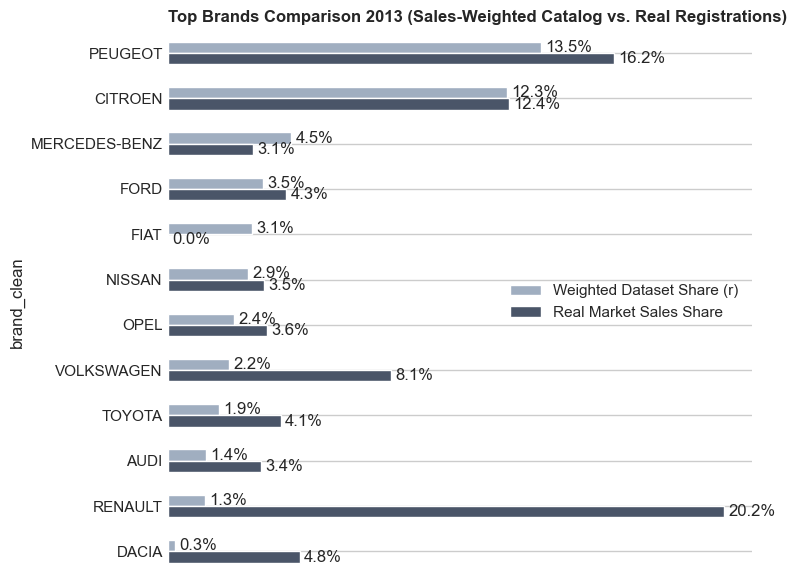

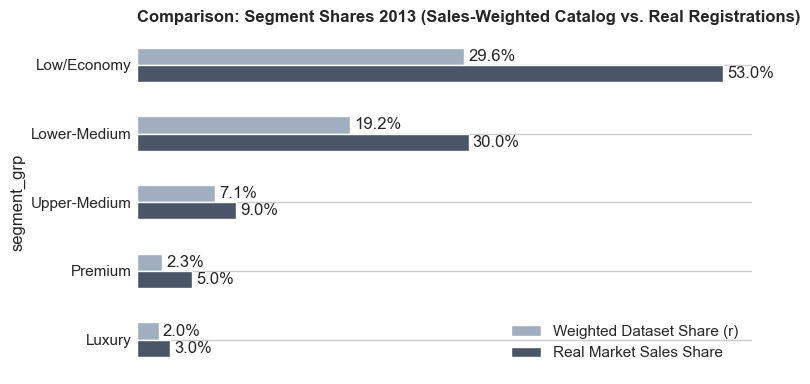

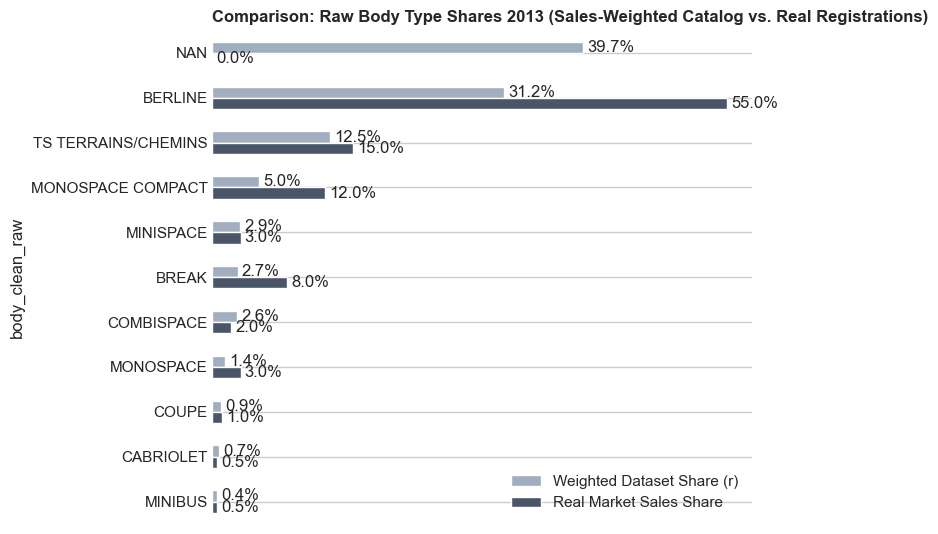

In [33]:
# weighted data in matched data: visualise market share vs weighted categories
print("looks not bad!\n But maybe we should look into brands like Fiat/ Citroen/ Peugeot/ ... to find out:\n Can we improve the matching code to include these brands?")

# Define plotting aesthetic settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# ---------------------------------------------------------------------------
# DIAGRAM 1: Brand Comparison (Weighted by 'r')

# Calculate weighted dataset shares using registration column 'r'
shares_brand = (df_joined.groupby('brand_clean')['r'].sum() / df_joined['r'].sum()) * 100
shares_brand = shares_brand.sort_values(ascending=False)

# Reference dict with real market registrations
real_market_brands = {
    'RENAULT': 20.2, 'PEUGEOT': 16.2, 'CITROEN': 12.4, 'VOLKSWAGEN': 8.1,
    'DACIA': 4.8, 'FORD': 4.3, 'TOYOTA': 4.1, 'OPEL': 3.6, 'NISSAN': 3.5,
    'AUDI': 3.4, 'MERCEDES-BENZ': 3.1, 'BMW': 3.0
}
real_shares_brand = [real_market_brands.get(cat, 0.0) for cat in shares_brand.index]

# Build plotting DataFrame
df_brands_plot = pd.DataFrame({
    'Weighted Dataset Share (r)': shares_brand.values,
    'Real Market Sales Share': real_shares_brand
}, index=shares_brand.index)

# Filter for >3% threshold
df_brands_filtered = df_brands_plot[(df_brands_plot['Weighted Dataset Share (r)'] > 3) | 
                                    (df_brands_plot['Real Market Sales Share'] > 3)].copy()

ax1 = df_brands_filtered.plot(kind='barh', color=['#a0aec0', '#4a5568'], figsize=(8, 6))
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', padding=3)
ax1.xaxis.set_visible(False)
ax1.tick_params(left=False)
ax1.invert_yaxis()
plt.box(False)
plt.title('Top Brands Comparison 2013 (Sales-Weighted Catalog vs. Real Registrations)', loc='left', weight='bold')
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# DIAGRAM 2: Segment Shares (Weighted by 'r')

# Calculate weighted dataset shares
shares_segment = (df_joined.groupby('segment_grp')['r'].sum() / df_joined['r'].sum()) * 100
shares_segment = shares_segment.sort_values(ascending=False)

# Reference dict with real market segment registrations
real_market_segments = {
    'Low/Economy': 53.0, 'Lower-Medium': 30.0, 'Upper-Medium': 9.0, 'Premium': 5.0, 'Luxury': 3.0
}
real_shares_segment = [real_market_segments.get(cat, 0.0) for cat in shares_segment.index]

df_segments_plot = pd.DataFrame({
    'Weighted Dataset Share (r)': shares_segment.values,
    'Real Market Sales Share': real_shares_segment
}, index=shares_segment.index)

ax2 = df_segments_plot.plot(kind='barh', color=['#a0aec0', '#4a5568'], figsize=(8, 4))
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', padding=3)
ax2.xaxis.set_visible(False)
ax2.tick_params(left=False)
ax2.invert_yaxis()
plt.box(False)
plt.title('Comparison: Segment Shares 2013 (Sales-Weighted Catalog vs. Real Registrations)', loc='left', weight='bold')
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# DIAGRAM 3: Raw Body Type Shares (Weighted by 'r')

# Clean and prepare raw body type categories on the merged frame
df_joined['body_clean_raw'] = df_joined['body_type'].astype(str).str.upper().str.strip()

# Calculate weighted dataset shares
shares_body = (df_joined.groupby('body_clean_raw')['r'].sum() / df_joined['r'].sum()) * 100
shares_body = shares_body.sort_values(ascending=False)

# Reference dict with real market body type registrations
real_market_bodies = {
    'BERLINE': 55.0, 'MONOSPACE COMPACT': 12.0, 'TS TERRAINS/CHEMINS': 15.0, 'BREAK': 8.0,
    'MINISPACE': 3.0, 'MONOSPACE': 3.0, 'COMBISPACE': 2.0, 'COUPE': 1.0, 'MINIBUS': 0.5, 'CABRIOLET': 0.5
}
real_shares_body = [real_market_bodies.get(cat, 0.0) for cat in shares_body.index]

df_body_plot = pd.DataFrame({
    'Weighted Dataset Share (r)': shares_body.values,
    'Real Market Sales Share': real_shares_body
}, index=shares_body.index)

ax3 = df_body_plot.plot(kind='barh', color=['#a0aec0', '#4a5568'], figsize=(8, 5.5))
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.1f%%', padding=3)
ax3.xaxis.set_visible(False)
ax3.tick_params(left=False)
ax3.invert_yaxis()
plt.box(False)
plt.title('Comparison: Raw Body Type Shares 2013 (Sales-Weighted Catalog vs. Real Registrations)', loc='left', weight='bold')
plt.tight_layout()
plt.show()



# Step 3 / Modeling

Step 1 — Deadline: July 9

- Build your first modeling iterations with baseline models.
- Analyze your initial results — is your approach relevant? Is your model?


Step 2 — Deadline: July 23

- Use Machine Learning and statistical metrics to fully exploit and understand your model’s results.
- Optimization: Try to improve your model using optimization tools; you can try more complex models and compare results.


Step 3 — Deadline: July 30
Advanced modeling: Use bagging/boosting techniques and Deep Learning.
Interpretability: Use interpretability tools to better understand your model results.
Scientific and business conclusions based on the success or failure of the modeling.

Deliverable 2: Modeling report.

# 1. Business question: How should car brands optimize the characteristics of the car to reduce CO2 and NOx weighted on their registrations? PD

We want to predict two targets at once (CO2 in g/km and NOx in g/km) from
vehicle characteristics (power, weight, engine size, width, fuel type,
transmission, segment, body type). Each row in our data represents a
vehicle configuration, and "r_merged" tells us how many real registrations
that configuration represents. We treat r_merged as a WEIGHT, so that a
configuration sold 50,000 times influences the model much more than a rare
configuration sold 3 times. This is important: without weighting, the model
would treat a niche low-volume car exactly as important as a mass-market
best-seller, which does not reflect reality.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor


In [35]:
# STEP 1 — Define which columns are features, targets, and weight
# ============================================================================
#   We explicitly list numeric features, categorical features, the two
#   targets we want to predict, and the weight column.

NUMERIC_FEATURES = [
    "power_max_kw", "kerb_weight_min_kg", "ec (cm3)",
    "w (mm)",                 
    "at1 (mm)", "at2 (mm)",   
]
CATEGORICAL_FEATURES = [
    "fuel_grp", "transmission", "segment_grp", "body_type_grp",
    "hybrid",  
]
TARGETS = ["co2_g_km", "nox_g_km"]
WEIGHT = "r_merged"

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES


In [36]:
# STEP 1b — Load df_model (replaces df_joined as the modeling source)
# ============================================================================
# WHY:
#   df_joined (and the deduplicated df_ml built from it in Step 2b) only
#   has r_merged populated for rows where _merge == 'both', i.e. rows
#   where the merge pipeline actually found a df_eu match. nox_g_km, on
#   the other hand, only exists in df_fr. So Step 2's cleaning (drop rows
#   with a missing target OR a missing weight) always collapsed onto the
#   'both' subset - roughly 1/4 of df_joined - no matter how that
#   cleaning step itself was written; the root cause sat upstream in the
#   merge match rate, not in the cleaning logic.
#
#   df_model.csv is an already-consolidated, deduplicated export where
#   every row is a confirmed df_fr <-> df_eu match (_merge == 'both'), so
#   r_merged is populated for (almost) the whole file. Using it here
#   means Step 2 no longer loses 3/4 of the data to merge coverage.
#
# OPEN QUESTION - please document before the final submission:
#   Where exactly does df_model.csv come from? If it was generated by a
#   script/notebook cell (e.g. an export of df_joined filtered to
#   _merge == 'both' plus dedup), that step should be shown or referenced
#   here so the pipeline stays reproducible end-to-end. If it was a manual,
#   one-off export, that is a reproducibility gap a grader could flag -
#   worth turning into a documented, re-runnable step.

import pandas as pd

if "df_model" not in globals():
    df_model = pd.read_csv("co2/df_model.csv")

print(f"df_model loaded: {df_model.shape[0]:,} rows x {df_model.shape[1]} columns")
if "_merge" in df_model.columns:
    print(df_model["_merge"].value_counts())


df_model loaded: 3,660 rows x 54 columns
_merge
both    3660
Name: count, dtype: int64


In [37]:
# STEP 2 — Build the modeling table and clean it
# ============================================================================
# WHAT:
#   We pull only the columns we need out of df_model, then remove rows
#   where we cannot use them for training.
#
# WHY:
#   - Rows with a missing target (co2_g_km or nox_g_km) cannot be used to
#     train or evaluate a supervised model — there is nothing to compare
#     the prediction against.
#   - Rows with a missing or zero/negative weight cannot be meaningfully
#     weighted. A weight of 0 or NaN would either crash the weighted
#     R2/RMSE calculations or silently make that row invisible to the
#     model in a confusing way, so we remove those rows explicitly instead
#     of letting sklearn fail with a cryptic error later.
#
# CHANGE vs. the earlier version of this notebook (df_joined -> df_model):
#   df_joined contained every row from the outer join, so r_merged (our
#   WEIGHT) only existed for _merge == 'both' rows, and this cleaning step
#   was effectively capped at the merge match rate (~1/4 of df_joined),
#   regardless of what happened in this cell (see Step 2a/2b for the root
#   cause). df_model is already the deduplicated, matched-only export
#   (_merge == 'both' for essentially every row), so this step now only
#   drops the small number of rows with a genuinely missing target or
#   weight value — not rows that were simply never matched in the first
#   place.
#
# PROBLEM WE ARE STILL AWARE OF:
#   Dropping rows changes the dataset size and could introduce bias if the
#   dropped rows are not random (e.g. if missing NOx values are
#   concentrated in one fuel type). We print before/after counts so this
#   is visible and can be sanity-checked, rather than happening silently.

model_df = df_model[FEATURES + TARGETS + [WEIGHT]].copy()
merge_status = df_model["_merge"] if "_merge" in df_model.columns else None

before = len(model_df)
missing_target = model_df[TARGETS].isna().any(axis=1)
missing_or_zero_weight = model_df[WEIGHT].isna() | (model_df[WEIGHT] <= 0)
dropped_mask = missing_target | missing_or_zero_weight

print("=== Why rows get dropped in this cleaning step ===")
print(f"Rows total:                         {before:,}")
print(f"  - missing co2_g_km or nox_g_km:   {missing_target.sum():,}")
print(f"  - missing/zero/negative r_merged: {missing_or_zero_weight.sum():,}")
print(f"  - dropped by either reason:       {dropped_mask.sum():,}")

if merge_status is not None:
    print("\n_merge status of the dropped rows (should now be almost entirely")
    print("target/weight issues, not merge-coverage issues):")
    print(merge_status[dropped_mask].value_counts())

model_df = model_df.dropna(subset=TARGETS + [WEIGHT])
model_df = model_df[model_df[WEIGHT] > 0]
print(f"\nRows before target/weight cleaning: {before:,} -> after: {len(model_df):,}")

print("\nMissing values per feature (these are NOT dropped here — they are")
print("handled later by imputation inside the pipeline, see Step 4):")
print(model_df[FEATURES].isna().sum())


=== Why rows get dropped in this cleaning step ===
Rows total:                         3,660
  - missing co2_g_km or nox_g_km:   25
  - missing/zero/negative r_merged: 0
  - dropped by either reason:       25

_merge status of the dropped rows (should now be almost entirely
target/weight issues, not merge-coverage issues):
_merge
both    25
Name: count, dtype: int64

Rows before target/weight cleaning: 3,660 -> after: 3,635

Missing values per feature (these are NOT dropped here — they are
handled later by imputation inside the pipeline, see Step 4):
power_max_kw            0
kerb_weight_min_kg      0
ec (cm3)                0
w (mm)                  0
at1 (mm)                0
at2 (mm)              325
fuel_grp                0
transmission            0
segment_grp             0
body_type_grp           0
hybrid                  0
dtype: int64


In [ ]:
# STEP 3 — Train/test split
# ============================================================================
# WHAT:
#   We split the data 80/20 into training and test, with two improvements
#   over a plain random split:
#     1) GROUPED by "sibling" configuration (see the check below): trim
#        variants of essentially the same underlying car now always land
#        entirely in train OR entirely in test - never split across both.
#     2) STRATIFIED on a combined fuel_grp x segment_grp label, so both
#        matter for keeping train/test representative, not just fuel_grp.
#   sklearn's StratifiedGroupKFold does exactly this: stratify AND group
#   at the same time.
#
# WHY THIS CHANGED (vs. the previous version of this notebook):
#   The previous version stratified on fuel_grp only, and only DIAGNOSED
#   sibling leakage (near-duplicate configurations landing in both train
#   and test) without acting on it - so the test score could be optimistic
#   whenever sibling_share was high, and there was no guarantee small
#   segments were represented in the test set. This version fixes both.
#
# PROBLEM WE ARE STILL AWARE OF:
#   - Grouping by config_group_id assumes the rounding tolerances below
#     (ROUND_TO) correctly capture "same underlying car, different trim".
#     Too coarse and genuinely different cars could get merged into one
#     group; too fine and real siblings could still leak. The sensitivity
#     check right below compares group counts at 2x coarser / 2x finer
#     tolerances so this assumption is at least visible, not silent.
#   - Very small (fuel_grp, segment_grp) combinations may still be
#     under-represented if they form very few sibling groups overall -
#     StratifiedGroupKFold does its best but can't create data that
#     does not exist. random_state=42 is fixed for reproducibility.

from sklearn.model_selection import StratifiedGroupKFold

# ---- Sibling grouping key, built BEFORE the split on the full model_df ----
ROUND_TO = {"power_max_kw": 5, "kerb_weight_min_kg": 50, "ec (cm3)": 100,
            "w (mm)": 10, "at1 (mm)": 10, "at2 (mm)": 10}

def config_fingerprint(X, round_to=ROUND_TO):
    rounded = pd.DataFrame({c: (X[c] / step).round() * step for c, step in round_to.items()})
    return pd.util.hash_pandas_object(pd.concat([rounded, X[CATEGORICAL_FEATURES]], axis=1), index=False)

model_df["config_group_id"] = config_fingerprint(model_df)

# Sensitivity check: how much does the exact tolerance choice matter?
coarser = {c: s * 2 for c, s in ROUND_TO.items()}
finer = {c: s / 2 for c, s in ROUND_TO.items()}
n_groups_normal = model_df["config_group_id"].nunique()
n_groups_coarser = config_fingerprint(model_df, coarser).nunique()
n_groups_finer = config_fingerprint(model_df, finer).nunique()
print("Sensitivity of the sibling grouping to the rounding tolerance:")
print(f"  2x coarser tolerance: {n_groups_coarser:,} groups")
print(f"  current tolerance:    {n_groups_normal:,} groups")
print(f"  2x finer tolerance:   {n_groups_finer:,} groups")
print("(close numbers => the grouping is reasonably robust to the exact tolerance)\n")

# ---- Stratified, grouped split ----
X = model_df[FEATURES]
y = model_df[TARGETS]
w = model_df[WEIGHT]
groups = model_df["config_group_id"]
strat_label = X["fuel_grp"].astype(str) + "_" + X["segment_grp"].astype(str)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)  # 1 fold ~ 20% test
train_idx, test_idx = next(sgkf.split(X, strat_label, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
w_train, w_test = w.iloc[train_idx], w.iloc[test_idx]

# Keep the grouping/stratification information for cross-validation inside the training set.
# This makes the hyperparameter search use the same leakage protection as the final train/test split.
groups_train = groups.iloc[train_idx]
strat_label_train = strat_label.iloc[train_idx]

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Weighted training volume: {w_train.sum():,.0f} | Weighted test volume: {w_test.sum():,.0f}")

print("\nFuel type share, train vs. test:")
fuel_share = pd.concat([
    X_train["fuel_grp"].value_counts(normalize=True).rename("train_share"),
    X_test["fuel_grp"].value_counts(normalize=True).rename("test_share"),
], axis=1)
print(fuel_share.round(4))

print("\nSegment share, train vs. test (NEW - not checked in the previous version):")
segment_share = pd.concat([
    X_train["segment_grp"].value_counts(normalize=True).rename("train_share"),
    X_test["segment_grp"].value_counts(normalize=True).rename("test_share"),
], axis=1)
print(segment_share.round(4))

# ---- Confirm the sibling leakage is actually gone, not just measured ----
train_groups = set(groups.iloc[train_idx])
sibling_share_after = groups.iloc[test_idx].isin(train_groups).mean()
print(f"\nShare of test rows with a sibling group also present in train "
      f"(should be ~0% by construction now): {sibling_share_after:.1%}")
print("Compare this to the old, ungrouped random split's sibling_share to see the fix's effect.")


In [39]:
# STEP 4 - Preprocessing the data
# ============================================================================
# What we do here:
#   Before we can feed the data into a model, we need to "clean it up".
#   For the numeric columns (e.g. weight, engine size) we fill missing
#   values with the median (the mean would be more sensitive to outliers,
#   e.g. one extremely heavy car) and then scale the values (mean 0,
#   standard deviation 1). For the categorical columns (e.g. fuel type) we
#   fill missing values with the most common value and turn them into 0/1
#   columns with One-Hot-Encoding, because models cannot work with text.
#
# Why we do it this way:
#   Ridge is a linear model and is sensitive to the size of the numbers
#   (mm vs. kW), so we scale the numeric features. The tree-based models
#   (Random Forest, Gradient Boosting, XGBoost) don't really need this,
#   but it doesn't hurt them either, so we just use the same preprocessing
#   for every model.
#
# Problem we are aware of:
#   If the test set (or new data later) contains a category that never
#   showed up in training (e.g. a new fuel type), OneHotEncoder would
#   normally throw an error. With handle_unknown="ignore" that case is
#   simply encoded as "all zeros" instead of crashing the program.

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC_FEATURES),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), CATEGORICAL_FEATURES),
])



In [ ]:
# STEP 4b - Baseline model (weighted mean)
# ==============================================
# What we do here:
#   Before comparing the four "real" models in Step 5, we fit a trivial
#   baseline: a model that ignores every feature and always predicts the
#   (weighted) mean of the training targets. It has no hyperparameters, so
#   there is nothing to tune - but we still score it with the same weighted
#   K-Fold cross-validation as the other models, so its CV score is directly
#   comparable to Step 5's results later in the comparison table (Step 6).
#
# Why we need this:
#   1) Our project plan explicitly asks for a baseline model at Step 1 
#   2) A weighted R2 of e.g. 0.98 only means something in context. This
#      baseline shows how much the "real" models actually add over simply
#      guessing the (weighted) average CO2/NOx value for every car. If a
#      real model only marginally beat this baseline, that would be an
#      important - and honest - finding to report.
#
# Note on sample_weight here:
#   DummyRegressor(strategy="mean") supports sample_weight in .fit(), so
#   "weighted mean" here really means the registration-weighted average,
#   consistent with how every other model in this notebook is trained.

from sklearn.dummy import DummyRegressor

def make_baseline_pipe(params=None):
    return Pipeline([
        ("prep", preprocessor),
        ("model", MultiOutputRegressor(DummyRegressor(strategy="mean"))),
    ])

def evaluate_baseline_cv(X, y, w, groups, strat_label, n_splits=5, random_state=42):
    """Same weighted grouped + stratified 5-fold logic as Step 5's weighted_kfold_search, but
    without any hyperparameters to search over, and tracking CV R2
    separately per target (not just averaged across both), since that is
    what Step 6 needs for a fair, target-specific model comparison."""
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_scores_per_target = {t: [] for t in TARGETS}

    for train_idx, val_idx in cv.split(X, strat_label, groups=groups):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        w_tr, w_val = w.iloc[train_idx], w.iloc[val_idx]

        pipe = make_baseline_pipe()
        pipe.fit(X_tr, y_tr, model__sample_weight=w_tr)
        pred = pipe.predict(X_val)

        for i, target in enumerate(TARGETS):
            score = r2_score(y_val.iloc[:, i], pred[:, i], sample_weight=w_val)
            fold_scores_per_target[target].append(score)

    return {t: float(np.mean(scores)) for t, scores in fold_scores_per_target.items()}


baseline_cv_per_target = evaluate_baseline_cv(
    X_train, y_train, w_train, groups_train, strat_label_train
)
print("Baseline (weighted mean) - weighted CV R2 per target:")
for t, s in baseline_cv_per_target.items():
    print(f"  {t}: {round(s, 4)}")

baseline_final = make_baseline_pipe()
baseline_final.fit(X_train, y_train, model__sample_weight=w_train)
print("\nBaseline fitted on the full training set - will be included in the Step 6 comparison table.")


In [ ]:
# STEP 5 - Tuning the four models with a weighted, grouped + stratified CV search
# ============================================================================
# What we do here:
#   We try four different models: Ridge (a simple linear model), Gradient
#   Boosting, Random Forest and XGBoost (all three tree-based). For each
#   model we test every combination from a small parameter grid, and keep
#   the combination that scored best in cross-validation - using WEIGHTED
#   R2 (weighted by r_merged, i.e. real-world registration numbers), so the
#   hyperparameter selection is consistent with how we evaluate and report
#   results everywhere else in this notebook (Step 6, Step 8).
#
# How it works:
#   For every parameter combination, we run 5-fold grouped + stratified cross-validation. In
#   each fold we fit the pipeline with that fold's training weights, then
#   compute weighted R2 on the held-out fold with that fold's weights. We
#   track this BOTH as one combined score (mean across CO2 and NOx, used
#   only to pick the best hyperparameters within a given model type) AND
#   separately per target (used in Step 6 to pick the best MODEL per
#   target - see the note below).
#
# Model selection is based on CV, not the test set:
#   Step 6 selects the best model per target using the weighted CV R2
#   computed here, not the test set. The test set is only used in Step 6
#   to report an honest, independent performance number for the model we
#   already chose - not to decide which model to choose. Using the
#   "held-out" test set to make that decision would quietly break the
#   promise (see Step 3) that the test set is never touched until the end.
#
# Why weighting matters here:
#   Not every row in our data represents a car that was actually sold in
#   large numbers. If we treat every row as equally important, the model
#   (and the hyperparameter search) could waste effort fitting rare,
#   barely-sold configurations just as much as common ones.
#
# Why MultiOutputRegressor for some of the models:
#   We want to predict two target values at the same time (CO2 and NOx).
#   Ridge and GradientBoostingRegressor cannot do this by themselves, so
#   we wrap them in MultiOutputRegressor, which internally just trains two
#   separate models (one for CO2, one for NOx). RandomForestRegressor and
#   XGBRegressor can predict several targets directly, so no wrapper is
#   needed there (see the xgboost version check in the imports cell).



def weighted_kfold_search(
    pipe_builder, param_grid, X, y, w, groups, strat_label,
    n_splits=5, random_state=42
):
    # IMPORTANT: use the same grouped + stratified CV logic as Step 3.
    # Grouping prevents near-identical vehicle configurations from appearing
    # in both a fold's training and validation data; stratification keeps the
    # fuel/segment mix reasonably balanced across folds.
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    keys = list(param_grid.keys())
    all_results = []

    for combo in product(*param_grid.values()):
        params = dict(zip(keys, combo))
        fold_scores_combined = []
        fold_scores_per_target = {t: [] for t in TARGETS}

        for train_idx, val_idx in cv.split(X, strat_label, groups=groups):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
            w_tr, w_val = w.iloc[train_idx], w.iloc[val_idx]

            pipe = pipe_builder(params)
            pipe.fit(X_tr, y_tr, model__sample_weight=w_tr)
            pred = pipe.predict(X_val)

            target_scores = []
            for i, target in enumerate(TARGETS):
                score = r2_score(y_val.iloc[:, i], pred[:, i], sample_weight=w_val)
                target_scores.append(score)
                fold_scores_per_target[target].append(score)
            fold_scores_combined.append(np.mean(target_scores))

        combined_score = float(np.mean(fold_scores_combined))
        per_target_score = {t: float(np.mean(v)) for t, v in fold_scores_per_target.items()}

        all_results.append({
            **params,
            "weighted_R2_cv": combined_score,
            **{f"weighted_R2_cv__{t}": per_target_score[t] for t in TARGETS},
        })

    results_df = pd.DataFrame(all_results).sort_values("weighted_R2_cv", ascending=False)

    best_entry = max(all_results, key=lambda d: d["weighted_R2_cv"])
    best_score = best_entry["weighted_R2_cv"]
    best_per_target_score = {t: best_entry[f"weighted_R2_cv__{t}"] for t in TARGETS}
    exclude_keys = {"weighted_R2_cv"} | {f"weighted_R2_cv__{t}" for t in TARGETS}
    best_params = {k: v for k, v in best_entry.items() if k not in exclude_keys}
    return best_params, best_score, best_per_target_score, results_df


def make_model_pipe(estimator, needs_wrapper):
    """Wraps an estimator in MultiOutputRegressor when it cannot predict
    both targets by itself (Ridge, Gradient Boosting), and puts it behind
    the shared preprocessing step (Step 4)."""
    model = MultiOutputRegressor(estimator) if needs_wrapper else estimator
    return Pipeline([("prep", preprocessor), ("model", model)])

MODEL_SPECS = {
    "Ridge": {
        "build_estimator": lambda p: Ridge(alpha=p["alpha"]),
        "needs_wrapper": True,
        "param_grid": {"alpha": [0.1, 1.0, 10.0, 100.0]},
    },
    "Gradient Boosting": {
        "build_estimator": lambda p: GradientBoostingRegressor(
            n_estimators=p["n_estimators"], max_depth=p["max_depth"], random_state=42
        ),
        "needs_wrapper": True,
        "param_grid": {"n_estimators": [100, 200], "max_depth": [2, 3]},
    },
    "Random Forest": {
        "build_estimator": lambda p: RandomForestRegressor(
            n_estimators=p["n_estimators"], max_depth=p["max_depth"],
            max_features=p["max_features"], min_samples_leaf=p["min_samples_leaf"],
            random_state=42, n_jobs=-1,
        ),
        "needs_wrapper": False,
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [10, 15, None],
            "max_features": ["sqrt", 0.8],
            "min_samples_leaf": [1, 3],
        },
    },
    "XGBoost": {
        "build_estimator": lambda p: XGBRegressor(
            n_estimators=p["n_estimators"], max_depth=p["max_depth"],
            learning_rate=p["learning_rate"], subsample=p["subsample"],
            colsample_bytree=p["colsample_bytree"], random_state=42, n_jobs=-1,
        ),
        "needs_wrapper": False,
        "param_grid": {
            "n_estimators": [200, 300],
            "max_depth": [3, 5],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
        },
    },
}

# The CV folds deliberately use the same sibling-group definition as the
# final train/test split. This is important: using ordinary KFold here would
# re-introduce sibling/configuration leakage during hyperparameter tuning even
# though the final test split is grouped.

models = {"Baseline (mean)": baseline_final}
cv_scores = {"Baseline (mean)": float(np.mean(list(baseline_cv_per_target.values())))}
cv_scores_per_target = {"Baseline (mean)": baseline_cv_per_target}
search_results = {}  

for name, spec in MODEL_SPECS.items():
    print(f"=== {name}: weighted K-Fold search ===")

    def pipe_builder(params, spec=spec):
        return make_model_pipe(spec["build_estimator"](params), spec["needs_wrapper"])

    best_params, best_score, best_per_target, results_df = weighted_kfold_search(
        pipe_builder, spec["param_grid"], X_train, y_train, w_train,
        groups_train, strat_label_train
    )
    print(f"Best {name} parameters (weighted CV):", best_params)
    print("Best weighted CV R2 (combined):", round(best_score, 4))
    print("Best weighted CV R2 (per target):", {k: round(v, 4) for k, v in best_per_target.items()})

    final_pipe = pipe_builder(best_params)
    final_pipe.fit(X_train, y_train, model__sample_weight=w_train)

    models[name] = final_pipe
    cv_scores[name] = best_score
    cv_scores_per_target[name] = best_per_target
    search_results[name] = results_df
    print()


### Modelling methodology note

The hyperparameter search uses the same **StratifiedGroupKFold** structure as the final train/test split. Groups are defined from the vehicle-configuration fingerprint, while stratification preserves the fuel/segment composition as far as the available groups allow. This prevents near-identical vehicle configurations from appearing in both training and validation folds during model selection.

The test set remains untouched by model selection: hyperparameters and the best model per target are selected using cross-validation on the training set only. The test set is used once for the final performance check.


In [ ]:
# STEP 6 - Comparing the models and picking the best one
# ============================================================================
# What we do here:
#   We let all models (including the Step 4b baseline) make predictions on
#   the test set and compute weighted RMSE, MAE and R2 for both targets
#   (CO2, NOx), using sample_weight=w_test. We also bring in the weighted
#   CV R2 per target from Step 5 (weighted_R2_cv), so we can compare "how
#   the model did during cross-validation" against "how it does on data it
#   has genuinely never touched" (the test set).
#
# CHANGE vs. the earlier version of this notebook:
#   The best model per target is now selected using the weighted CV R2
#   from Step 5, NOT the test-set R2. The test set is still shown in the
#   table below and used for the cross-check, but it no longer influences
#   which model gets chosen. Reason: if the test set is used both to pick
#   the winning model AND to report that model's final performance, the
#   reported number is optimistic - the test set stops being a genuinely
#   independent check. Using CV for selection keeps the test set honest:
#   it is only touched once, at the very end, purely to report.
#
# Why exactly these three metrics:
#   - R2 tells us how much of the spread in the data the model can
#     explain (0 = no better than just predicting the average, 1 =
#     perfect).
#   - RMSE is in the same unit as the target (g/km) and punishes large
#     errors more heavily.
#   - MAE is also in g/km, but easier to explain ("on average we are off
#     by X g/km").
#
# Problem we are aware of:
#   Even with CV-based selection, both the CV folds and the test set come
#   from the same overall dataset and the same underlying (partially
#   matched, see Step 2/3 documentation) population of cars. A truly
#   independent validation (e.g. on a different year's data) would give an
#   even more reliable answer, but that data is not available here.

results = []
for name, model in models.items():
    df_predict = model.predict(X_test)
    for i, target in enumerate(TARGETS):
        rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], df_predict[:, i], sample_weight=w_test))
        mae = mean_absolute_error(y_test.iloc[:, i], df_predict[:, i], sample_weight=w_test)
        r2 = r2_score(y_test.iloc[:, i], df_predict[:, i], sample_weight=w_test)
        results.append({
            "model": name,
            "target": target,
            "weighted_RMSE": rmse,
            "weighted_MAE": mae,
            "weighted_R2": r2,
            "weighted_R2_cv": cv_scores_per_target[name][target],
        })

comparison_df = pd.DataFrame(results)
print("\n=== Comparing all models, incl. baseline, on the test set (weighted) ===")
print(comparison_df.round(4))

# Candidates for "best model" exclude the baseline on purpose (see note above).
candidates_df = comparison_df[comparison_df["model"] != "Baseline (mean)"]

print("\n=== Model selection (based on weighted CV R2) vs. test-set cross-check ===")
for target in TARGETS:
    subset = candidates_df[candidates_df["target"] == target]
    cv_best = subset.sort_values("weighted_R2_cv", ascending=False).iloc[0]["model"]
    test_best = subset.sort_values("weighted_R2", ascending=False).iloc[0]["model"]
    agreement = ("same model -> more confidence in this choice"
                 if cv_best == test_best
                 else "DIFFERENT - CV choice is still used, but flag this as a limitation in the report")
    print(f"{target}: CV-best (selection criterion) = {cv_best}, Test-best (reference only) = {test_best} -> {agreement}")

# Pick the best model per target using the CV score - this is now the
# actual selection criterion, not the test set.
best_model_name_co2 = candidates_df[candidates_df["target"] == "co2_g_km"] \
    .sort_values("weighted_R2_cv", ascending=False).iloc[0]["model"]
best_model_name_nox = candidates_df[candidates_df["target"] == "nox_g_km"] \
    .sort_values("weighted_R2_cv", ascending=False).iloc[0]["model"]

best_model_co2 = models[best_model_name_co2]
best_model_nox = models[best_model_name_nox]

print(f"\nBest model for CO2 (selected via CV): {best_model_name_co2}")
print(f"Best model for NOx (selected via CV): {best_model_name_nox}")

# Baseline reference: how much do the chosen models actually add over
# simply predicting the (weighted) average?
baseline_r2_co2 = comparison_df[(comparison_df["model"] == "Baseline (mean)") & (comparison_df["target"] == "co2_g_km")]["weighted_R2"].iloc[0]
baseline_r2_nox = comparison_df[(comparison_df["model"] == "Baseline (mean)") & (comparison_df["target"] == "nox_g_km")]["weighted_R2"].iloc[0]
chosen_r2_co2 = comparison_df[(comparison_df["model"] == best_model_name_co2) & (comparison_df["target"] == "co2_g_km")]["weighted_R2"].iloc[0]
chosen_r2_nox = comparison_df[(comparison_df["model"] == best_model_name_nox) & (comparison_df["target"] == "nox_g_km")]["weighted_R2"].iloc[0]

print(f"\nBaseline test R2 -> CO2: {baseline_r2_co2:.4f} | NOx: {baseline_r2_nox:.4f}")
print(f"Chosen model test R2 -> CO2: {chosen_r2_co2:.4f} ({best_model_name_co2}) | NOx: {chosen_r2_nox:.4f} ({best_model_name_nox})")
print("This comparison shows how much the chosen models improve over simply predicting the (weighted) average - "
      "the key number to justify using a real model at all.")


In [ ]:
# STEP 7 - Bar charts comparing the models (R2 and MAE)
# ============================================================================
# What we do here:
#   For CO2 and NOx we draw bar charts of the weighted R2 value of every
#   model (top row), and — CHANGE (v11) — a second row with weighted MAE
#   in g/km. R2 alone doesn't tell a non-technical reader anything
#   concrete; "we're off by X g/km on average" (MAE) is the number that
#   actually answers the business question, so both should be visible
#   side by side, not just buried in the Step 6 table.

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, target in zip(axes[0], TARGETS):
    subset = comparison_df[comparison_df["target"] == target].sort_values("weighted_R2")
    ax.barh(subset["model"], subset["weighted_R2"])
    ax.set_xlim(0, 1)
    ax.set_title(f"Weighted R2 - {target}")
    ax.set_xlabel("Weighted R2 (test set)")

for ax, target in zip(axes[1], TARGETS):
    subset = comparison_df[comparison_df["target"] == target].sort_values("weighted_MAE", ascending=False)
    ax.barh(subset["model"], subset["weighted_MAE"])
    ax.set_title(f"Weighted MAE - {target}")
    ax.set_xlabel("Weighted MAE (g/km, test set) - lower is better")

plt.tight_layout()
plt.show()


In [ ]:
# STEP 8 - Checking for overfitting (train vs. CV vs. test, weighted)
# ============================================================================
#
#   Previously this only compared train vs. test. That misses an
#   important middle step: the weighted CV R2 from Step 5/4b is itself an
#   estimate made on data each fold's model did NOT see during that
#   fold's training, so looking at train -> CV -> test tells us more:
#     - train vs. CV gap: how much a model overfits during the search
#       itself (this is exactly what cross-validated hyperparameter
#       tuning is supposed to guard against).
#     - CV vs. test gap: whether the CV estimate generalizes to a
#       genuinely held-out set that never influenced model selection at
#       all (see Step 3/6 notes on why the test set was kept separate).
#   If CV and test are close but both sit below train, that is a normal,
#   expected generalization gap — not a red flag. If CV is far above
#   test, that is the real warning sign: it means even the CV estimate
#   was too optimistic, e.g. because CV folds and test rows are not truly
#   independent (see the "problem we are aware of" note in Step 6).
#
# Why this matters:
#   A model can look great on the training data because it basically
#   "memorized" it, but still be bad on new data (overfitting). Looking
#   at three points instead of two makes it much easier to tell WHERE a
#   generalization problem would come from, if there is one, rather than
#   just seeing that "training is a bit higher than test" without knowing
#   whether that's the tuning step or the final holdout causing it.
#
# Problem we are aware of:
#   Random Forest in particular can get an almost perfect training score,
#   because deep trees can basically remember almost every single
#   training row. A high training score alone doesn't tell us much —
#   what matters is the gap to CV and test. Since all three scores are
#   weighted here, this comparison specifically tells us how well the
#   model generalizes for the cars that are actually common on the road.

overfit_results = []
for name, model in models.items():
    df_predict_train = model.predict(X_train)
    df_predict_test = model.predict(X_test)
    for i, target in enumerate(TARGETS):
        r2_train = r2_score(y_train.iloc[:, i], df_predict_train[:, i], sample_weight=w_train)
        r2_cv = cv_scores_per_target[name][target]
        r2_test = r2_score(y_test.iloc[:, i], df_predict_test[:, i], sample_weight=w_test)
        overfit_results.append({
            "model": name, "target": target,
            "weighted_R2_train": r2_train,
            "weighted_R2_cv": r2_cv,
            "weighted_R2_test": r2_test,
            "gap_train_cv": r2_train - r2_cv,
            "gap_cv_test": r2_cv - r2_test,
        })

overfit_df = pd.DataFrame(overfit_results)
print("\n=== Train vs. CV vs. test weighted R2 ===")
print("A big train->CV gap means the model overfits during tuning itself.")
print("A big CV->test gap means even the CV estimate was too optimistic.")
print(overfit_df.round(4).sort_values("gap_train_cv", ascending=False))


In [ ]:
# STEP 9 - Feature importance (which input affects CO2 / NOx the most)
# ============================================================================
# What we do here:
#   For the tree-based models (Random Forest, Gradient Boosting, XGBoost)
#   there is a built-in property feature_importances_ that shows how
#   important each column was for the prediction. For Ridge (a linear
#   model) there is no feature_importances_, but there IS something even
#   more directly interpretable: the model's coefficients, which tell us
#   not just how important a feature is, but in which direction it pushes
#   the prediction (and by how much, on the standardized scale). Since we
#   now use a different "best" model per target, we print whichever of
#   the two applies for best_model_co2 and best_model_nox separately.
#
# Why this matters:
#   Just knowing "the model has R2 = 0.9" is often not enough. People also
#   want to know WHY the model predicts what it predicts, e.g. "weight is
#   the most important factor". That is usually the actual question
#   behind the whole analysis — and if Ridge happens to be the best model
#   for a target, we don't want to just skip this question.

# FIX: for Random Forest / XGBoost, CO2 and NOx are predicted by the SAME
# fitted model object when that model wins for both targets (they predict
# both targets natively, unlike Ridge/GB which train one model per target
# via MultiOutputRegressor). In that case feature_importances_ is one
# single array shared by both targets - so the two rankings below aren't
# just similar, they are identical. This check makes that visible instead
# of leaving it looking like a coincidence.
same_model_for_both_targets = best_model_name_co2 == best_model_name_nox
if same_model_for_both_targets:
    print(f"NOTE: {best_model_name_co2} was selected for BOTH targets. For this "
          f"model type, feature_importances_ is one shared array, so the CO2 and "
          f"NOx rankings below will be IDENTICAL, not just similar. Use SHAP "
          f"(Step 9b) for a per-target breakdown instead.")

def show_feature_importance(model, target_name):
    step = model.named_steps["model"]
    feature_names = model.named_steps["prep"].get_feature_names_out()

    if hasattr(step, "feature_importances_"):
        importance = pd.Series(step.feature_importances_, index=feature_names)
        print(f"\n=== Feature importance for {target_name} (tree-based model, raw values after one-hot encoding) ===")
        print(importance.sort_values(ascending=False).round(4))
        return

    # Ridge is wrapped in MultiOutputRegressor, so step.estimators_ holds
    # one fitted Ridge per target - we need to find the one for this target.
    if hasattr(step, "estimators_"):
        target_index = TARGETS.index("co2_g_km" if "CO2" in target_name else "nox_g_km")
        inner_model = step.estimators_[target_index]
        if hasattr(inner_model, "coef_"):
            coefs = pd.Series(inner_model.coef_, index=feature_names)
            print(f"\n=== Ridge coefficients for {target_name} (standardized scale, after one-hot encoding) ===")
            print("Positive = pushes the prediction up, negative = pushes it down.")
            print(coefs.sort_values(key=abs, ascending=False).round(4))
            return

    print(f"\n=== Feature importance for {target_name} skipped "
          f"(the best model here does not expose feature_importances_ or coef_) ===")

show_feature_importance(best_model_co2, "CO2")
show_feature_importance(best_model_nox, "NOx")

# ----------------------------------------------------------------------
# WHY DO THE CO2 AND NOX RANKINGS LOOK SO SIMILAR?
# ----------------------------------------------------------------------
# If the two selected models differ, similar rankings simply mean CO2 and
# NOx are genuinely correlated in the data (mainly via fuel type, see
# 1b/1d) - checked below, not just assumed. If it's the SAME model (see
# the NOTE above), the rankings aren't just similar, they are the
# identical array printed twice - a display limitation, not a data insight.

target_corr = y_train["co2_g_km"].corr(y_train["nox_g_km"])
print(f"\nCorrelation between actual co2_g_km and nox_g_km (training set): {target_corr:.3f}")
print("A high positive correlation here is the main reason the two importance")
print("rankings look alike — both targets are driven by overlapping physical causes,")
print("most importantly fuel type (see the fuel-type breakdown in section 1d).")

def get_importance_series(model, target_name):
    """Same logic as show_feature_importance, but returns the Series
    instead of printing it, so CO2 vs. NOx can be compared side by side."""
    step = model.named_steps["model"]
    feature_names = model.named_steps["prep"].get_feature_names_out()
    if hasattr(step, "feature_importances_"):
        return pd.Series(step.feature_importances_, index=feature_names)
    if hasattr(step, "estimators_"):
        target_index = TARGETS.index("co2_g_km" if "CO2" in target_name else "nox_g_km")
        inner_model = step.estimators_[target_index]
        if hasattr(inner_model, "coef_"):
            return pd.Series(inner_model.coef_, index=feature_names).abs()
    return None

imp_co2 = get_importance_series(best_model_co2, "CO2")
imp_nox = get_importance_series(best_model_nox, "NOx")

if same_model_for_both_targets:
    print("\n(Side-by-side comparison skipped: same model for both targets, so the")
    print("two importance columns would just be identical - see NOTE above instead.)")
elif imp_co2 is not None and imp_nox is not None:
    side_by_side = pd.DataFrame({
        "CO2_importance": imp_co2,
        "NOx_importance": imp_nox,
    }).sort_values("CO2_importance", ascending=False)
    rank_corr = side_by_side["CO2_importance"].rank().corr(side_by_side["NOx_importance"].rank())
    print("\n=== CO2 vs. NOx importance, side by side (sorted by CO2 importance) ===")
    print(side_by_side.round(4))
    print(f"\nSpearman rank correlation between the two importance rankings: {rank_corr:.3f}")
    print("A value close to 1.0 confirms the two models rank features similarly - ")
    print("consistent with the target correlation above, not a modeling error.")
    print("See Step 9b (SHAP) for the clearer, per-feature, per-car breakdown.")
else:
    print("\n(Side-by-side CO2 vs. NOx importance comparison skipped - one of the")
    print("two best models does not expose feature_importances_ or coef_.)")


In [ ]:
# STEP 9b - SHAP: deeper interpretability for CO2 / NOx 
# ============================================================================
# What we do here:
#   feature_importances_ (Step 9) only tells us HOW MUCH a feature
#   mattered on average across the whole training set, and — for
#   tree-based models — without a sign: we don't see whether high weight
#   pushes CO2 up or down, or whether that effect is the same for every
#   car. SHAP (SHapley Additive exPlanations) fixes both gaps:
#     - it gives every single prediction its own per-feature contribution
#       (in g/km, the same unit as the target), with a sign, so we can
#       say e.g. "for this car, +150 kg of weight added +9.2 g/km CO2";
#     - averaging the absolute SHAP value per feature gives a ranking
#       directly comparable to Step 9, but the underlying per-row values
#       also let us see interaction effects and outliers, not just a
#       single average number.
#   This directly serves the Liora requirement to use an interpretability
#   tool, and gives the business question ("which characteristics should
#   brands change to reduce CO2/NOx") a much more concrete, per-feature,
#   per-car answer than a single global importance ranking.
#
# Which explainer we use:
#   TreeExplainer works directly and efficiently on tree-based models
#   (Random Forest, Gradient Boosting, XGBoost) and is exact for these
#   model types (not an approximation). If the best model for a target
#   happens to be Ridge instead, we fall back to LinearExplainer, the
#   exact equivalent for linear models.
#
# Why we explain on a SAMPLE of the test set, not all of it:
#   SHAP is computed per row, so cost scales with the number of rows. A
#   few hundred rows already gives a stable picture of feature effects;
#   using the full test set would just cost more time for the same
#   conclusions here.
#
# Problem we are aware of:
#   SHAP values are computed on the PRE-PROCESSING output (after
#   imputation/scaling/one-hot encoding), not on the raw input columns —
#   that's why feature names below look like "num__power_max_kw" or
#   "cat__fuel_grp_GO" instead of the plain column names. This is the
#   same naming Step 9 already uses for feature_importances_/coef_, so
#   the two are directly comparable, but it means SHAP effects for a
#   one-hot column describe "this car IS this category" vs. "this car is
#   NOT this category", not a continuous effect.

try:
    import shap
except ImportError:
    import sys
    get_ipython().system(f"{sys.executable} -m pip install shap --quiet --break-system-packages")
    import shap

SHAP_SAMPLE_SIZE = 300  # keep this moderate; SHAP cost grows with rows

def explain_with_shap(model, target_name, X_background, X_explain):
    step = model.named_steps["model"]
    prep = model.named_steps["prep"]
    feature_names = prep.get_feature_names_out()

    X_bg_t = prep.transform(X_background)
    X_ex_t = prep.transform(X_explain)
    # OneHotEncoder output can be sparse; SHAP wants dense arrays.
    if hasattr(X_bg_t, "toarray"):
        X_bg_t = X_bg_t.toarray()
    if hasattr(X_ex_t, "toarray"):
        X_ex_t = X_ex_t.toarray()

    target_index = TARGETS.index("co2_g_km" if "CO2" in target_name else "nox_g_km")

    if hasattr(step, "feature_importances_"):
        # Random Forest / XGBoost predict both targets directly - point
        # the explainer at the right output column. shap's return shape
        # for multi-output tree models varies by version (list of arrays
        # vs. a single 3D array), so we handle both.
        explainer = shap.TreeExplainer(step)
        raw_shap = explainer.shap_values(X_ex_t)
        sv = raw_shap[target_index] if isinstance(raw_shap, list) else raw_shap[:, :, target_index]
    elif hasattr(step, "estimators_"):
        # Ridge / GradientBoosting wrapped in MultiOutputRegressor - one
        # separate fitted model per target.
        inner_model = step.estimators_[target_index]
        if hasattr(inner_model, "coef_"):
            explainer = shap.LinearExplainer(inner_model, X_bg_t)
        else:
            explainer = shap.TreeExplainer(inner_model)
        sv = explainer.shap_values(X_ex_t)
    else:
        print(f"SHAP skipped for {target_name}: model type not supported by this helper.")
        return None

    print(f"\n=== SHAP - mean |impact| per feature, {target_name} (g/km, sample of {len(X_ex_t)} test rows) ===")
    mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=feature_names).sort_values(ascending=False)
    print(mean_abs_shap.round(3).head(15))

    shap.summary_plot(sv, X_ex_t, feature_names=feature_names, show=False, max_display=15)
    plt.title(f"SHAP summary - {target_name}")
    plt.tight_layout()
    plt.show()

    return sv

X_shap_sample = X_test.sample(n=min(SHAP_SAMPLE_SIZE, len(X_test)), random_state=42)

shap_values_co2 = explain_with_shap(best_model_co2, "CO2", X_train, X_shap_sample)
shap_values_nox = explain_with_shap(best_model_nox, "NOx", X_train, X_shap_sample)

print("\nHow to read the summary plot: each dot is one car. Its position on the x-axis is")
print("that feature's contribution to the prediction for that car (in g/km); color is the")
print("feature's own value (red = high, blue = low). E.g. a cluster of red dots on the")
print("positive side for weight means 'heavy cars get a positive CO2 push, and the heavier")
print("the car, the bigger that push' - a directional, per-car statement that Step 9's")
print("plain importance ranking cannot make on its own, and that can directly inform the")
print("brand-level recommendations in Step 11c.")


In [ ]:
# STEP 10 - Predicting emissions for made-up car specifications
# ============================================================================
# What we do here:
#   We build a few made-up but realistic car specifications (different
#   weight, engine size, power, fuel type) and predict CO2 with
#   best_model_co2 and NOx with best_model_nox - each target uses its own
#   best (weighted) model instead of forcing one single model to do both.
#
# How we pick the values:
#   For weight, engine size and power we take 5 values each from the real
#   data (10th, 30th, 50th, 70th and 90th percentile), so we don't end up
#   outside the realistic range (e.g. a 5-ton car). For width we just use
#   the median, and for transmission/segment/body type we use the most
#   common value, because here we only want to focus on
#   weight/engine size/power/fuel - otherwise the table would get huge and
#   hard to read. Fuel type on the other hand we vary completely, because
#   it's one of the most important factors for emissions.
#
# Problem we are aware of (and fix later, in Step 11b):
#   Weight, engine size and power are varied INDEPENDENTLY here, using
#   percentiles computed over the whole dataset, regardless of segment or
#   body type. In reality these features are correlated (e.g. heavy cars
#   also tend to have more power), so this grid can produce combinations
#   that don't really exist (e.g. a heavy car with very little power).
#   This is an intentional simplification for this first, exploratory
#   step. Step 11b fixes this by computing separate, segment-specific
#   ranges instead of one global range for all segments.


weight_values = np.quantile(X_train["kerb_weight_min_kg"], [0.1, 0.3, 0.5, 0.7, 0.9])
engine_values = np.quantile(X_train["ec (cm3)"], [0.1, 0.3, 0.5, 0.7, 0.9])
power_values = np.quantile(X_train["power_max_kw"], [0.1, 0.3, 0.5, 0.7, 0.9])
width_median = X_train["w (mm)"].median()
at1_median = X_train["at1 (mm)"].median()
at2_median = X_train["at2 (mm)"].median()

fuel_options = X_train["fuel_grp"].unique().tolist()
transmission_mode = X_train["transmission"].mode()[0]
segment_mode = X_train["segment_grp"].mode()[0]
body_mode = X_train["body_type_grp"].mode()[0]
hybrid_mode = X_train["hybrid"].mode()[0]

table_rows = []

for weight in weight_values:
    for engine in engine_values:
        for power in power_values:
            for fuel in fuel_options:
                table_rows.append({
                    "kerb_weight_min_kg": weight,
                    "ec (cm3)": engine,
                    "power_max_kw": power,
                    "w (mm)": width_median,
                    "at1 (mm)": at1_median,
                    "at2 (mm)": at2_median,
                    "fuel_grp": fuel,
                    "transmission": transmission_mode,
                    "segment_grp": segment_mode,
                    "body_type_grp": body_mode,
                    "hybrid": hybrid_mode,
                })

grid_df = pd.DataFrame(table_rows)
print(f"\nNumber of made-up combinations: {len(grid_df)}")

co2_index = TARGETS.index("co2_g_km")
nox_index = TARGETS.index("nox_g_km")

grid_df["predict_co2"] = best_model_co2.predict(grid_df)[:, co2_index]

# Problem we are aware of: the model does not know that NOx can never be
# negative. That's why we clip negative values to 0.
grid_df["predict_nox"] = best_model_nox.predict(grid_df)[:, nox_index].clip(min=0)

print("\nFirst rows of the table with predicted emissions:")
print(grid_df.head())


In [ ]:
# STEP 11 - Exploratory global CO2/NOx Pareto front
# ============================================================================
# What we do here:
#   We want to find combinations where you CANNOT improve CO2 and NOx at
#   the same time - i.e. any improvement on one value makes the other one
#   worse. This is called the "Pareto front".
#
# How we compute it (the simple way):
#   We simply compare every row with every other row (two nested loops).
#   A row is NOT on the Pareto front if there is another row that is at
#   least as good in both CO2 and NOx, and better in at least one of the
#   two. This is not the fastest method (it would be slow with a lot of
#   rows), but it is the easiest to understand.


#
# IMPORTANT INTERPRETATION:
#   This global grid is exploratory. Independently varying weight, engine
#   size and power can create combinations that are mathematically inside
#   the observed ranges but are not necessarily real buildable vehicles.
#   Therefore, this global Pareto front is NOT treated as the final
#   "optimal vehicle" result. Step 11b is the business-facing result:
#   it starts from real, high-registration vehicles within each segment
#   and only applies small perturbations around those real seeds, with
#   registration-weighted bounds. The resulting values should still be
#   interpreted as model-based scenarios, not engineering ground truth.

def find_pareto_optimal(values):
    """values: array-like of shape (n_rows, 2) with [co2, nox] pairs,
    lower is better for both. Returns a list of booleans - True where the
    row is Pareto-optimal, i.e. no other row is at least as good in both
    values and strictly better in at least one."""
    values = np.asarray(values)
    n_rows = len(values)
    is_pareto = [True] * n_rows
    for i in range(n_rows):
        for j in range(n_rows):
            if i == j:
                continue
            at_least_as_good = values[j][0] <= values[i][0] and values[j][1] <= values[i][1]
            strictly_better = values[j][0] < values[i][0] or values[j][1] < values[i][1]
            if at_least_as_good and strictly_better:
                is_pareto[i] = False
                break
    return is_pareto

grid_df["pareto_optimal"] = find_pareto_optimal(grid_df[["predict_co2", "predict_nox"]].values)
pareto_df = grid_df[grid_df["pareto_optimal"]].sort_values("predict_co2").reset_index(drop=True)

print(f"\nPareto-optimal combinations: {len(pareto_df)} out of {len(grid_df)}")
print(pareto_df[["fuel_grp", "kerb_weight_min_kg", "ec (cm3)", "power_max_kw",
                  "predict_co2", "predict_nox"]].round(2))



## 1e. Deepening the business question: segment-specific optimum & brand gap analysis

The global Pareto front from Step 11 mixes every body type and segment together,
so its "optimal" configuration (usually: light, small-engine petrol/hybrid) is not
something an SUV or luxury brand can realistically act on. The two steps below go
one level deeper:

* **Step 11b** repeats the Pareto-front search *separately for each segment*
  (`segment_grp`), so we get a realistic "best achievable" CO2/NOx combination
  per vehicle class instead of one unrealistic global optimum.
* **Step 11c** compares every actual car in the matched dataset (weighted by
  real registrations, `r_merged`) against its own segment's Pareto front, and
  aggregates this gap per brand. This turns the analysis from "here is a
  hypothetical best car" into "here is how much CO2/NOx headroom brand X
  actually has, within cars it could plausibly build."


In [ ]:
# STEP 11b - Segment-specific, registration-weighted Pareto fronts
# ============================================================================
# What we do here:
#   1) For each segment, we pick "seeds" - the most-registered REAL cars in
#      that segment (>= MIN_REG_SHARE of the segment's registrations, top
#      TOP_N_SEEDS of those). This keeps the natural correlation between
#      weight/engine/power intact (a Luxury seed already has Luxury-level
#      weight and power), and ignores rare, barely-sold configurations.
#   2) Around each seed we generate small, plausible variations (+/- 7.5%,
#      +/- 15%) - genuinely new configurations that don't exist yet in the
#      data. This is the actual modeling contribution: the model predicts
#      CO2/NOx for combinations it was never directly trained on, instead
#      of just looking up existing cars.
#   3) Every generated value is clipped to a REGISTRATION-WEIGHTED
#      percentile range of that segment (25th-95th percentile by default),
#      computed from real cars, weighted by r_merged. This prevents the
#      "minimize CO2" search from drifting to an unrealistically low
#      weight/power just because the model rewards it - a rarely-
#      registered outlier can no longer single-handedly pull the
#      segment's floor down, and the search cannot suggest a
#      configuration below what real, meaningfully-registered cars in
#      that segment actually look like.
#   4) Among all generated configurations per segment, we identify the
#      Pareto-optimal ones (no other configuration is at least as good on
#      both CO2 and NOx, and strictly better on at least one). We keep
#      the full trade-off curve as segment_pareto_df, because Step 11c
#      needs it for the brand-level gap analysis.
#   5) From that Pareto front we also extract ONE clear optimum per
#      segment (segment_optimal): the Pareto-optimal point with the
#      lowest CO2, together with the segment's typical (registration-
#      weighted) weight/power/engine size, so the optimum can be
#      judged against what's normal for that segment rather than in
#      isolation. We call it "optimal", not a "recommendation": it is the
#      best point our model can find under the given constraints, not a
#      business call that also weighs cost, feasibility, brand image, etc.
#
# Why a WEIGHTED percentile for the clip bounds, not a plain one:
#   A plain (unweighted) percentile treats every registered configuration
#   equally, so a handful of barely-sold cars can still pull the
#   segment's lower bound down artificially. Weighting by r_merged means
#   the bound reflects what real buyers actually chose in volume.
#
# Problem we are aware of:
#   The Pareto computation below is an O(n^2) comparison per segment. With
#   the grid sizes used here (a handful of seeds x 125 perturbations) this
#   stays fast, but it would need a more efficient algorithm for much
#   larger grids.

def weighted_percentile(values, weights, percentile):
    values = np.asarray(values)
    weights = np.asarray(weights)
    sorter = np.argsort(values)
    values, weights = values[sorter], weights[sorter]
    cum_weights = np.cumsum(weights) - 0.5 * weights
    cum_weights /= np.sum(weights)
    return np.interp(percentile / 100, cum_weights, values)

MIN_REG_SHARE = 0.01     # a seed car needs >= 1% of its segment's registrations
TOP_N_SEEDS = 8          # how many of the most-registered cars per segment to use as seeds
PERTURBATIONS = [-0.15, -0.075, 0.0, 0.075, 0.15]  # +/- 15%, +/- 7.5%, or unchanged
CLIP_LOWER_PCT = 25      # don't let the optimum drop below the weighted 25th percentile
CLIP_UPPER_PCT = 95      # ... or above the weighted 95th percentile

required_cols = FEATURES + [WEIGHT, "segment_grp"]
base_df = df_joined.dropna(subset=required_cols)
base_df = base_df[base_df[WEIGHT] > 0].copy()

segment_pareto_frames = []
optimal_rows = []

for segment in base_df["segment_grp"].dropna().unique():
    seg_df = base_df[base_df["segment_grp"] == segment].copy()
    total_reg = seg_df[WEIGHT].sum()
    seg_df["reg_share"] = seg_df[WEIGHT] / total_reg

    # realistic, registration-weighted bounds for this segment
    weight_lo = weighted_percentile(seg_df["kerb_weight_min_kg"], seg_df[WEIGHT], CLIP_LOWER_PCT)
    weight_hi = weighted_percentile(seg_df["kerb_weight_min_kg"], seg_df[WEIGHT], CLIP_UPPER_PCT)
    power_lo = weighted_percentile(seg_df["power_max_kw"], seg_df[WEIGHT], CLIP_LOWER_PCT)
    power_hi = weighted_percentile(seg_df["power_max_kw"], seg_df[WEIGHT], CLIP_UPPER_PCT)
    engine_lo = weighted_percentile(seg_df["ec (cm3)"], seg_df[WEIGHT], CLIP_LOWER_PCT)
    engine_hi = weighted_percentile(seg_df["ec (cm3)"], seg_df[WEIGHT], CLIP_UPPER_PCT)

    # the registration-weighted "typical" car in this segment, for comparison
    typical_weight = np.average(seg_df["kerb_weight_min_kg"], weights=seg_df[WEIGHT])
    typical_power = np.average(seg_df["power_max_kw"], weights=seg_df[WEIGHT])
    typical_engine = np.average(seg_df["ec (cm3)"], weights=seg_df[WEIGHT])

    # seeds = the most-registered real cars in this segment (keeps realistic
    # weight/engine/power correlation, and represents what people actually buy)
    seeds = seg_df[seg_df["reg_share"] >= MIN_REG_SHARE].sort_values("reg_share", ascending=False)
    if seeds.empty:
        seeds = seg_df.sort_values(WEIGHT, ascending=False)
    seeds = seeds.head(TOP_N_SEEDS)

    combos = []
    for _, seed in seeds.iterrows():
        for wf in PERTURBATIONS:
            for pf in PERTURBATIONS:
                for ef in PERTURBATIONS:
                    combos.append({
                        "kerb_weight_min_kg": np.clip(seed["kerb_weight_min_kg"] * (1 + wf), weight_lo, weight_hi),
                        "ec (cm3)": np.clip(seed["ec (cm3)"] * (1 + ef), engine_lo, engine_hi),
                        "power_max_kw": np.clip(seed["power_max_kw"] * (1 + pf), power_lo, power_hi),
                        "w (mm)": seed["w (mm)"],
                        "at1 (mm)": seed["at1 (mm)"],
                        "at2 (mm)": seed["at2 (mm)"],
                        "hybrid": seed["hybrid"],
                        "fuel_grp": seed["fuel_grp"],
                        "transmission": seed["transmission"],
                        "segment_grp": segment,
                        "body_type_grp": seed["body_type_grp"],
                        "seed_reg_share": seed["reg_share"],
                    })

    combo_df = pd.DataFrame(combos).drop_duplicates(
        subset=["kerb_weight_min_kg", "ec (cm3)", "power_max_kw", "fuel_grp"]
    ).reset_index(drop=True)
    combo_df["predict_co2"] = best_model_co2.predict(combo_df[FEATURES])[:, co2_index]
    combo_df["predict_nox"] = best_model_nox.predict(combo_df[FEATURES])[:, nox_index].clip(min=0)

    combo_df["pareto_optimal"] = find_pareto_optimal(combo_df[["predict_co2", "predict_nox"]].values)
    seg_pareto = combo_df[combo_df["pareto_optimal"]].copy()
    segment_pareto_frames.append(seg_pareto)

    # single clearest optimum for this segment: the lowest-CO2
    # point on its own (realistic, clipped) Pareto front
    best_row = seg_pareto.loc[seg_pareto["predict_co2"].idxmin()]
    optimal_rows.append({
        "segment": segment,
        "optimal_fuel": best_row["fuel_grp"],
        "optimal_weight_kg": round(best_row["kerb_weight_min_kg"]),
        "optimal_engine_cm3": round(best_row["ec (cm3)"]),
        "optimal_power_kw": round(best_row["power_max_kw"]),
        "optimal_co2": round(best_row["predict_co2"], 1),
        "optimal_nox": round(best_row["predict_nox"], 3),
        "typical_weight_kg": round(typical_weight),
        "typical_power_kw": round(typical_power),
        "typical_engine_cm3": round(typical_engine),
        "n_pareto_options": len(seg_pareto),
    })

segment_pareto_df = pd.concat(segment_pareto_frames, ignore_index=True)
segment_optimal = pd.DataFrame(optimal_rows).sort_values("optimal_co2").reset_index(drop=True)

print(f"Segment-specific Pareto points: {len(segment_pareto_df)} across {segment_optimal['segment'].nunique()} segments\n")
print("=== One clear, realistic optimum per segment ===")
print(segment_optimal.to_string(index=False))

co2_rmse = comparison_df[
    (comparison_df["model"] == best_model_name_co2) & (comparison_df["target"] == "co2_g_km")
]["weighted_RMSE"].values[0]
print(f"\nModel uncertainty (weighted RMSE, test set): +/- {co2_rmse:.1f} g/km CO2")
print("Read every optimal CO2 value above with this margin in mind.")


In [ ]:
# STEP 11c - Brand-level gap to the segment-specific optimum
# ============================================================================
# What we do here:
#   For every actual car in our matched dataset we ask: "given this car's
#   segment and its current NOx level, how much lower could CO2 be without
#   making NOx worse (based on the segment's Pareto front)?" - and the same
#   question the other way round for NOx. We then aggregate this gap per
#   brand, weighted by r_merged (real registrations), so a brand's score
#   reflects the cars it actually sells in volume, not just its catalog.
#
# Why "without making the other target worse":
#   Simply subtracting the segment's minimum CO2 from every car would be
#   misleading, because the car with the lowest CO2 in a segment might have
#   much higher NOx (e.g. some diesel vs. petrol configurations). We only
#   count an improvement as "achievable" if there is a real Pareto-optimal
#   configuration in the same segment that is at least as good on the other
#   target too - otherwise we would be suggesting a trade-off, not a free
#   improvement.
#
# Problem we are aware of:
#   This is a row-by-row apply() over the matched dataset, which is not the
#   fastest approach in pandas, but it keeps the logic easy to follow. For a
#   very large dataset this should be vectorized.
#
# BUG WE FOUND AND FIXED (was returning 0.0 for "not comparable"):
#   If a car's NOx is already lower than EVERY Pareto point in its segment
#   (typical for a petrol/hybrid car sitting in a diesel-heavy segment like
#   Luxury), `candidates` is empty. The old code returned 0.0 there, which
#   silently means "gap = 0 = at the optimum". That is wrong: it isn't at
#   the optimum, it simply has no diesel-based Pareto point to compare
#   against on equal NOx terms. This artificially pulls petrol/hybrid-heavy
#   brands (e.g. Ferrari, Lexus) to the top of the "closest to optimum"
#   ranking for the wrong reason. We now return NaN for "not comparable"
#   instead, and count these separately so they don't get silently
#   averaged in as if they were a perfect score.

def co2_gap_to_pareto(row, pareto_df):
    seg_points = pareto_df[pareto_df["segment_grp"] == row["segment_grp"]]
    candidates = seg_points[seg_points["predict_nox"] <= row["nox_actual"]]
    if candidates.empty:
        return np.nan  # not comparable, NOT "already optimal"
    best_possible_co2 = candidates["predict_co2"].min()
    return max(row["co2_actual"] - best_possible_co2, 0.0)

def nox_gap_to_pareto(row, pareto_df):
    seg_points = pareto_df[pareto_df["segment_grp"] == row["segment_grp"]]
    candidates = seg_points[seg_points["predict_co2"] <= row["co2_actual"]]
    if candidates.empty:
        return np.nan  # not comparable, NOT "already optimal"
    best_possible_nox = candidates["predict_nox"].min()
    return max(row["nox_actual"] - best_possible_nox, 0.0)

# Build the brand-level analysis table directly from df_joined, so we have
# brand_clean and r_merged available (these are not part of FEATURES).
brand_cols = FEATURES + TARGETS + [WEIGHT, "brand_clean"]
brand_df = df_joined[brand_cols].copy()
brand_df = brand_df.dropna(subset=TARGETS + [WEIGHT, "segment_grp", "brand_clean"])
brand_df = brand_df[brand_df[WEIGHT] > 0]

brand_df["co2_actual"] = brand_df["co2_g_km"]
brand_df["nox_actual"] = brand_df["nox_g_km"]

print(f"Computing Pareto gap for {len(brand_df):,} vehicle configurations "
      f"(this can take a moment)...")

brand_df["co2_gap"] = brand_df.apply(co2_gap_to_pareto, axis=1, pareto_df=segment_pareto_df)
brand_df["nox_gap"] = brand_df.apply(nox_gap_to_pareto, axis=1, pareto_df=segment_pareto_df)

# Aggregate per brand, weighted by real registrations (r_merged)
# NaN-aware: rows where no comparable Pareto point existed (see fix above)
# are excluded from the average, not silently treated as a perfect score.
def weighted_avg_ignore_nan(series, weights):
    mask = series.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])

brand_summary = (
    brand_df.groupby("brand_clean")
    .apply(lambda g: pd.Series({
        "registrations": g[WEIGHT].sum(),
        "avg_co2_gap": weighted_avg_ignore_nan(g["co2_gap"], g[WEIGHT]),
        "avg_nox_gap": weighted_avg_ignore_nan(g["nox_gap"], g[WEIGHT]),
        "comparable_share": g["co2_gap"].notna().mean(),
        "n_cars": len(g),
    }), include_groups=False)
    .sort_values("avg_co2_gap", ascending=False)
)

# Only look at brands with a meaningful volume, so a handful of rare cars
# don't distort the ranking. We also require a minimum COMPARABLE_SHARE:
# a brand where most of its cars had no comparable Pareto point (typically
# a petrol/hybrid brand sitting almost alone in a diesel-heavy segment,
# see the bugfix note above) does not get a reliable avg_co2_gap at all,
# even after the NaN fix - it just doesn't have enough same-NOx-class
# rivals in its own segment to compare against.
MIN_COMPARABLE_SHARE = 0.5
volume_cutoff = brand_summary["registrations"].quantile(0.25)
excluded_low_comparability = brand_summary[
    (brand_summary["registrations"] > volume_cutoff)
    & (brand_summary["comparable_share"] < MIN_COMPARABLE_SHARE)
]
brand_summary = brand_summary[
    (brand_summary["registrations"] > volume_cutoff)
    & (brand_summary["comparable_share"] >= MIN_COMPARABLE_SHARE)
]

if not excluded_low_comparability.empty:
    print("Excluded from the ranking below (fewer than "
          f"{MIN_COMPARABLE_SHARE:.0%} of their cars had a comparable same-NOx-class "
          "Pareto point in their own segment - avg_co2_gap would not be reliable):")
    print(excluded_low_comparability[["comparable_share", "n_cars"]].round(2))
    print()

print("=== Brands furthest from their segment-specific optimum (weighted by registrations) ===")
print(brand_summary.round(2).head(15))

# Visualize the ranking: which brands have the most realistic CO2 headroom
# within the segments they actually compete in?
top_n = 15
plot_df = brand_summary.head(top_n).sort_values("avg_co2_gap")

plt.figure(figsize=(9, 6))
plt.barh(plot_df.index, plot_df["avg_co2_gap"])
plt.xlabel("Weighted avg. CO2 gap to segment-specific Pareto front (g/km)")
plt.title("Which brands have the most CO2 headroom within their own segments?")
plt.tight_layout()
plt.show()

print("""
How to read this:
- A high bar means that, weighted by how many cars a brand actually sells,
  its average car is far from the best CO2 value that is technically
  achievable within its own segment (without a NOx penalty).
- A low bar (near 0) means the brand is already close to the best-practice
  frontier for the segments it competes in - there is little "free" CO2
  improvement left without a genuine trade-off (e.g. against NOx, cost,
  or performance).
- Brands whose cars are rarely comparable to their segment's Pareto points
  on equal NOx terms (e.g. a petrol/hybrid brand alone in a diesel-heavy
  segment) are excluded above, not scored as "already optimal" - see the
  bugfix note earlier in this cell.
- This is a much more actionable statement for the business question than
  a single global optimum, because it is expressed relative to what is
  realistic within each brand's actual segment mix.
""")

# Additional view: which brands perform BEST relative to their segment's
# Pareto-optimal frontier (smallest avg_co2_gap) - i.e. already closest to
# what is technically achievable within their own segment mix.
best_performers = brand_summary.sort_values("avg_co2_gap").head(top_n)
plot_df_best = best_performers.sort_values("avg_co2_gap", ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(plot_df_best.index, plot_df_best["avg_co2_gap"], color="seagreen")
plt.xlabel("Weighted avg. CO2 gap to segment-specific Pareto front (g/km)")
plt.title("Which brands are already closest to their segment-specific CO2 optimum?")
plt.tight_layout()
plt.show()

print("""
How to read this:
- Mirror image of the chart above: the brands with the SMALLEST weighted
  gap to their own segment's Pareto-optimal CO2 value.
- A bar near 0 means the brand's average car (weighted by real sales) is
  already close to the best CO2 value technically achievable in the
  segments it competes in.
- Now restricted to brands with at least a 50% comparable share, so this
  is a genuine efficiency signal, not an artifact of having no same-NOx-
  class rival to compare against (see the bugfix note earlier in this cell).
- Useful as a benchmark for what "good" looks like within a segment,
  compared against the brands with more headroom in the chart above.
""")


In [ ]:
# STEP 12 - Looking at the residuals (where do the models get it wrong?)
# ============================================================================
# IS THIS STEP RELEVANT?
#   it's a diagnostic step, not a business-answer step
#   like Step 11b/11c, so in the final report it can stay short (1 chart +
#   1 short paragraph) or move to an appendix if space is tight. It's the
#   only place we check whether errors are random or systematically biased
#   for a specific fuel type - a model can have a good overall R2 (Step 6-8)
#   while still being consistently wrong for e.g. diesel NOx, which matters
#   for how much the segment-optimum numbers in Step 11b can be trusted.
# What we do here:
#   A "residual" is simply: true value minus predicted value. We compute
#   this on the test set, using best_model_co2 for CO2 and best_model_nox
#   for NOx, and look at it in two ways:
#     1) A scatter plot: residual vs. predicted value. This shows whether
#        the errors are randomly spread around 0, or whether the model
#        systematically predicts too low or too high for certain emission
#        levels.
#     2) The average error per fuel type AND per segment, together with
#        the group size (count), to see whether a model is systematically
#        off for a specific fuel type or a specific segment - the latter
#        matters especially because Step 11b/11c and the taxation bridge
#        reason segment by segment.
#
# Why this matters:
#   Two models can have the same overall R2 score, but one makes small
#   random errors everywhere while the other is consistently wrong for one
#   specific group (e.g. always predicting diesel NOx too low). You only
#   see that if you look at the errors per group.

df_predict_co2 = best_model_co2.predict(X_test)[:, co2_index]
df_predict_nox = best_model_nox.predict(X_test)[:, nox_index]

residuals_df = X_test.copy()
residuals_df["true_co2"] = y_test["co2_g_km"].values
residuals_df["predict_co2"] = df_predict_co2
residuals_df["residual_co2"] = residuals_df["true_co2"] - residuals_df["predict_co2"]

residuals_df["true_nox"] = y_test["nox_g_km"].values
residuals_df["predict_nox"] = df_predict_nox
residuals_df["residual_nox"] = residuals_df["true_nox"] - residuals_df["predict_nox"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, target in zip(axes, ["co2", "nox"]):
    ax.scatter(residuals_df[f"predict_{target}"], residuals_df[f"residual_{target}"], alpha=0.3, s=10)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Residuals - {target.upper()} (test set)")
    ax.set_xlabel(f"Predicted {target}")
    ax.set_ylabel("Residual (true - predicted)")
plt.tight_layout()
plt.show()

error_by_fuel = residuals_df.groupby("fuel_grp").agg(
    count=("residual_co2", "size"),
    mean_error_co2=("residual_co2", "mean"),
    mean_error_nox=("residual_nox", "mean"),
).round(3).sort_values("count", ascending=False)

print("\n=== Average error per fuel type (test set) ===")
print("Positive = model predicts too low on average, negative = too high.")
print("Check the 'count' column before drawing conclusions from small groups.")
print(error_by_fuel)

# ADDED: same breakdown, but per SEGMENT rather than per fuel type.
# Why this matters more here than it might elsewhere: Step 11b/11c/the
# taxation bridge all reason SEGMENT BY SEGMENT (the Pareto front, the
# "optimal" car, and the brand grade comparison are all computed per
# segment_grp). If the model is systematically biased for one specific
# segment, that bias flows directly into those business conclusions -
# checking only by fuel type would miss that entirely.
error_by_segment = residuals_df.groupby("segment_grp").agg(
    count=("residual_co2", "size"),
    mean_error_co2=("residual_co2", "mean"),
    mean_error_nox=("residual_nox", "mean"),
).round(3).sort_values("count", ascending=False)

print("\n=== Average error per segment (test set) ===")
print("Same reading as above: positive = model predicts too low, negative = too high.")
print("Watch particularly for segments used heavily in Step 11b/11c/the taxation")
print("bridge - a systematic bias here would directly bias those conclusions.")
print(error_by_segment)


In [ ]:
# STEP 13 - Saving the models
# ============================================================================
# What we do here:
#   We save the two best (weighted) models (one for CO2, one for NOx) to
#   disk with joblib, so they can be reused later without training
#   everything again.
import joblib

joblib.dump(best_model_co2, "best_model_co2.joblib")
print(f"\nCO2 model ({best_model_name_co2}) saved to: best_model_co2.joblib")

joblib.dump(best_model_nox, "best_model_nox.joblib")
print(f"NOx model ({best_model_name_nox}) saved to: best_model_nox.joblib")

joblib.dump({
    "features": FEATURES,
    "targets": TARGETS,
    "model_used_for_co2": best_model_name_co2,
    "model_used_for_nox": best_model_name_nox,
    "weighted_by": "r_merged (real-world registration numbers)",
}, "model_info.joblib")
print("Column info and chosen models saved to: model_info.joblib")

# This is how you would load and reuse the models later:
# loaded_model_co2 = joblib.load("best_model_co2.joblib")
# loaded_model_nox = joblib.load("best_model_nox.joblib")
# new_predict_co2 = loaded_model_co2.predict(new_data_with_the_same_columns)[:, co2_index]
# new_predict_nox = loaded_model_nox.predict(new_data_with_the_same_columns)[:, nox_index]



# Step 4 / Final Report + Code on GitHub — Deadline: August 6

You will submit the final report: made up of the first two deliverables, it summarizes your vision and work on the project by integrating a conclusion and outlook.

You will also submit clean, commented code on GitHub. If time allows, you can refine your model and modeling pipeline during this step.
___

# Step 5 / Streamlit + Defenses — August 31

The document  Defense_Methodology summarizes the defense organization. Please make sure to read it carefully.

The defense will proceed as follows:

- 20 minutes presentation
- 10 minutes of questions from jury members


You may choose to do either:

- A PowerPoint presentation + Streamlit demo
- The entire presentation using your Streamlit application


Your application should be:

- Aesthetic, in particular containing multiple tabs.
- Carefully coded, without retraining your model.
- Bug-free.

# Under construction or to be deleted

In [53]:
# compare csv vs mdb file - result: mdb-file does not include any additional info 
'''
import importlib.util
import subprocess
import sys
import warnings

warnings.filterwarnings("ignore", category=SyntaxWarning)

# 1. Automatic inline installation of the pure-Python Access Parser
if importlib.util.find_spec("access_parser") is None:
    print("Executing inline installation of 'access-parser' via uv...")
    try:
        subprocess.check_call(["uv", "pip", "install", "access-parser"])
    except (FileNotFoundError, subprocess.CalledProcessError):
        subprocess.check_call([sys.executable, "-m", "pip", "install", "access-parser"])
    
    import importlib
    importlib.invalidate_caches()

import pandas as pd
from access_parser import AccessParser

# 2. File Paths
mdb_path = "co2/CO2_passenger_cars_v8.mdb"
csv_path = "co2/CO2_passenger_cars_v8.csv"

print("--- WE COMPARE IF CSV OR MDB FILE PROVIDED BY EU-SOURCE ARE DIFFERENT ---")
print("--- Step 1: Loading CSV File ---")
try:
    # Using semicolon as separator based on previous layout analysis
    df_csv = pd.read_csv(csv_path, sep=None, engine='python')
    print(f"CSV Shape: {df_csv.shape} (Rows, Columns)")
except FileNotFoundError:
    print(f"CRITICAL: The file '{csv_path}' was not found.")
    exit()

print("\n--- Step 2: Analyzing MDB Structure ---")
try:
    # Initialize the pure-Python parser
    db = AccessParser(mdb_path)
    # Extract available table names from the database catalog
    mdb_tables = list(db.catalog.keys())
    print(f"Tables inside MDB: {mdb_tables}")
except Exception as e:
    print(f"CRITICAL: Could not read MDB file structure. Error: {e}")
    exit()

print("\n--- Step 3: Differential Analysis Per Table ---")
for table_name in mdb_tables:
    print(f"\n======== Analyzing MDB Table: '{table_name}' ========")
    try:
        # Parse the specific table into a pandas DataFrame
        df_mdb = pd.DataFrame(db.parse_table(table_name))
        print(f"MDB Table Shape: {df_mdb.shape} - 2nd analysis for our data comparison")
        
        csv_cols = set(df_csv.columns)
        mdb_cols = set(df_mdb.columns)
        
        common_cols = csv_cols.intersection(mdb_cols)
        only_in_csv = csv_cols - mdb_cols
        only_in_mdb = mdb_cols - csv_cols
        
        print(f"-> Shared variables count: {len(common_cols)}")
        if only_in_csv:
            print(f"-> EXCLUSIVE to CSV ({len(only_in_csv)}): {list(only_in_csv)[:5]}")
        if only_in_mdb:
            print(f"-> EXCLUSIVE to MDB ({len(only_in_mdb)}): {list(only_in_mdb)[:5]}")
            
        row_diff = df_csv.shape[0] - df_mdb.shape[0]
        print(f"-> Row count mismatch (CSV - MDB): {row_diff} rows")
                
    except Exception as e:
        print(f"Could not parse table '{table_name}': {e}")

print("\n--- Analysis Finished with the result: mdb and csv fully resemble ---")'''

'\nimport importlib.util\nimport subprocess\nimport sys\nimport warnings\n\nwarnings.filterwarnings("ignore", category=SyntaxWarning)\n\n# 1. Automatic inline installation of the pure-Python Access Parser\nif importlib.util.find_spec("access_parser") is None:\n    print("Executing inline installation of \'access-parser\' via uv...")\n    try:\n        subprocess.check_call(["uv", "pip", "install", "access-parser"])\n    except (FileNotFoundError, subprocess.CalledProcessError):\n        subprocess.check_call([sys.executable, "-m", "pip", "install", "access-parser"])\n\n    import importlib\n    importlib.invalidate_caches()\n\nimport pandas as pd\nfrom access_parser import AccessParser\n\n# 2. File Paths\nmdb_path = "co2/CO2_passenger_cars_v8.mdb"\ncsv_path = "co2/CO2_passenger_cars_v8.csv"\n\nprint("--- WE COMPARE IF CSV OR MDB FILE PROVIDED BY EU-SOURCE ARE DIFFERENT ---")\nprint("--- Step 1: Loading CSV File ---")\ntry:\n    # Using semicolon as separator based on previous layout an

In [54]:
# Read xml for background information - Conclusion: no extra relavant information, but keep it?
'''
import os
import xml.etree.ElementTree as ET

# 1. Define the relative file path
file_path = "co2/co2fr2013.xml"

# Safety check: Ensure the file exists in the directory
if not os.path.exists(file_path):
    raise FileNotFoundError(f"The file at '{file_path}' was not found. Please check your working directory.")

# 2. Parse the XML file directly from the disk
tree = ET.parse(file_path)
root = tree.getroot()

markdown_lines = []

# 3. Dynamic transformation logic
# TODO: Replace 'title', 'heading', 'paragraph' with the actual tags inside co2fr2013.xml
for element in root.iter():
    if element.tag == 'title' and element.text:
        markdown_lines.append(f"# {element.text.strip()}\n")
    elif element.tag == 'heading' and element.text:
        markdown_lines.append(f"## {element.text.strip()}")
    elif element.tag == 'paragraph' and element.text:
        markdown_lines.append(f"{element.text.strip()}\n")
    # Generic fallback: captures text from other tags if available
    elif element.text and element.text.strip():
        markdown_lines.append(f"{element.text.strip()}\n")

# 4. Combine into final markdown string
markdown_output = "\n".join(markdown_lines)

# 5. Save the generated Markdown file
output_file = "co2/co2_report.md"
with open(output_file, "w", encoding="utf-8") as f:
    f.write(markdown_output)

print(f"Successfully converted '{file_path}' and saved to '{output_file}'.")'''

'\nimport os\nimport xml.etree.ElementTree as ET\n\n# 1. Define the relative file path\nfile_path = "co2/co2fr2013.xml"\n\n# Safety check: Ensure the file exists in the directory\nif not os.path.exists(file_path):\n    raise FileNotFoundError(f"The file at \'{file_path}\' was not found. Please check your working directory.")\n\n# 2. Parse the XML file directly from the disk\ntree = ET.parse(file_path)\nroot = tree.getroot()\n\nmarkdown_lines = []\n\n# 3. Dynamic transformation logic\n# TODO: Replace \'title\', \'heading\', \'paragraph\' with the actual tags inside co2fr2013.xml\nfor element in root.iter():\n    if element.tag == \'title\' and element.text:\n        markdown_lines.append(f"# {element.text.strip()}\n")\n    elif element.tag == \'heading\' and element.text:\n        markdown_lines.append(f"## {element.text.strip()}")\n    elif element.tag == \'paragraph\' and element.text:\n        markdown_lines.append(f"{element.text.strip()}\n")\n    # Generic fallback: captures text f

## First look at comparability of df_eu vs df_fr variables
* **FULL_MATCH**: Direct 1:1 structural and semantic mapping available.
* **PART_MATCH**: Partial overlap. Requires mapping a range (min/max) to a single point value.
* **TRANS_SIMPL**: Requires trivial transformations (e.g., string cleaning or concatenation).
* **TRANS_COMPL**: Requires complex feature engineering or mathematical approximation.
* **MISSING_EU**: Feature only exists in `df_fr`.
* **MISSING_FR**: Feature only exists in `df_eu`.

| df_fr variable | df_eu variable | Explanation | Match Status (unproven!) |
| :--- | :--- | :--- | :--- |
| `brand` | `Mk` (also `MAN`, `Mh`) | Vehicle manufacturer / Make | FULL_MATCH |
| `model_file` | *None* | Internal administrative UTAC model file reference | MISSING_EU |
| `model_utac` | *None* | Standardized UTAC model name | MISSING_EU |
| `commercial_name` | `Cn` | Commercial marketing name of the vehicle | FULL_MATCH |
| `ntic` | *None* | National Type Identification Code (CNIT) | MISSING_EU |
| `tvv` | `T`, `Va`, `Ve` | Type, Variant, and Version components | TRANS_SIMPL |
| `fuel` | `Ft` | Type of fuel used by the engine | TRANS_SIMPL |
| `hybrid` | `Fm` | Fuel mode (e.g., hybrid vs single fuel) | TRANS_SIMPL |
| `power_admin` | *None* | French fiscal engine power (Puissance fiscale) | MISSING_EU |
| `power_max_kw` | `ep (KW)` | Maximum net engine power in kilowatts | FULL_MATCH |
| `transmission` | *None* | Gearbox type and number of gears | MISSING_EU |
| `cons_urb_l100km` | *None* | Urban fuel consumption | MISSING_EU |
| `cons_extraurb_l100km` | *None* | Extra-urban fuel consumption | MISSING_EU |
| `cons_mix_l100km` | *None* | Combined fuel consumption | TRANS_COMPL |
| `co2_g_km` | `e (g/km)` | Tailpipe CO2 emissions (NEDC) | FULL_MATCH |
| `co_g_km` | *None* | Carbon monoxide exhaust emissions | MISSING_EU |
| `hc_g_km` | *None* | Hydrocarbon exhaust emissions | MISSING_EU |
| `nox_g_km` | *None* | Nitrogen oxides exhaust emissions | MISSING_EU |
| `hc_nox_g_km` | *None* | Combined HC and NOx exhaust emissions | MISSING_EU |
| `pm_g_km` | *None* | Particulate matter exhaust emissions | MISSING_EU |
| `kerb_weight_min_kg` | `m (kg)` | Minimum Euro certified kerb weight | PART_MATCH |
| `mkerb_weight_max_kg` | `m (kg)` | Maximum Euro certified kerb weight | PART_MATCH |
| `champ_v9` | *None* | Euro emission standard classification | TRANS_COMPL |
| `body_type` | `Ct` | Vehicle category / body type code | TRANS_SIMPL |
| `segment` | *None* | UTAC market segment classification | MISSING_EU |
| *None* | `id` | Unique row identifier for the EU dataset | MISSING_FR |
| *None* | `MS` | Member State of registration (use 'FR' for filter) | MISSING_FR |
| *None* | `MP` | Manufacturer Pool allocation | MISSING_FR |
| *None* | `MMS` | Manufacturer Member State denomination | MISSING_FR |
| *None* | `TAN` | Type Approval Number (EU wide) | MISSING_FR |
| *None* | `r` | Number of new vehicle registrations | MISSING_FR |
| *None* | `w (mm)` | Wheelbase dimension | MISSING_FR |
| *None* | `at1 (mm)` / `at2 (mm)` | Axle track width (Front / Rear) | MISSING_FR |
| *None* | `ec (cm3)` | Engine capacity / displacement | MISSING_FR |
| *None* | `z (Wh/km)` | Electric energy consumption for EVs | MISSING_FR |
| *None* | `IT` | Eco-innovation technology code | MISSING_FR |
| *None* | `Er (g/km)` | CO2 emission reduction via eco-innovation | MISSING_FR |

---


## some ideas (Oliver) - for later?